# TrainECG - CRISP-ML(Q) Mejorado con K-Fold, Ensemble, ROC y Hard Sample Analysis

**Versión mejorada** del script original incorporando:
- K-Fold Cross-Validation (5 folds)
- Ensemble Voting (soft + hard)
- Curvas ROC-AUC por clase
- Threshold Optimization para F1-Score
- SMOTE + Mixup como complemento a GAN
- Hard Sample Mining y análisis
- Reportes detallados per-fold
- Estadísticas robustas (media ± std)

In [1]:
import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_curve, auc, confusion_matrix, f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, LSTM, Bidirectional,
    BatchNormalization, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import cv2

warnings.filterwarnings('ignore')

# ======================== CONFIGURACION GLOBAL ========================
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 50
N_SPLITS = 2
USE_PERCENTAGE = 0.10  # Usar 10% del dataset
VAL_SPLIT = 0.30  # Split para validacion (train/val = 70/30)
RUN_KFOLD_DEFAULT = False  # Modo rapido por defecto: solo entrenamiento final 70/30

DATASET_PATH = "/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/backend/scripts/2D ECG grayscale Images"

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("=" * 100)
print("TrainECG - CRISP-ML(Q) MEJORADO CON DATASET BALANCEADO 2D ECG")
print(
    f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, USE_PERCENTAGE={USE_PERCENTAGE*100}%, "
    f"VAL_SPLIT={VAL_SPLIT*100}%, RUN_KFOLD_DEFAULT={RUN_KFOLD_DEFAULT}"
)
print("=" * 100)

TrainECG - CRISP-ML(Q) MEJORADO CON DATASET BALANCEADO 2D ECG
IMG_SIZE=(128, 128), EPOCHS=50, USE_PERCENTAGE=10.0%, VAL_SPLIT=30.0%, RUN_KFOLD_DEFAULT=False


## 1. Focal Loss y Mejoras de Data

In [2]:
# ======================== FOCAL LOSS ========================
def focal_loss(gamma=2., alpha=None):
    """Focal loss con pesos alpha para desbalance"""
    def focal(y_true, y_pred):
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
        ce = - y_true * tf.math.log(y_pred)
        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_weight = tf.reduce_sum(alpha_tensor * y_true, axis=1)
            weight = alpha_weight[:, None] * tf.pow(1 - y_pred, gamma)
        else:
            weight = tf.pow(1 - y_pred, gamma)
        fl = weight * ce
        return tf.reduce_sum(fl, axis=1)
    return focal

# ======================== CUSTOM METRICS ========================
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.prec = tf.keras.metrics.Precision()
        self.rec = tf.keras.metrics.Recall()
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.prec.update_state(y_true, y_pred, sample_weight)
        self.rec.update_state(y_true, y_pred, sample_weight)
    def result(self):
        p = self.prec.result()
        r = self.rec.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))
    def reset_state(self):
        self.prec.reset_state()
        self.rec.reset_state()

## 2. Procesador de Datos Mejorado

In [3]:
class BalancedECGDataLoader:
    """Cargador para dataset balanceado 2D ECG grayscale"""
    def __init__(self, dataset_root, img_size=(128, 128), use_percentage=0.10):
        self.dataset_root = Path(dataset_root)
        self.img_size = img_size
        self.use_percentage = use_percentage
        self.corrupted_files = 0
    
    def preprocess_image(self, img_path):
        """Preprocesamiento del original Voting_final: GaussianBlur + Normalize + Otsu"""
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                self.corrupted_files += 1
                return None
            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, self.img_size, interpolation=cv2.INTER_AREA)
            img = cv2.GaussianBlur(img, (3, 3), 0)
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
            _, thr = cv2.threshold(img.astype(np.uint8), 0, 255, cv2.THRESH_OTSU)
            final = thr.astype(np.float32) / 255.0
            final = np.expand_dims(final, axis=-1)
            return final
        except Exception as e:
            self.corrupted_files += 1
            return None
    
    def load_images_from_folder(self, folder_path, class_label):
        """Carga imagenes de una carpeta de clase con preprocesamiento completo"""
        images = []
        labels = []
        
        folder_path = Path(folder_path)
        image_files = list(folder_path.glob('*.png')) + list(folder_path.glob('*.jpg'))
        
        # Aplicar porcentaje
        max_samples = int(len(image_files) * self.use_percentage)
        image_files = random.sample(image_files, max_samples) if len(image_files) > max_samples else image_files
        
        for img_path in image_files:
            processed = self.preprocess_image(img_path)
            if processed is not None:
                images.append(processed)
                labels.append(class_label)
        
        return np.array(images) if images else np.empty((0, *self.img_size, 1)), np.array(labels)
    
    def load_dataset(self, split='train'):
        """Carga dataset train o test con porcentaje indicado"""
        split_path = self.dataset_root / split
        all_images = []
        all_labels = []
        class_names = []
        class_distribution = {}
        self.corrupted_files = 0
        
        # Filtrar SOLO directorios antes de enumerar (evita .DS_Store y otros archivos)
        class_dirs = sorted([d for d in split_path.iterdir() if d.is_dir()])
        
        for class_idx, class_dir in enumerate(class_dirs):
            class_name = class_dir.name
            class_names.append(class_name)
            
            # Contar total de archivos
            total_files = len(list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg')))
            
            images, labels = self.load_images_from_folder(class_dir, class_idx)
            
            all_images.append(images)
            all_labels.extend(labels)
            class_distribution[class_name] = len(images)
            
            print(f"  [{split}] {class_name}: cargadas {len(images):,d} de {total_files:,d} ({self.use_percentage*100}%)")
        
        if self.corrupted_files > 0:
            print(f"  [AVISO] {self.corrupted_files} archivos corruptos/ilegibles omitidos en {split}")
        
        X = np.concatenate(all_images, axis=0) if all_images else np.array([])
        y = np.array(all_labels)
        
        return X, y, class_names, class_distribution


## 3. Funciones de Soporte del Pipeline

In [4]:
# ======================== FUNCIONES AUXILIARES MEJORADAS ========================

def apply_smote_to_fold(X_train, y_train_labels, class_names, n_samples_per_class=2000):
    """Dataset ya balanceado - retorna datos originales"""
    print("[INFO] Dataset balanceado - sin SMOTE necesario.")
    return X_train, y_train_labels


def augment_class_examples(X, y_onehot, class_names, target_label='N', augment_factor=2):
    """Augmentacion dirigida para clase N usando ImageDataGenerator (del original)"""
    if target_label not in class_names:
        return X, y_onehot
    idx_target = class_names.index(target_label)
    y_labels = np.argmax(y_onehot, axis=1)
    idxs = np.where(y_labels == idx_target)[0]
    if len(idxs) == 0:
        return X, y_onehot

    datagen = ImageDataGenerator(
        rotation_range=8,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.08,
        shear_range=0.04,
        brightness_range=(0.9, 1.1),
        fill_mode='nearest'
    )
    X_new, y_new = [], []
    for i in idxs:
        img = X[i]
        batch = np.expand_dims(img, 0)
        it = datagen.flow(batch, batch_size=1)
        for _ in range(augment_factor):
            aug = next(it)[0]
            X_new.append(aug)
            y_new.append(y_onehot[i])
    if len(X_new) > 0:
        X = np.concatenate([X, np.array(X_new)], axis=0)
        y_onehot = np.concatenate([y_onehot, np.array(y_new)], axis=0)
        print(f"[Augmentation] {len(X_new)} samples generados para clase {target_label}")
    return X, y_onehot

def compute_optimal_threshold(y_true, y_pred_proba, class_names, target_metric='f1'):
    """
    Encuentra threshold óptimo por clase para maximizar F1-Score
    En problemas multiclase, se optimiza el threshold global
    """
    print("\n[Threshold Optimization] Buscando threshold óptimo...")
    
    thresholds = np.arange(0.1, 0.95, 0.05)
    best_threshold = 0.5
    best_f1 = 0.0
    results = []
    
    y_pred_base = np.argmax(y_pred_proba, axis=1)
    
    for threshold in thresholds:
        # Aplicar threshold: mantener predicción si max_prob >= threshold
        max_probs = np.max(y_pred_proba, axis=1)
        y_pred_th = y_pred_base.copy()
        
        # Donde max_prob < threshold, asignar a clase más probable pero con penalidad
        mask_low = max_probs < threshold
        
        f1_th = f1_score(y_true, y_pred_th, average='macro', zero_division=0)
        results.append({'threshold': threshold, 'f1_macro': f1_th})
        
        if f1_th > best_f1:
            best_f1 = f1_th
            best_threshold = threshold
    
    print(f"[Threshold Optimization] Mejor threshold={best_threshold:.2f}, F1={best_f1:.4f}")
    return best_threshold, best_f1

def find_hard_samples(X, y_true, y_pred_proba, class_names, top_n=10):
    """
    Identifica samples "hard" - aquellos donde el modelo tiene poca confianza
    Útil para análisis de fallos
    """
    y_pred = np.argmax(y_pred_proba, axis=1)
    max_probs = np.max(y_pred_proba, axis=1)
    
    # Ordenar por confianza más baja
    hard_idx = np.argsort(max_probs)[:top_n]
    
    hard_samples = []
    for idx in hard_idx:
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = max_probs[idx]
        is_error = (y_true[idx] != y_pred[idx])
        
        hard_samples.append({
            'index': idx,
            'true_class': true_label,
            'pred_class': pred_label,
            'confidence': confidence,
            'error': is_error
        })
    
    return hard_samples

def plot_roc_curves(y_true, y_pred_proba, class_names, title="ROC-AUC por Clase"):
    """
    Grafica ROC-AUC para cada clase (One-vs-Rest)
    """
    n_classes = len(class_names)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    for i in range(n_classes):
        y_true_bin = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_proba[:, i])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_names[i]} (AUC={auc_score:.3f})', linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Modelos (igual al original)

In [11]:
# ======================== DEFINICIÓN DE MODELOS ========================

class AttentionLayer(layers.Layer):
    def __init__(self, units=128, **kwargs):
        super().__init__(**kwargs)
        self.units = units
    
    def build(self, input_shape):
        self.W_q = self.add_weight(shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        self.W_k = self.add_weight(shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        self.W_v = self.add_weight(shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        self.dense = layers.Dense(input_shape[-1])
        super().build(input_shape)
    
    def call(self, inputs):
        Q = tf.matmul(inputs, self.W_q)
        K = tf.matmul(inputs, self.W_k)
        V = tf.matmul(inputs, self.W_v)
        attn = tf.matmul(Q, K, transpose_b=True)
        attn = attn / tf.sqrt(tf.cast(self.units, tf.float32))
        w = tf.nn.softmax(attn, axis=-1)
        out = tf.matmul(w, V)
        return self.dense(out) + inputs


class SpatialAttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        self.conv1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv2 = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')
        super().build(input_shape)
    
    def call(self, x):
        m = self.conv1(x)
        m = self.conv2(m)
        return x * m


class SimpleECGModel:
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes
    
    def build_model(self):
        inp = layers.Input(shape=self.input_shape)
        x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        out = layers.Dense(self.num_classes, activation='softmax')(x)
        return models.Model(inp, out)


class ImprovedCNNModel:
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build_model(self):
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=self.input_shape),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            Conv2D(32, (3, 3), activation='relu'),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation='relu'),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation='relu'),
            Dropout(0.5),
            MaxPooling2D((2, 2)),
            Conv2D(128, (3, 3), activation='relu'),
            Dropout(0.25),
            Conv2D(128, (3, 3), activation='relu'),
            layers.GlobalAveragePooling2D(),
            Dense(256, activation='relu'),
            Dropout(0.3),
            Dense(self.num_classes, activation='softmax')
        ])
        return model
    
    

class LSTMWithAttentionModel:
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes
    
    def build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        x = layers.Reshape((self.input_shape[0], self.input_shape[1]))(inputs)
        x = layers.LSTM(128, return_sequences=True, dropout=0.25, recurrent_dropout=0.15)(x)
        att = layers.Dense(1, activation='tanh')(x)
        att = layers.Flatten()(att)
        att = layers.Activation('softmax')(att)
        att = layers.RepeatVector(128)(att)
        att = layers.Permute([2, 1])(att)
        x = layers.multiply([x, att])
        x = layers.LSTM(64, dropout=0.25, recurrent_dropout=0.15)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        out = layers.Dense(self.num_classes, activation='softmax')(x)
        return models.Model(inputs, out)


class HybridCNNLSTMWithAttentionModel:
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes
    
    def build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = SpatialAttentionLayer()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = SpatialAttentionLayer()(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.2)(x)
        s = x.shape
        x = layers.Reshape((s[1], s[2] * s[3]))(x)
        x = layers.Bidirectional(layers.LSTM(96, return_sequences=True, dropout=0.2, recurrent_dropout=0.15))(x)
        attended = AttentionLayer(units=192)(x)
        x = layers.GlobalAveragePooling1D()(attended)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        out = layers.Dense(self.num_classes, activation='softmax')(x)
        return models.Model(inputs, out)


class ResNet50WithSpatialAttention:
    def __init__(self, input_shape, num_classes, trainable_from=None):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.trainable_from = trainable_from
    
    def build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        x = layers.Conv2D(3, (1, 1), padding='same')(inputs)
        base = tf.keras.applications.ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=(self.input_shape[0], self.input_shape[1], 3)
        )

        if self.trainable_from is None:
            for layer in base.layers:
                layer.trainable = False
        else:
            for idx, layer in enumerate(base.layers):
                layer.trainable = idx >= self.trainable_from

        x = base(x, training=False)
        x = SpatialAttentionLayer()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)
        return models.Model(inputs, outputs)


print("✓ Todas las arquitecturas de Voting_final fueron agregadas al notebook mejorado")

✓ Todas las arquitecturas de Voting_final fueron agregadas al notebook mejorado


## 5. K-Fold Cross-Validation Pipeline

In [6]:
# ======================== GUARDAR MEJORES MODELOS EN .H5 ========================
def save_top_models(all_trained_models, top_n=3, output_dir='/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models'):
    """Guarda 1 archivo .h5 por modelo, sobrescribiendo versiones anteriores."""
    os.makedirs(output_dir, exist_ok=True)
    sorted_models = sorted(all_trained_models, key=lambda x: x['f1_macro'], reverse=True)
    
    print(f"\n{'='*100}")
    print(f"GUARDANDO LOS {top_n} MEJORES MODELOS EN FORMATO .H5")
    print(f"{'='*100}")
    
    saved_models = []
    for idx, model_data in enumerate(sorted_models[:top_n], 1):
        model = model_data['model']
        model_name = model_data['model_name']
        fold = model_data.get('fold', 'final')
        split_name = model_data.get('split', 'test')
        f1_macro = model_data['f1_macro']
        accuracy = model_data['accuracy']
        best_epoch = model_data.get('best_epoch', 'na')
        best_val_accuracy = model_data.get('best_val_accuracy', np.nan)
        best_val_loss = model_data.get('best_val_loss', np.nan)
        filepath = model_data.get('best_model_path', os.path.join(output_dir, f'best_model_{model_name}.h5'))
        filename = os.path.basename(filepath)
        
        try:
            model.save(filepath, overwrite=True)
            saved_models.append({
                'rank': idx,
                'filename': filename,
                'model_name': model_name,
                'fold': fold,
                'split': split_name,
                'f1_macro': f1_macro,
                'accuracy': accuracy,
                'best_epoch': best_epoch,
                'best_val_accuracy': best_val_accuracy,
                'best_val_loss': best_val_loss,
                'filepath': filepath
            })
            print(f"\n[✓ Modelo #{idx}] {filename} (sobrescrito)")
            print(f"    Arquitectura: {model_name}")
            print(f"    Origen: {split_name}")
            print(f"    Fold: {fold}")
            print(f"    Mejor época: {best_epoch}")
            print(f"    Mejor val_accuracy: {best_val_accuracy:.4f}")
            print(f"    Mejor val_loss: {best_val_loss:.4f}")
            print(f"    F1-Macro: {f1_macro:.4f}")
            print(f"    Accuracy: {accuracy:.4f}")
            print(f"    Guardado en: {filepath}")
        except Exception as e:
            print(f"\n[✗ Error] No se pudo guardar {filename}: {e}")
    
    if saved_models:
        df_saved = pd.DataFrame(saved_models)
        print(f"\n{'='*100}")
        print(df_saved[['rank', 'model_name', 'split', 'fold', 'f1_macro', 'accuracy']].to_string(index=False))
        print(f"{'='*100}\n")
    
    return saved_models

In [7]:
def train_and_evaluate_kfold(model_class, model_name, X, y, class_names, n_splits=5,
                             learning_rate=3e-4, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             augment_N=True, augment_factor=2, model_kwargs=None):
    """
    Entrenamiento con K-Fold Cross-Validation
    Retorna metricas por fold, globales y modelos entrenados
    """
    print(f"\n{'='*80}")
    print(f"K-FOLD CV: {model_name} ({n_splits} folds)")
    print(f"{'='*80}")
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    y_labels = np.argmax(y, axis=1)
    
    fold_results = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    trained_models = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_labels), 1):
        print(f"\n--- FOLD {fold}/{n_splits} ---")
        
        X_fold_train, X_fold_test = X[train_idx], X[test_idx]
        y_fold_train, y_fold_test = y[train_idx], y[test_idx]
        
        X_train_cv, X_val_cv, y_train_cv, y_val_cv = train_test_split(
            X_fold_train, y_fold_train, test_size=VAL_SPLIT, random_state=SEED, stratify=np.argmax(y_fold_train, axis=1)
        )
        
        # Augmentacion dirigida para clase N
        if augment_N:
            X_train_cv, y_train_cv = augment_class_examples(X_train_cv, y_train_cv, class_names, target_label='N', augment_factor=augment_factor)
        
        # Class weights balanceados
        y_train_cv_labels = np.argmax(y_train_cv, axis=1)
        classes = np.unique(y_train_cv_labels)
        weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_cv_labels)
        class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
        
        # Boost moderado para clase N
        if 'N' in class_names:
            n_idx = class_names.index('N')
            if n_idx in class_weight_dict:
                class_weight_dict[n_idx] *= 2
        
        # Focal loss con alpha para N
        alpha = [1.0] * len(class_names)
        if 'N' in class_names:
            alpha[class_names.index('N')] = 2
        
        kw = model_kwargs or {}
        model_builder = model_class(X_train_cv.shape[1:], len(class_names), **kw)
        model = model_builder.build_model()
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=focal_loss(gamma=2.0, alpha=alpha),
            metrics=['accuracy', keras.metrics.Precision(name='precision'), 
                    keras.metrics.Recall(name='recall'), F1Score()]
        )
        
        cb = [
            callbacks.EarlyStopping(
                monitor='val_loss',
                mode='min',
                patience=5,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                mode='min',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            )
        ]
        
        start = time.time()
        history = model.fit(
            X_train_cv, y_train_cv,
            validation_data=(X_val_cv, y_val_cv),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict,
            callbacks=cb,
            verbose=2
        )
        elapsed = time.time() - start
        
        y_pred_proba = model.predict(X_fold_test, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = np.argmax(y_fold_test, axis=1)
        
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        f1_weighted = f1_score(y_true, y_pred, average='weighted')
        
        hard_samples = find_hard_samples(X_fold_test, y_true, y_pred_proba, class_names, top_n=5)
        opt_threshold, opt_f1 = compute_optimal_threshold(y_true, y_pred_proba, class_names)
        
        fold_results.append({
            'fold': fold,
            'accuracy': acc,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'optimal_threshold': opt_threshold,
            'optimal_f1': opt_f1,
            'training_time': elapsed,
            'hard_samples': hard_samples,
            'model': model,
            'model_name': model_name
        })
        
        trained_models.append({
            'model': model,
            'fold': fold,
            'f1_macro': f1_macro,
            'accuracy': acc,
            'model_name': model_name
        })
        
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        all_y_proba.append(y_pred_proba)
        
        print(f"  Acc={acc:.4f}, F1-Macro={f1_macro:.4f}, F1-Weighted={f1_weighted:.4f}")
        print(f"  Optimal Threshold={opt_threshold:.2f}, F1-Opt={opt_f1:.4f}")
        print(f"  Tiempo: {elapsed:.1f}s")
    
    df_folds = pd.DataFrame(fold_results)
    print(f"\n{'-'*80}")
    print(f"RESUMEN K-FOLD:")
    print(f"  Accuracy: {df_folds['accuracy'].mean():.4f} +/- {df_folds['accuracy'].std():.4f}")
    print(f"  F1-Macro: {df_folds['f1_macro'].mean():.4f} +/- {df_folds['f1_macro'].std():.4f}")
    print(f"  Tiempo promedio: {df_folds['training_time'].mean():.1f}s")
    print(f"{'-'*80}")
    
    return fold_results, df_folds, trained_models


In [8]:
# ======================== EVALUACIÓN DIAGNÓSTICA Y COMPARACIÓN ========================
def plot_training_history(history, model_name):
    hist = history.history
    epochs = range(1, len(hist.get('loss', [])) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, hist.get('loss', []), label='Train Loss', linewidth=2)
    axes[0].plot(epochs, hist.get('val_loss', []), label='Val Loss', linewidth=2)
    axes[0].set_title(f'Loss - {model_name}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(epochs, hist.get('accuracy', []), label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, hist.get('val_accuracy', []), label='Val Accuracy', linewidth=2)
    axes[1].set_title(f'Accuracy - {model_name}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_normalized(y_true, y_pred, class_names, title='Matriz de Confusión (normalizada)'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta real')
    plt.tight_layout()
    plt.show()


def show_test_predictions(model, X_test, y_test, class_names, model_name, num_samples=10):
    """Muestra 10 imágenes de test con clase real, predicha y confianza."""
    total_samples = min(num_samples, len(X_test))
    if total_samples == 0:
        print(f"No hay imágenes disponibles para visualización en TEST para {model_name}.")
        return []
    
    rng = np.random.default_rng(SEED)
    selected_indices = rng.choice(len(X_test), size=total_samples, replace=False)
    selected_images = X_test[selected_indices]
    selected_labels = y_test[selected_indices]
    selected_probs = model.predict(selected_images, verbose=0)
    selected_preds = np.argmax(selected_probs, axis=1)
    selected_true = np.argmax(selected_labels, axis=1)
    
    cols = 5
    rows = int(np.ceil(total_samples / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = np.array(axes).reshape(-1)
    
    prediction_rows = []
    for plot_idx, (sample_idx, true_idx, pred_idx, probs) in enumerate(zip(selected_indices, selected_true, selected_preds, selected_probs)):
        ax = axes[plot_idx]
        image = X_test[sample_idx]
        image_2d = image.squeeze()
        confidence = float(np.max(probs))
        is_correct = true_idx == pred_idx
        title_color = '#1b5e20' if is_correct else '#b71c1c'
        
        ax.imshow(image_2d, cmap='gray')
        ax.axis('off')
        ax.set_title(
            f"Idx {sample_idx}\nReal: {class_names[true_idx]} | Pred: {class_names[pred_idx]}\nConf: {confidence:.3f}",
            color=title_color,
            fontsize=10
        )
        
        prediction_rows.append({
            'sample_index': int(sample_idx),
            'real_class': class_names[true_idx],
            'predicted_class': class_names[pred_idx],
            'confidence': confidence,
            'correct': is_correct
        })
    
    for extra_ax in axes[total_samples:]:
        extra_ax.axis('off')
    
    plt.suptitle(f'Predicciones sobre 10 imágenes de test - {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    predictions_df = pd.DataFrame(prediction_rows)
    print(predictions_df.to_string(index=False))
    return prediction_rows


def evaluate_model_split(model, X_split, y_split, class_names, model_name, split_name):
    y_true = np.argmax(y_split, axis=1)
    y_pred_proba = model.predict(X_split, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*100}")
    print(f"{model_name} - EVALUACIÓN EN {split_name}")
    print(f"{'='*100}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Macro: {f1_macro:.4f}")
    print(f"F1-Weighted: {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))
    
    plot_roc_curves(y_true, y_pred_proba, class_names, title=f'Curva ROC - {model_name} - {split_name}')
    plot_confusion_matrix_normalized(y_true, y_pred, class_names, title=f'Matriz de Confusión - {model_name} - {split_name}')
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }


def train_final_model_with_diagnostics(model_class, model_name, X_train, y_train, X_test, y_test,
                                       class_names, learning_rate=3e-4, epochs=EPOCHS,
                                       batch_size=BATCH_SIZE, model_kwargs=None):
    print(f"\n{'='*100}")
    print(f"ENTRENAMIENTO FINAL Y DIAGNOSTICO COMPLETO: {model_name}")
    print(f"{'='*100}")
    
    X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
        X_train,
        y_train,
        test_size=VAL_SPLIT,
        random_state=SEED,
        stratify=np.argmax(y_train, axis=1)
    )
    
    # Augmentacion dirigida para clase N
    X_train_fit, y_train_fit = augment_class_examples(X_train_fit, y_train_fit, class_names, target_label='N', augment_factor=2)
    
    # Class weights balanceados
    y_train_fit_labels = np.argmax(y_train_fit, axis=1)
    classes_unique = np.unique(y_train_fit_labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train_fit_labels)
    class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
    
    # Boost moderado para clase N
    if 'N' in class_names:
        n_idx = class_names.index('N')
        if n_idx in class_weight_dict:
            class_weight_dict[n_idx] *= 2
    
    print(f"Class weights: {class_weight_dict}")
    
    # Focal loss con alpha para N
    alpha = [1.0] * len(class_names)
    if 'N' in class_names:
        alpha[class_names.index('N')] = 2
    
    kw = model_kwargs or {}
    model = model_class(X_train_fit.shape[1:], len(class_names), **kw).build_model()
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_loss(gamma=2.0, alpha=alpha),
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall'), F1Score()]
    )
    
    model_dir = '/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models'
    os.makedirs(model_dir, exist_ok=True)
    model_filename = os.path.join(model_dir, f'best_model_{model_name}.h5')
    mc = callbacks.ModelCheckpoint(
        filepath=model_filename,
        monitor='val_f1_score',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        mc
    ]
    
    start = time.time()
    history = model.fit(
        X_train_fit,
        y_train_fit,
        validation_data=(X_val_fit, y_val_fit),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=cb,
        verbose=2
    )
    training_time = time.time() - start

    best_epoch = int(np.argmin(history.history['val_loss']) + 1)
    best_val_loss = float(np.min(history.history['val_loss']))
    best_val_accuracy = float(history.history['val_accuracy'][best_epoch - 1]) if 'val_accuracy' in history.history else float('nan')
    print(f"Mejor epoca seleccionada: {best_epoch} | val_accuracy={best_val_accuracy:.4f} | val_loss={best_val_loss:.4f}")
    
    plot_training_history(history, model_name)
    train_metrics = evaluate_model_split(model, X_train, y_train, class_names, model_name, 'TRAIN')
    test_metrics = evaluate_model_split(model, X_test, y_test, class_names, model_name, 'TEST')
    test_prediction_examples = show_test_predictions(model, X_test, y_test, class_names, model_name, num_samples=10)
    
    return {
        'model_name': model_name,
        'model': model,
        'history': history.history,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'test_prediction_examples': test_prediction_examples,
        'training_time': training_time,
        'epochs_trained': len(history.history.get('loss', [])),
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'best_model_path': model_filename,
        'params': model.count_params()
    }




def build_comparison_table(final_results, cv_results):
    rows = []
    for model_name, result in final_results.items():
        cv_df = cv_results[model_name][1] if model_name in cv_results else None
        rows.append({
            'Modelo': model_name,
            'Train_Accuracy': result['train_metrics']['accuracy'],
            'Train_F1_Macro': result['train_metrics']['f1_macro'],
            'Test_Accuracy': result['test_metrics']['accuracy'],
            'Test_F1_Macro': result['test_metrics']['f1_macro'],
            'Test_F1_Weighted': result['test_metrics']['f1_weighted'],
            'CV_F1_Macro_Mean': cv_df['f1_macro'].mean() if cv_df is not None else np.nan,
            'CV_F1_Macro_Std': cv_df['f1_macro'].std() if cv_df is not None else np.nan,
            'Tiempo_min': result['training_time'] / 60.0,
            'Epochs': result['epochs_trained'],
            'Params': result['params']
        })
    
    results_df = pd.DataFrame(rows).sort_values(['Test_F1_Macro', 'Test_Accuracy', 'CV_F1_Macro_Mean'], ascending=False)
    return results_df


def plot_comparison_horizontal(results_df):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    models = results_df['Modelo']
    y_pos = np.arange(len(models))
    
    axes[0, 0].barh(y_pos, results_df['Test_F1_Macro'], color='#2a9d8f')
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels(models)
    axes[0, 0].set_xlabel('Test F1-Macro')
    axes[0, 0].set_title('F1-Macro en Test')
    axes[0, 0].grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_df['Test_F1_Macro']):
        axes[0, 0].text(v + 0.005, i, f'{v:.3f}', va='center')
    
    axes[0, 1].barh(y_pos, results_df['Test_Accuracy'], color='#264653')
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(models)
    axes[0, 1].set_xlabel('Test Accuracy')
    axes[0, 1].set_title('Accuracy en Test')
    axes[0, 1].grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_df['Test_Accuracy']):
        axes[0, 1].text(v + 0.005, i, f'{v:.3f}', va='center')
    
    axes[1, 0].barh(y_pos, results_df['CV_F1_Macro_Mean'], color='#e76f51')
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels(models)
    axes[1, 0].set_xlabel('CV F1-Macro Promedio')
    axes[1, 0].set_title('Robustez por Validación Cruzada')
    axes[1, 0].grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_df['CV_F1_Macro_Mean']):
        axes[1, 0].text(v + 0.005, i, f'{v:.3f}', va='center')
    
    axes[1, 1].barh(y_pos, results_df['Tiempo_min'], color='#f4a261')
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(models)
    axes[1, 1].set_xlabel('Tiempo de Entrenamiento (min)')
    axes[1, 1].set_title('Costo Computacional')
    axes[1, 1].grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_df['Tiempo_min']):
        axes[1, 1].text(v + 0.2, i, f'{v:.1f}', va='center')
    
    plt.suptitle('Comparación Global de Modelos Evaluados', fontsize=14)
    plt.tight_layout()
    plt.show()


def print_model_selection_justification(results_df):
    best_row = results_df.iloc[0]
    model_name = best_row['Modelo']
    
    justification_map = {
        'Simple_CNN': 'sirve como línea base de baja complejidad y confirma el valor de usar arquitecturas más expresivas.',
        'CNN_Mejorada_Usuario': 'mejora la extracción espacial respecto a la CNN base con mayor profundidad y capacidad de representación.',
        'LSTM_Attention': 'captura dependencias secuenciales útiles, pero depende de una buena transformación espacial previa.',
        'Hybrid_CNN_LSTM_Attention': 'combina extracción espacial local, modelado secuencial y atención, lo que le permite capturar patrones morfológicos y relaciones temporales relevantes en ECG.',
        'ResNet50_Spatial': 'aprovecha aprendizaje transferido y atención espacial, con ventaja cuando la textura visual es dominante, aunque con mayor costo computacional.'
    }
    
    print(f"\n{'='*100}")
    print('ANÁLISIS COMPARATIVO Y SELECCIÓN DEL MEJOR MODELO')
    print(f"{'='*100}")
    print(results_df.to_string(index=False))
    print(f"\nMejor modelo seleccionado: {model_name}")
    print(f"- Test F1-Macro: {best_row['Test_F1_Macro']:.4f}")
    print(f"- Test Accuracy: {best_row['Test_Accuracy']:.4f}")
    print(f"- CV F1-Macro promedio: {best_row['CV_F1_Macro_Mean']:.4f}")
    print(f"- Tiempo de entrenamiento: {best_row['Tiempo_min']:.2f} min")
    print(f"- Parámetros: {int(best_row['Params']):,d}")
    print('\nJustificación breve para la tesis:')
    print(
        f"Se selecciona {model_name} porque obtuvo el mejor balance entre desempeño en test, estabilidad en validación cruzada y costo computacional. En el contexto de TrainECG, esto es valioso porque el sistema debe clasificar trazos ECG de forma confiable y consistente, incluso cuando existen variaciones morfológicas entre clases. Además, {justification_map.get(model_name, 'presenta un compromiso adecuado entre capacidad predictiva y viabilidad de despliegue.')}"
    )
    print('\nBeneficio para TrainECG:')
    print(
        'El modelo elegido fortalece el componente inteligente de la plataforma, mejora la calidad del apoyo al entrenamiento clínico y aporta una base técnica sólida para justificar la selección arquitectónica en el documento de tesis.'
    )

## 6. Pipeline Principal Mejorado



⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...
Se evaluarán todos los modelos del notebook original y se generarán gráficos, tablas y justificación final.


CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)

[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS

Cargando TRAIN (20%)...
  [train] F: cargadas 15,903 de 79,516 (20.0%)
  [train] N: cargadas 16,000 de 80,000 (20.0%)
  [train] Q: cargadas 15,991 de 79,959 (20.0%)
  [train] S: cargadas 15,976 de 79,884 (20.0%)
  [train] V: cargadas 15,989 de 79,948 (20.0%)
✓ Train cargado: (79859, 128, 128, 1)
  Clases: ['F', 'N', 'Q', 'S', 'V']

Cargando TEST (20%)...
  [test] F: cargadas 3,976 de 19,880 (20.0%)
  [test] N: cargadas 4,000 de 20,000 (20.0%)
  [test] Q: cargadas 3,998 de 19,990 (20.0%)
  [test] S: cargadas 3,994 de 19,971 (20.0%)
  [test] V: cargadas 3,997 de 19,987 (20.0%)
✓ Test cargado: (19965, 128, 128, 1)

Distribución TRAIN:
  F: 15,903
  N: 16,000
  Q: 15,991
  S: 15,976
  V: 15,989

Distribución


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 727s - 245ms/step - accuracy: 0.7969 - f1_score: 0.7481 - loss: 0.4360 - precision: 0.9272 - recall: 0.6269 - val_accuracy: 0.7384 - val_f1_score: 0.7153 - val_loss: 0.4643 - val_precision: 0.8291 - val_recall: 0.6290 - learning_rate: 3.0000e-04
Epoch 2/30

Epoch 2: val_f1_score improved from 0.71534 to 0.78705, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 568s - 191ms/step - accuracy: 0.8986 - f1_score: 0.8870 - loss: 0.2095 - precision: 0.9421 - recall: 0.8380 - val_accuracy: 0.8101 - val_f1_score: 0.7870 - val_loss: 0.2654 - val_precision: 0.8778 - val_recall: 0.7133 - learning_rate: 3.0000e-04
Epoch 3/30

Epoch 3: val_f1_score improved from 0.78705 to 0.89395, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5



Epoch 3: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 550s - 185ms/step - accuracy: 0.9157 - f1_score: 0.9091 - loss: 0.1675 - precision: 0.9495 - recall: 0.8719 - val_accuracy: 0.8996 - val_f1_score: 0.8940 - val_loss: 0.1430 - val_precision: 0.9426 - val_recall: 0.8501 - learning_rate: 3.0000e-04
Epoch 4/30

Epoch 4: val_f1_score did not improve from 0.89395
2972/2972 - 551s - 185ms/step - accuracy: 0.9243 - f1_score: 0.9196 - loss: 0.1456 - precision: 0.9531 - recall: 0.8885 - val_accuracy: 0.8805 - val_f1_score: 0.8745 - val_loss: 0.1585 - val_precision: 0.9263 - val_recall: 0.8282 - learning_rate: 3.0000e-04
Epoch 5/30

Epoch 5: val_f1_score did not improve from 0.89395
2972/2972 - 545s - 183ms/step - accuracy: 0.9311 - f1_score: 0.9272 - loss: 0.1311 - precision: 0.9564 - recall: 0.8997 - val_accuracy: 0.8206 - val_f1_score: 0.8207 - val_loss: 0.2542 - val_precision: 0.8652 - val_recall: 0.7804 - 


Epoch 7: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 547s - 184ms/step - accuracy: 0.9396 - f1_score: 0.9364 - loss: 0.1109 - precision: 0.9599 - recall: 0.9141 - val_accuracy: 0.9152 - val_f1_score: 0.9122 - val_loss: 0.1174 - val_precision: 0.9452 - val_recall: 0.8814 - learning_rate: 3.0000e-04
Epoch 8/30

Epoch 8: val_f1_score did not improve from 0.91218
2972/2972 - 534s - 180ms/step - accuracy: 0.9425 - f1_score: 0.9396 - loss: 0.1050 - precision: 0.9619 - recall: 0.9183 - val_accuracy: 0.8719 - val_f1_score: 0.8670 - val_loss: 0.1931 - val_precision: 0.9064 - val_recall: 0.8310 - learning_rate: 3.0000e-04
Epoch 9/30

Epoch 9: val_f1_score did not improve from 0.91218
2972/2972 - 545s - 183ms/step - accuracy: 0.9450 - f1_score: 0.9425 - loss: 0.0995 - precision: 0.9627 - recall: 0.9231 - val_accuracy: 0.8924 - val_f1_score: 0.8904 - val_loss: 0.1686 - val_precision: 0.9251 - val_recall: 0.8583 - 

...


Epoch 19: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 526s - 177ms/step - accuracy: 0.9597 - f1_score: 0.9584 - loss: 0.0650 - precision: 0.9705 - recall: 0.9466 - val_accuracy: 0.9461 - val_f1_score: 0.9461 - val_loss: 0.0803 - val_precision: 0.9576 - val_recall: 0.9349 - learning_rate: 3.0000e-04
Epoch 20/30

Epoch 20: val_f1_score improved from 0.94610 to 0.94808, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5



Epoch 20: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 534s - 180ms/step - accuracy: 0.9606 - f1_score: 0.9592 - loss: 0.0638 - precision: 0.9709 - recall: 0.9478 - val_accuracy: 0.9489 - val_f1_score: 0.9481 - val_loss: 0.0760 - val_precision: 0.9604 - val_recall: 0.9361 - learning_rate: 3.0000e-04
Epoch 21/30

Epoch 21: val_f1_score did not improve from 0.94808
2972/2972 - 528s - 178ms/step - accuracy: 0.9609 - f1_score: 0.9599 - loss: 0.0612 - precision: 0.9706 - recall: 0.9494 - val_accuracy: 0.9384 - val_f1_score: 0.9375 - val_loss: 0.0824 - val_precision: 0.9529 - val_recall: 0.9225 - learning_rate: 3.0000e-04
Epoch 22/30

Epoch 22: val_f1_score did not improve from 0.94808
2972/2972 - 529s - 178ms/step - accuracy: 0.9628 - f1_score: 0.9613 - loss: 0.0597 - precision: 0.9722 - recall: 0.9506 - val_accuracy: 0.9442 - val_f1_score: 0.9440 - val_loss: 0.0740 - val_precision: 0.9545 - val_recall: 0.93


Epoch 25: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 483s - 163ms/step - accuracy: 0.9638 - f1_score: 0.9630 - loss: 0.0558 - precision: 0.9727 - recall: 0.9535 - val_accuracy: 0.9506 - val_f1_score: 0.9501 - val_loss: 0.0672 - val_precision: 0.9619 - val_recall: 0.9385 - learning_rate: 3.0000e-04
Epoch 26/30

Epoch 26: val_f1_score improved from 0.95005 to 0.95168, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5



Epoch 26: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 422s - 142ms/step - accuracy: 0.9656 - f1_score: 0.9644 - loss: 0.0541 - precision: 0.9735 - recall: 0.9555 - val_accuracy: 0.9506 - val_f1_score: 0.9517 - val_loss: 0.0643 - val_precision: 0.9606 - val_recall: 0.9429 - learning_rate: 3.0000e-04
Epoch 27/30

Epoch 27: val_f1_score improved from 0.95168 to 0.95685, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5



Epoch 27: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Simple_CNN.h5
2972/2972 - 437s - 147ms/step - accuracy: 0.9650 - f1_score: 0.9638 - loss: 0.0546 - precision: 0.9729 - recall: 0.9550 - val_accuracy: 0.9573 - val_f1_score: 0.9569 - val_loss: 0.0610 - val_precision: 0.9670 - val_recall: 0.9469 - learning_rate: 3.0000e-04
Epoch 28/30

Epoch 28: val_f1_score did not improve from 0.95685
2972/2972 - 459s - 155ms/step - accuracy: 0.9658 - f1_score: 0.9646 - loss: 0.0523 - precision: 0.9734 - recall: 0.9560 - val_accuracy: 0.9226 - val_f1_score: 0.9233 - val_loss: 0.1058 - val_precision: 0.9380 - val_recall: 0.9090 - learning_rate: 3.0000e-04
Epoch 29/30

Epoch 29: val_f1_score did not improve from 0.95685
2972/2972 - 479s - 161ms/step - accuracy: 0.9655 - f1_score: 0.9646 - loss: 0.0519 - precision: 0.9732 - recall: 0.9562 - val_accuracy: 0.9465 - val_f1_score: 0.9458 - val_loss: 0.0734 - val_precision: 0.9592 - val_recall: 0.93

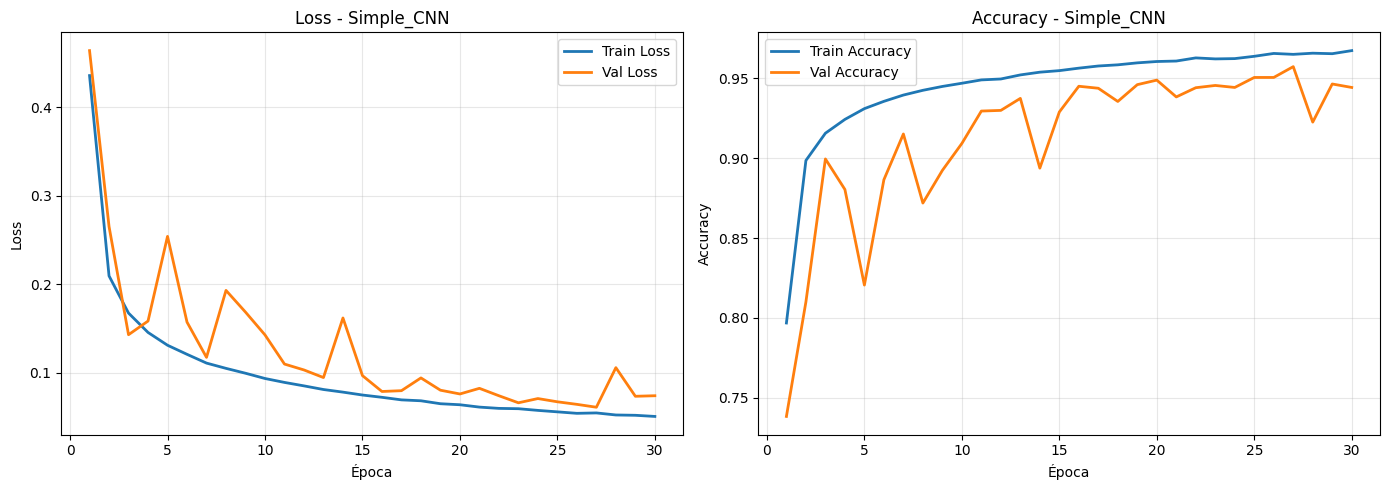


Simple_CNN - EVALUACIÓN EN TRAIN
Accuracy: 0.9700
F1-Macro: 0.9699
F1-Weighted: 0.9699

Classification Report:
              precision    recall  f1-score   support

           F     0.9609    0.9886    0.9745     15903
           N     0.9619    0.9733    0.9676     16000
           Q     0.9911    0.9922    0.9917     15991
           S     0.9560    0.9624    0.9592     15976
           V     0.9808    0.9335    0.9565     15989

    accuracy                         0.9700     79859
   macro avg     0.9702    0.9700    0.9699     79859
weighted avg     0.9702    0.9700    0.9699     79859



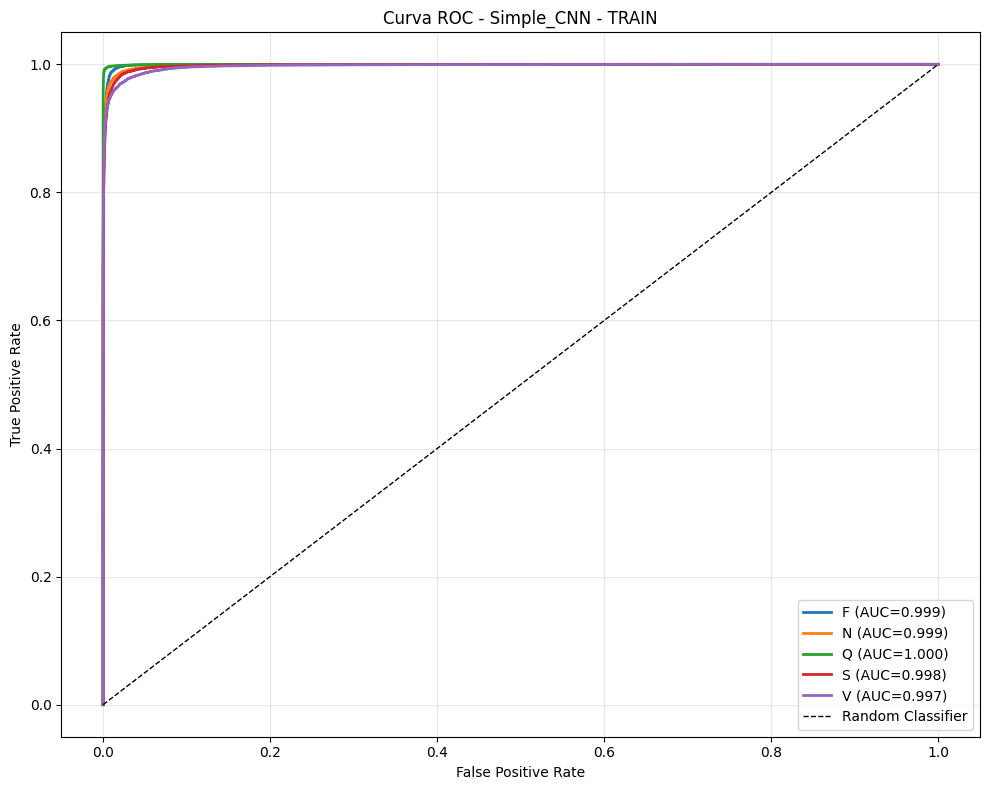

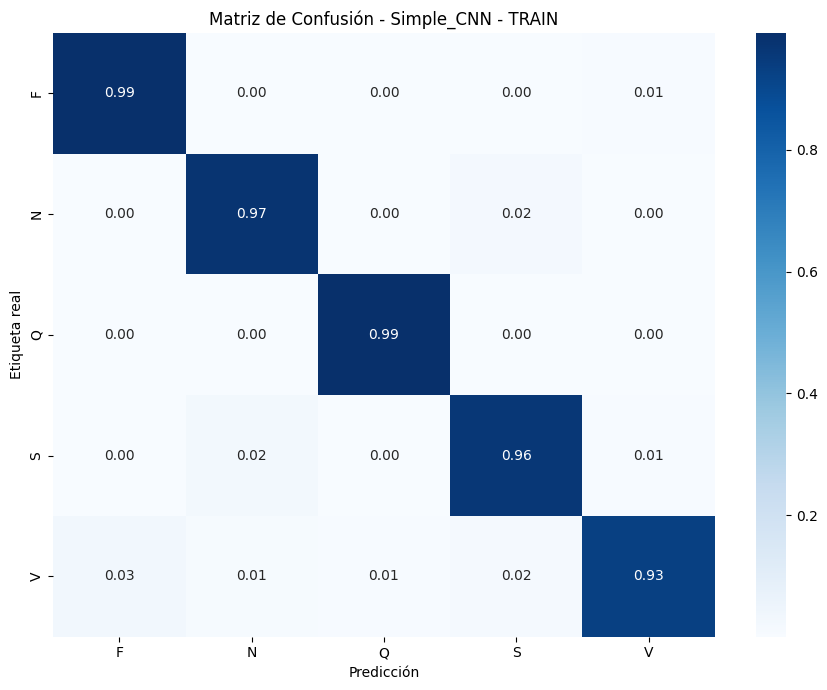


Simple_CNN - EVALUACIÓN EN TEST
Accuracy: 0.9551
F1-Macro: 0.9550
F1-Weighted: 0.9550

Classification Report:
              precision    recall  f1-score   support

           F     0.9500    0.9741    0.9619      3976
           N     0.9421    0.9600    0.9510      4000
           Q     0.9848    0.9885    0.9866      3998
           S     0.9333    0.9429    0.9381      3994
           V     0.9665    0.9102    0.9375      3997

    accuracy                         0.9551     19965
   macro avg     0.9553    0.9551    0.9550     19965
weighted avg     0.9554    0.9551    0.9550     19965



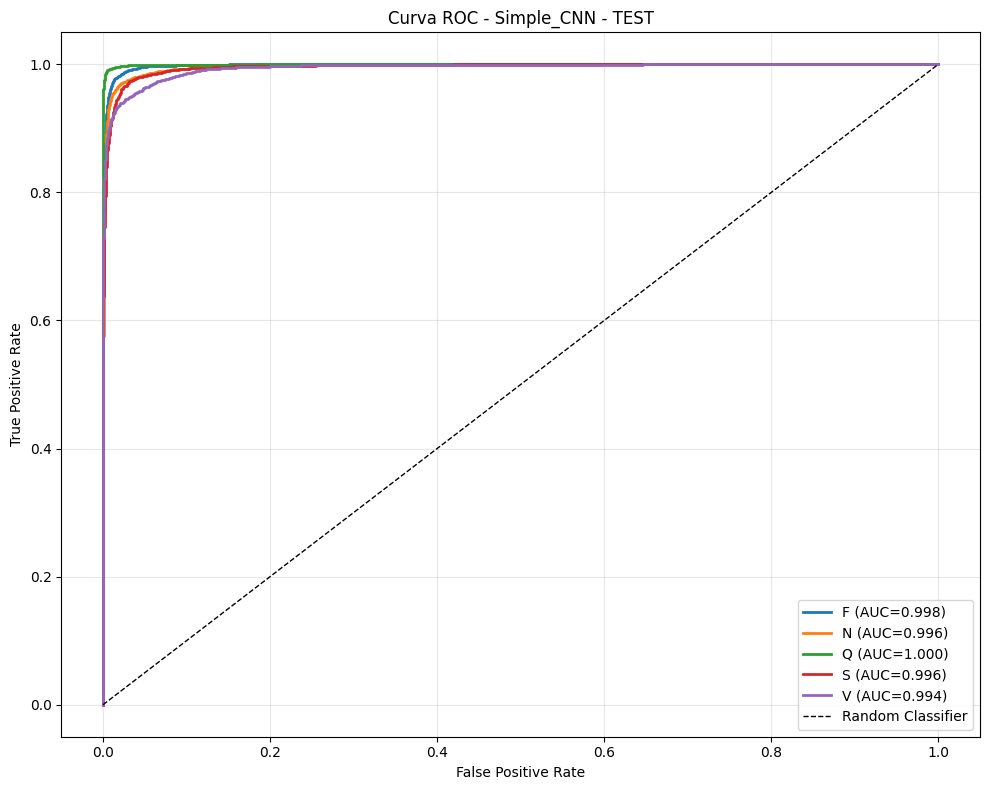

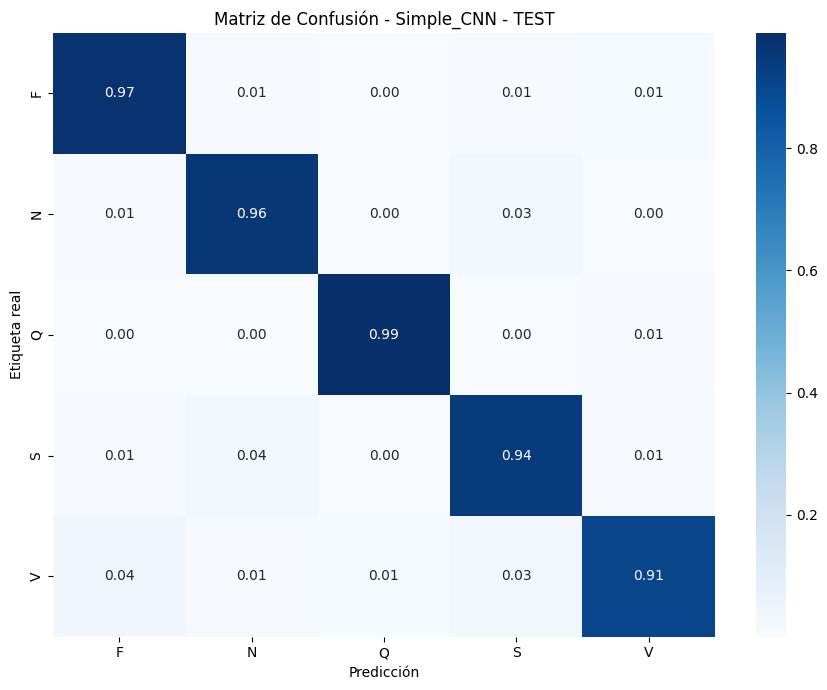

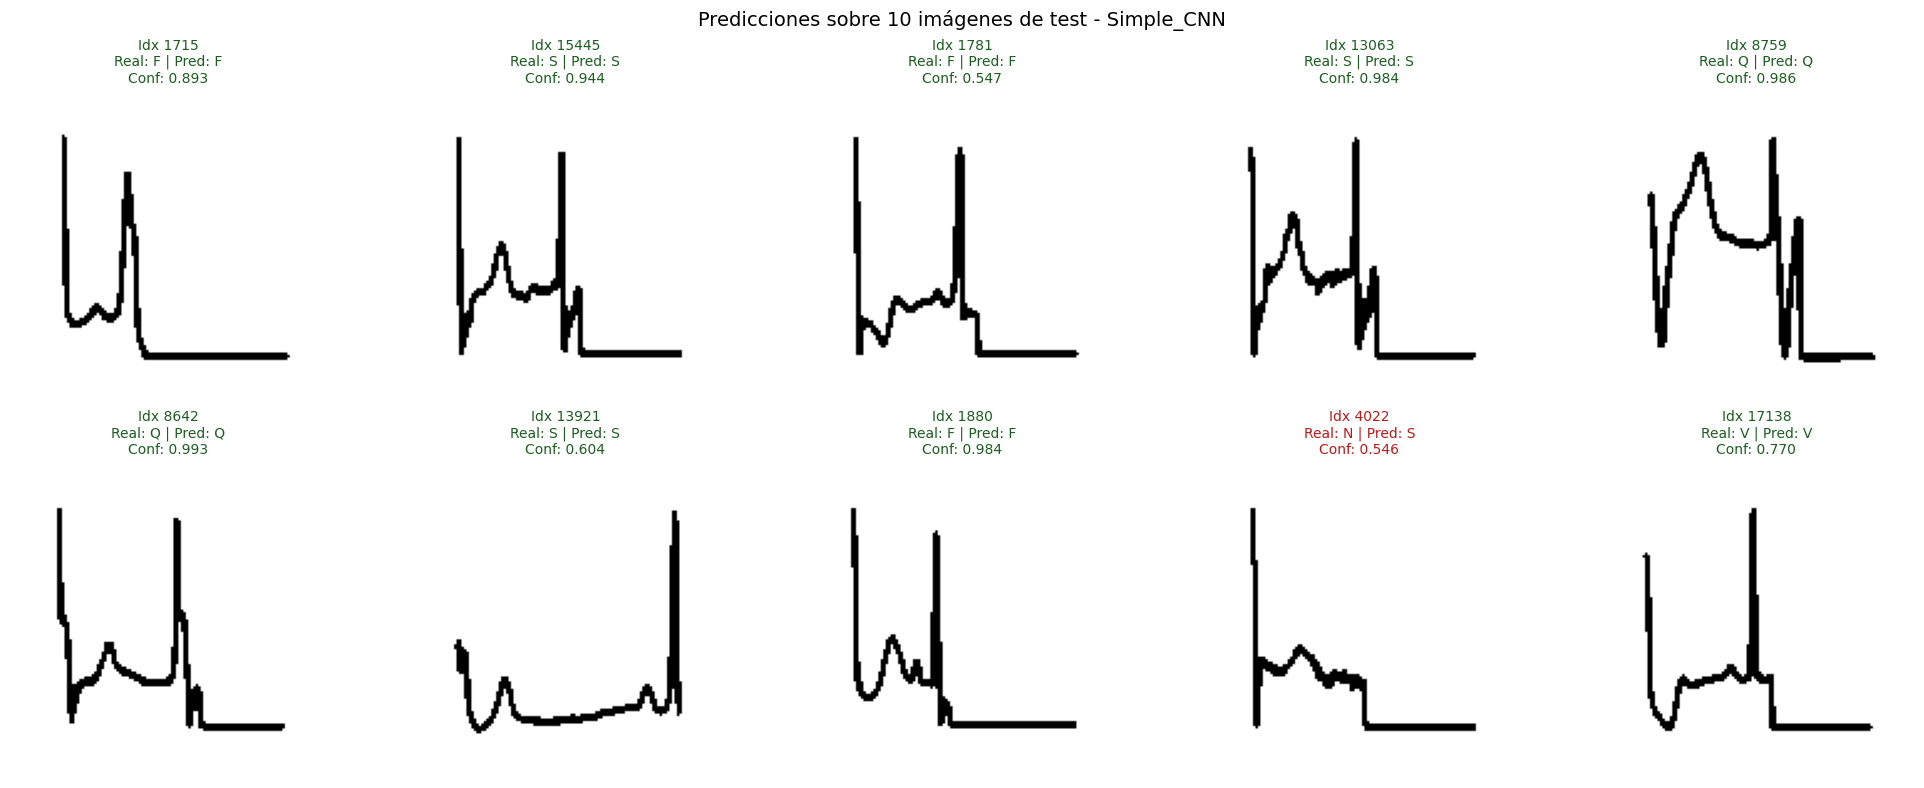

 sample_index real_class predicted_class  confidence  correct
         1715          F               F    0.892904     True
        15445          S               S    0.943664     True
         1781          F               F    0.546628     True
        13063          S               S    0.983510     True
         8759          Q               Q    0.985866     True
         8642          Q               Q    0.992732     True
        13921          S               S    0.603973     True
         1880          F               F    0.983876     True
         4022          N               S    0.546496    False
        17138          V               V    0.770430     True

####################################################################################################
PROCESANDO MODELO: CNN_Mejorada_Usuario
####################################################################################################

[1/3] K-Fold CV para CNN_Mejorada_Usuario

K-FOLD CV: CNN_Mejorada_Usuario

In [ ]:
"""def run_crisp_ml_improved():
   
    Pipeline completo CRISP-ML(Q) Mejorado:
    1. Comprensión de negocio y carga de datos
    2. Preparación de datos
    3. Evaluación con K-Fold para robustez
    4. Entrenamiento final con diagnóstico completo por modelo
    5. Comparación global y selección del mejor modelo
    6. Guardado de los 3 mejores modelos en .h5
    
    
    print("\n" + "=" * 100)
    print("CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)")
    print("=" * 100)
    
    print("\n[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS")
    print("=" * 100)
    loader = BalancedECGDataLoader(DATASET_PATH, img_size=IMG_SIZE, use_percentage=USE_PERCENTAGE)
    
    print("\nCargando TRAIN (20%)...")
    X_train, y_train_labels, class_names, train_dist = loader.load_dataset('train')
    print(f"✓ Train cargado: {X_train.shape}")
    print(f"  Clases: {class_names}")
    
    print("\nCargando TEST (20%)...")
    X_test, y_test_labels, _, test_dist = loader.load_dataset('test')
    print(f"✓ Test cargado: {X_test.shape}")
    
    print("\nDistribución TRAIN:")
    for cls in class_names:
        print(f"  {cls}: {train_dist.get(cls, 0):,d}")
    print("\nDistribución TEST:")
    for cls in class_names:
        print(f"  {cls}: {test_dist.get(cls, 0):,d}")
    
    y_train = to_categorical(y_train_labels, num_classes=len(class_names))
    y_test = to_categorical(y_test_labels, num_classes=len(class_names))
    
    print("\n[FASE 2] MODELADO Y EVALUACIÓN")
    print("=" * 100)
    
    models_to_test = [
        (SimpleECGModel, 'Simple_CNN', 3e-4, {}),
        (ImprovedCNNModel, 'CNN_Mejorada_Usuario', 3e-4, {}),
        (LSTMWithAttentionModel, 'LSTM_Attention', 3e-4, {}),
        (HybridCNNLSTMWithAttentionModel, 'Hybrid_CNN_LSTM_Attention', 3e-4, {}),
        (ResNet50WithSpatialAttention, 'ResNet50_Spatial', 1e-4, {'trainable_from': 140}),
    ]
    
    cv_results = {}
    final_results = {}
    final_models_for_saving = []
    
    for model_class, model_name, learning_rate, model_kwargs in models_to_test:
        print("\n" + "#" * 100)
        print(f"PROCESANDO MODELO: {model_name}")
        print("#" * 100)
        
        batch_size = 16 if 'ResNet50' in model_name else BATCH_SIZE
        
        try:
            print(f"\n[1/3] K-Fold CV para {model_name}")
            fold_results, df_folds, _ = train_and_evaluate_kfold(
                model_class,
                model_name,
                X_train,
                y_train,
                class_names,
                n_splits=N_SPLITS,
                learning_rate=learning_rate,
                epochs=EPOCHS,
                batch_size=batch_size,
                model_kwargs=model_kwargs
            )
            cv_results[model_name] = (fold_results, df_folds)
            
            print(f"\n[2/3] Entrenamiento final y diagnósticos para {model_name}")
            final_result = train_final_model_with_diagnostics(
                model_class,
                model_name,
                X_train,
                y_train,
                X_test,
                y_test,
                class_names,
                learning_rate=learning_rate,
                epochs=EPOCHS,
                batch_size=batch_size,
                model_kwargs=model_kwargs
            )
            final_results[model_name] = final_result
            
            final_models_for_saving.append({
                'model': final_result['model'],
                'model_name': model_name,
                'fold': 'final',
                'split': 'test',
                'f1_macro': final_result['test_metrics']['f1_macro'],
                'accuracy': final_result['test_metrics']['accuracy'],
                'best_epoch': final_result['best_epoch'],
                'best_val_accuracy': final_result['best_val_accuracy'],
                'best_val_loss': final_result['best_val_loss'],
                'best_model_path': final_result['best_model_path']
            })
        except Exception as e:
            print(f"\n❌ Error procesando {model_name}: {e}")
            import traceback
            traceback.print_exc()
    
    print("\n[FASE 3] ANÁLISIS COMPARATIVO GLOBAL")
    print("=" * 100)
    results_df = build_comparison_table(final_results, cv_results)
    plot_comparison_horizontal(results_df)
    print_model_selection_justification(results_df)
    
    print("\n[FASE 4] GUARDADO DEL MEJOR MODELO POR ARQUITECTURA")
    print("=" * 100)
    saved_models = save_top_models(final_models_for_saving, top_n=len(final_models_for_saving))
    
    return {
        'cv_results': cv_results,
        'final_results': final_results,
        'comparison_table': results_df,
        'saved_models': saved_models,
        'class_names': class_names,
        'X_test': X_test,
        'y_test_labels': y_test_labels
    }


print("\n\n⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...")
print("Se evaluarán todos los modelos del notebook original y se generarán gráficos, tablas y justificación final.\n")

try:
    pipeline_outputs = run_crisp_ml_improved()
    print("\n\n✅ PIPELINE COMPLETADO EXITOSAMENTE")
    print(f"Modelos evaluados: {len(pipeline_outputs['final_results'])}")
    print(f"Modelos guardados: {len(pipeline_outputs['saved_models'])}")
except Exception as e:
    print(f"\n\n❌ ERROR EN EL PIPELINE: {e}")
    import traceback
    traceback.print_exc()"""



⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...
Se evaluarán todos los modelos del notebook original y se generarán gráficos, tablas y justificación final.


CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)

[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS

Cargando TRAIN (20%)...
  [train] F: cargadas 15,903 de 79,516 (20.0%)
  [train] N: cargadas 16,000 de 80,000 (20.0%)
  [train] Q: cargadas 15,991 de 79,959 (20.0%)
  [train] S: cargadas 15,976 de 79,884 (20.0%)
  [train] V: cargadas 15,989 de 79,948 (20.0%)
✓ Train cargado: (79859, 128, 128, 1)
  Clases: ['F', 'N', 'Q', 'S', 'V']

Cargando TEST (20%)...
  [test] F: cargadas 3,976 de 19,880 (20.0%)
  [test] N: cargadas 4,000 de 20,000 (20.0%)
  [test] Q: cargadas 3,998 de 19,990 (20.0%)
  [test] S: cargadas 3,994 de 19,971 (20.0%)
  [test] V: cargadas 3,997 de 19,987 (20.0%)
✓ Test cargado: (19965, 128, 128, 1)

Distribución TRAIN:
  F: 15,903
  N: 16,000
  Q: 15,991
  S: 15,976
  V: 15,989

Distribución


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 376s - 127ms/step - accuracy: 0.8669 - f1_score: 0.8550 - loss: 0.2799 - precision: 0.9372 - recall: 0.7860 - val_accuracy: 0.9045 - val_f1_score: 0.9001 - val_loss: 0.1269 - val_precision: 0.9314 - val_recall: 0.8708 - learning_rate: 3.0000e-04
Epoch 2/30

Epoch 2: val_f1_score improved from 0.90008 to 0.94911, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 368s - 124ms/step - accuracy: 0.9492 - f1_score: 0.9471 - loss: 0.0906 - precision: 0.9662 - recall: 0.9289 - val_accuracy: 0.9496 - val_f1_score: 0.9491 - val_loss: 0.0622 - val_precision: 0.9630 - val_recall: 0.9356 - learning_rate: 3.0000e-04
Epoch 3/30

Epoch 3: val_f1_score improved from 0.94911 to 0.95515, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 3: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 345s - 116ms/step - accuracy: 0.9661 - f1_score: 0.9650 - loss: 0.0549 - precision: 0.9747 - recall: 0.9555 - val_accuracy: 0.9563 - val_f1_score: 0.9552 - val_loss: 0.0674 - val_precision: 0.9647 - val_recall: 0.9458 - learning_rate: 3.0000e-04
Epoch 4/30

Epoch 4: val_f1_score improved from 0.95515 to 0.96599, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 4: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 337s - 113ms/step - accuracy: 0.9762 - f1_score: 0.9755 - loss: 0.0362 - precision: 0.9807 - recall: 0.9703 - val_accuracy: 0.9658 - val_f1_score: 0.9660 - val_loss: 0.0542 - val_precision: 0.9706 - val_recall: 0.9614 - learning_rate: 3.0000e-04
Epoch 5/30

Epoch 5: val_f1_score improved from 0.96599 to 0.97464, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5


...


Epoch 13: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 374s - 126ms/step - accuracy: 0.9940 - f1_score: 0.9939 - loss: 0.0083 - precision: 0.9944 - recall: 0.9935 - val_accuracy: 0.9864 - val_f1_score: 0.9867 - val_loss: 0.0190 - val_precision: 0.9879 - val_recall: 0.9856 - learning_rate: 3.0000e-04
Epoch 14/30

Epoch 14: val_f1_score did not improve from 0.98671
2972/2972 - 458s - 154ms/step - accuracy: 0.9949 - f1_score: 0.9948 - loss: 0.0067 - precision: 0.9951 - recall: 0.9945 - val_accuracy: 0.9861 - val_f1_score: 0.9862 - val_loss: 0.0206 - val_precision: 0.9866 - val_recall: 0.9858 - learning_rate: 3.0000e-04
Epoch 15/30

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 15: val_f1_score improved from 0.98671 to 0.98764, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 15: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 493s - 166ms/step - accuracy: 0.9954 - f1_score: 0.9954 - loss: 0.0067 - precision: 0.9957 - recall: 0.9951 - val_accuracy: 0.9876 - val_f1_score: 0.9876 - val_loss: 0.0191 - val_precision: 0.9880 - val_recall: 0.9873 - learning_rate: 3.0000e-04
Epoch 16/30

Epoch 16: val_f1_score improved from 0.98764 to 0.99077, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 16: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 510s - 172ms/step - accuracy: 0.9975 - f1_score: 0.9975 - loss: 0.0032 - precision: 0.9976 - recall: 0.9974 - val_accuracy: 0.9907 - val_f1_score: 0.9908 - val_loss: 0.0168 - val_precision: 0.9909 - val_recall: 0.9907 - learning_rate: 1.5000e-04
Epoch 17/30

Epoch 17: val_f1_score did not improve from 0.99077
2972/2972 - 524s - 176ms/step - accuracy: 0.9981 - f1_score: 0.9981 - loss: 0.0026 - precision: 0.9982 - recall: 0.9980 - val_accuracy: 0.9901 - val_f1_score: 0.9902 - val_loss: 0.0200 - val_precision: 0.9905 - val_recall: 0.9900 - learning_rate: 1.5000e-04
Epoch 18/30

Epoch 18: val_f1_score did not improve from 0.99077
2972/2972 - 534s - 180ms/step - accuracy: 0.9978 - f1_score: 0.9978 - loss: 0.0027 - precision: 0.9978 - recall: 0.9978 - val_accuracy: 0.9902 - val_f1_score: 0.9904 - val_loss: 0.0212 - val_precision: 0.9907 - val_re


Epoch 21: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 486s - 163ms/step - accuracy: 0.9983 - f1_score: 0.9984 - loss: 0.0020 - precision: 0.9984 - recall: 0.9983 - val_accuracy: 0.9910 - val_f1_score: 0.9911 - val_loss: 0.0218 - val_precision: 0.9913 - val_recall: 0.9910 - learning_rate: 1.5000e-04
Epoch 22/30

Epoch 22: val_f1_score improved from 0.99115 to 0.99207, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 22: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
2972/2972 - 360s - 121ms/step - accuracy: 0.9990 - f1_score: 0.9990 - loss: 0.0010 - precision: 0.9990 - recall: 0.9990 - val_accuracy: 0.9920 - val_f1_score: 0.9921 - val_loss: 0.0246 - val_precision: 0.9922 - val_recall: 0.9920 - learning_rate: 7.5000e-05
Epoch 23/30

Epoch 23: val_f1_score did not improve from 0.99207
2972/2972 - 357s - 120ms/step - accuracy: 0.9992 - f1_score: 0.9992 - loss: 8.8252e-04 - precision: 0.9992 - recall: 0.9992 - val_accuracy: 0.9914 - val_f1_score: 0.9913 - val_loss: 0.0231 - val_precision: 0.9915 - val_recall: 0.9912 - learning_rate: 7.5000e-05
Epoch 24/30

Epoch 24: val_f1_score did not improve from 0.99207
2972/2972 - 335s - 113ms/step - accuracy: 0.9993 - f1_score: 0.9993 - loss: 6.7272e-04 - precision: 0.9993 - recall: 0.9993 - val_accuracy: 0.9914 - val_f1_score: 0.9913 - val_loss: 0.0243 - val_precision: 0.9915 

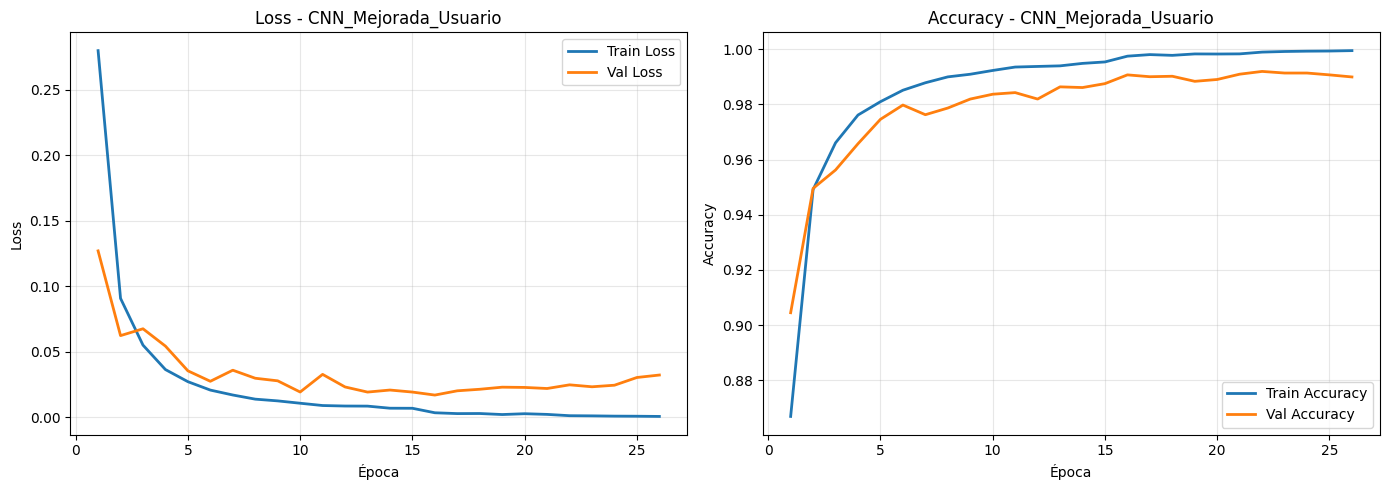


CNN_Mejorada_Usuario - EVALUACIÓN EN TRAIN
Accuracy: 0.9970
F1-Macro: 0.9970
F1-Weighted: 0.9970

Classification Report:
              precision    recall  f1-score   support

           F     0.9930    0.9975    0.9953     15903
           N     0.9959    0.9978    0.9968     16000
           Q     0.9999    0.9996    0.9997     15991
           S     0.9982    0.9984    0.9983     15976
           V     0.9982    0.9919    0.9951     15989

    accuracy                         0.9970     79859
   macro avg     0.9970    0.9970    0.9970     79859
weighted avg     0.9971    0.9970    0.9970     79859



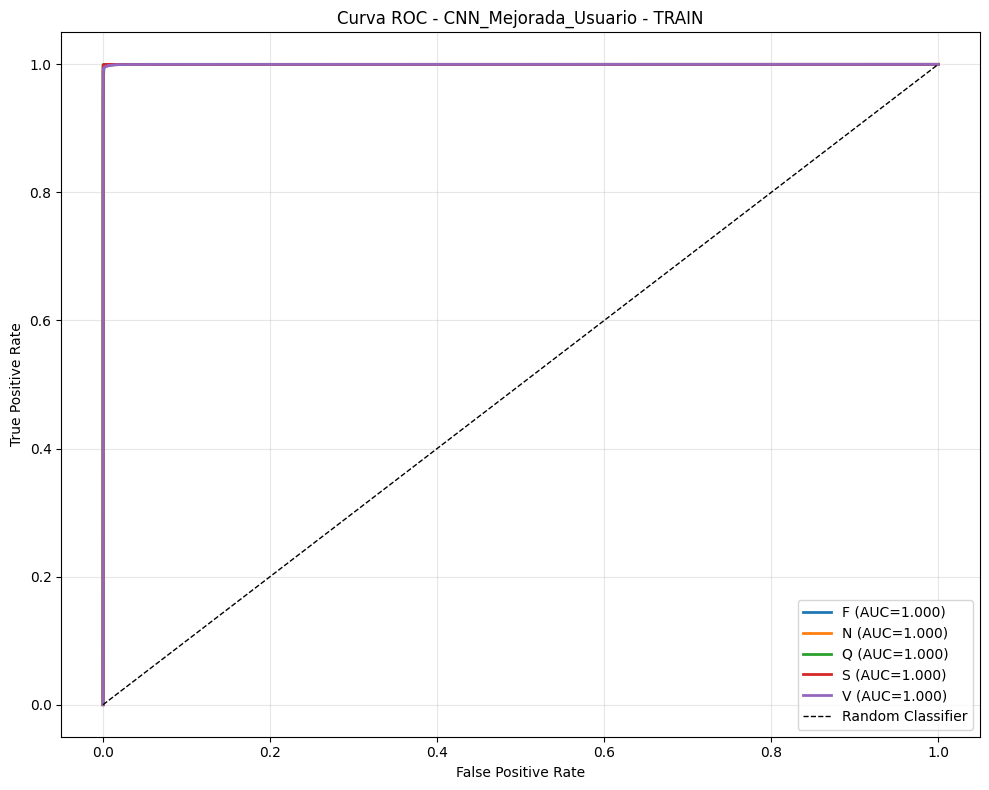

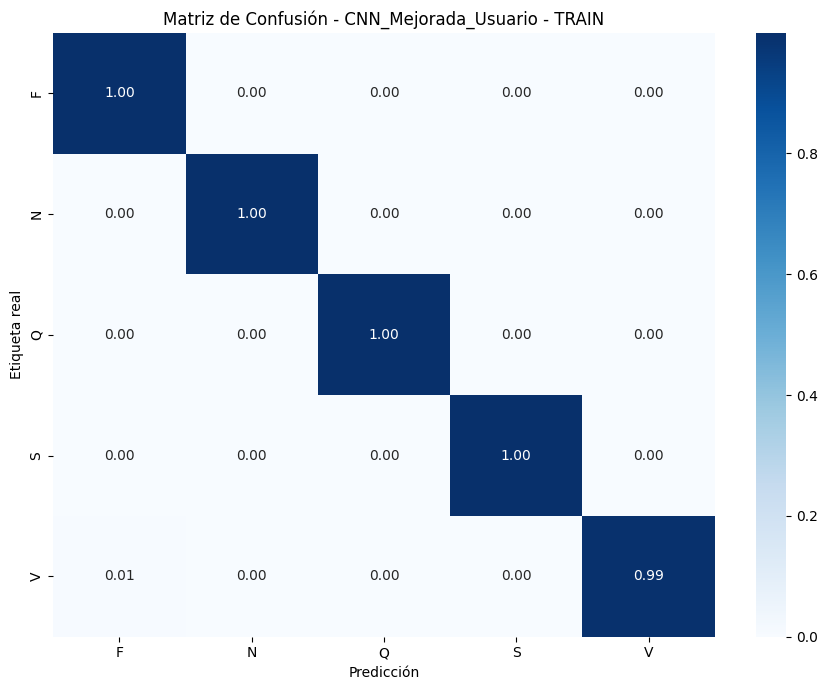


CNN_Mejorada_Usuario - EVALUACIÓN EN TEST
Accuracy: 0.9887
F1-Macro: 0.9887
F1-Weighted: 0.9887

Classification Report:
              precision    recall  f1-score   support

           F     0.9897    0.9914    0.9906      3976
           N     0.9820    0.9838    0.9829      4000
           Q     0.9985    0.9952    0.9969      3998
           S     0.9846    0.9900    0.9873      3994
           V     0.9889    0.9832    0.9861      3997

    accuracy                         0.9887     19965
   macro avg     0.9887    0.9887    0.9887     19965
weighted avg     0.9887    0.9887    0.9887     19965



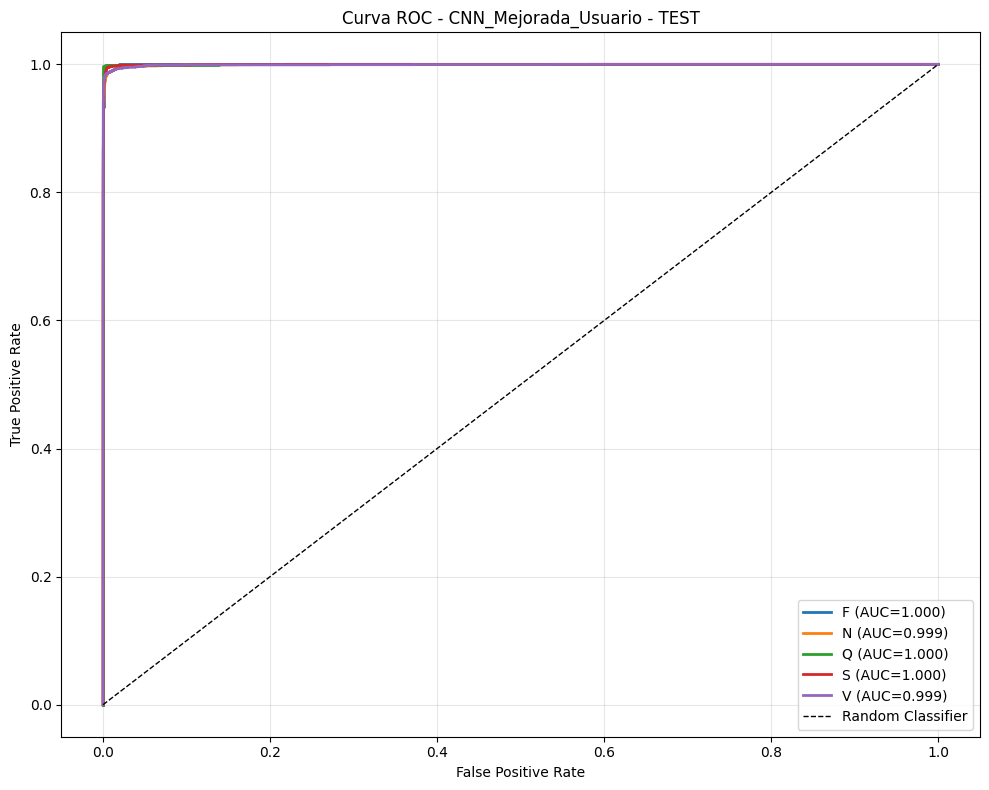

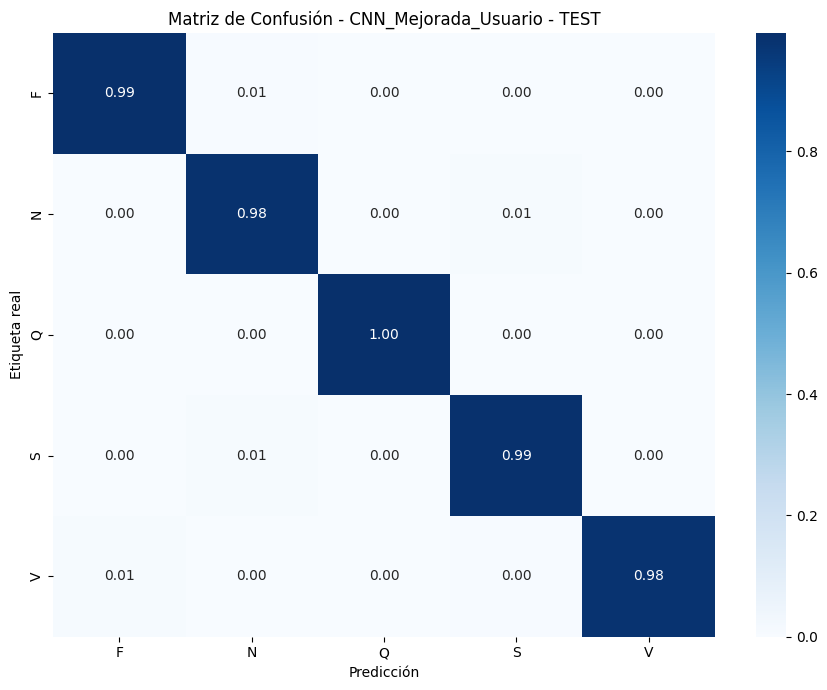

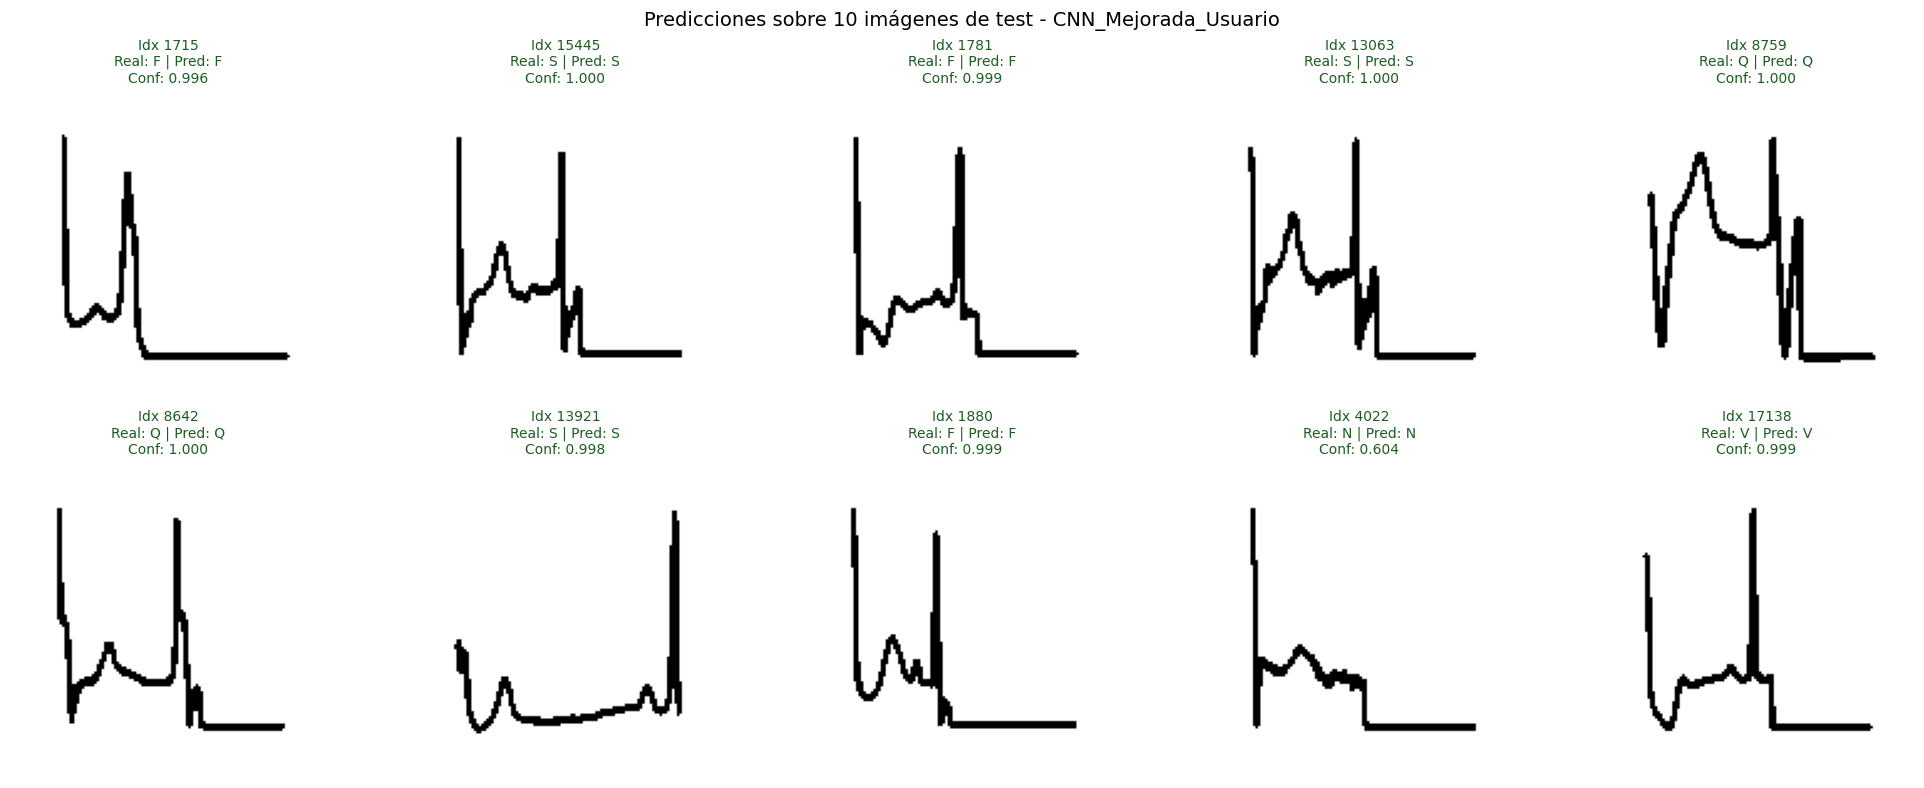

 sample_index real_class predicted_class  confidence  correct
         1715          F               F    0.996416     True
        15445          S               S    0.999971     True
         1781          F               F    0.998995     True
        13063          S               S    1.000000     True
         8759          Q               Q    0.999999     True
         8642          Q               Q    0.999962     True
        13921          S               S    0.998190     True
         1880          F               F    0.998682     True
         4022          N               N    0.604380     True
        17138          V               V    0.999252     True

####################################################################################################
PROCESANDO MODELO: LSTM_Attention
####################################################################################################

[1/3] K-Fold CV para LSTM_Attention

K-FOLD CV: LSTM_Attention (3 folds)

--- FO

KeyboardInterrupt: 

In [ ]:
def run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT):
    """
    Pipeline completo CRISP-ML(Q) Mejorado.

    - run_kfold=True: usa K-Fold para comparación de arquitectura + entrenamiento final 70/30.
    - run_kfold=False: modo rápido, ejecuta solo el bloque final 70/30.
    """

    print("\n" + "=" * 100)
    print("CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)")
    print(f"Modo K-Fold: {'ACTIVADO' if run_kfold else 'DESACTIVADO (rápido 70/30)'}")
    print("=" * 100)

    print("\n[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS")
    print("=" * 100)
    loader = BalancedECGDataLoader(DATASET_PATH, img_size=IMG_SIZE, use_percentage=USE_PERCENTAGE)

    print(f"\nCargando TRAIN ({USE_PERCENTAGE*100:.0f}%)...")
    X_train, y_train_labels, class_names, train_dist = loader.load_dataset('train')
    print(f"✓ Train cargado: {X_train.shape}")
    print(f"  Clases: {class_names}")

    print(f"\nCargando TEST ({USE_PERCENTAGE*100:.0f}%)...")
    X_test, y_test_labels, _, test_dist = loader.load_dataset('test')
    print(f"✓ Test cargado: {X_test.shape}")

    print("\nDistribución TRAIN:")
    for cls in class_names:
        print(f"  {cls}: {train_dist.get(cls, 0):,d}")
    print("\nDistribución TEST:")
    for cls in class_names:
        print(f"  {cls}: {test_dist.get(cls, 0):,d}")

    y_train = to_categorical(y_train_labels, num_classes=len(class_names))
    y_test = to_categorical(y_test_labels, num_classes=len(class_names))

    print("\n[FASE 2] MODELADO Y EVALUACIÓN")
    print("=" * 100)

    models_to_test = [
        (ImprovedCNNModel, 'CNN_Mejorada_Usuario', 3e-4, {}),
        (LSTMWithAttentionModel, 'LSTM_Attention', 3e-4, {}),
        (HybridCNNLSTMWithAttentionModel, 'Hybrid_CNN_LSTM_Attention', 3e-4, {}),
    ]

    cv_results = {}
    final_results = {}
    final_models_for_saving = []

    for model_class, model_name, learning_rate, model_kwargs in models_to_test:
        print("\n" + "#" * 100)
        print(f"PROCESANDO MODELO: {model_name}")
        print("#" * 100)

        batch_size = 16 if 'ResNet50' in model_name else BATCH_SIZE

        try:
            if run_kfold:
                print(f"\n[1/3] K-Fold CV para {model_name}")
                fold_results, df_folds, _ = train_and_evaluate_kfold(
                    model_class,
                    model_name,
                    X_train,
                    y_train,
                    class_names,
                    n_splits=N_SPLITS,
                    learning_rate=learning_rate,
                    epochs=EPOCHS,
                    batch_size=batch_size,
                    model_kwargs=model_kwargs
                )
                cv_results[model_name] = (fold_results, df_folds)
            else:
                print("\n[1/3] K-Fold CV omitido (modo rápido 70/30).")

            print(f"\n[2/3] Entrenamiento final y diagnósticos para {model_name}")
            final_result = train_final_model_with_diagnostics(
                model_class,
                model_name,
                X_train,
                y_train,
                X_test,
                y_test,
                class_names,
                learning_rate=learning_rate,
                epochs=EPOCHS,
                batch_size=batch_size,
                model_kwargs=model_kwargs
            )
            final_results[model_name] = final_result

            final_models_for_saving.append({
                'model': final_result['model'],
                'model_name': model_name,
                'fold': 'final',
                'split': 'test',
                'f1_macro': final_result['test_metrics']['f1_macro'],
                'accuracy': final_result['test_metrics']['accuracy'],
                'best_epoch': final_result['best_epoch'],
                'best_val_accuracy': final_result['best_val_accuracy'],
                'best_val_loss': final_result['best_val_loss'],
                'best_model_path': final_result['best_model_path']
            })
        except Exception as e:
            print(f"\n❌ Error procesando {model_name}: {e}")
            import traceback
            traceback.print_exc()

    print("\n[FASE 3] ANÁLISIS COMPARATIVO GLOBAL")
    print("=" * 100)
    if not run_kfold:
        print("[INFO] Métricas CV se muestran como NaN porque K-Fold fue omitido intencionalmente.")

    results_df = build_comparison_table(final_results, cv_results)
    plot_comparison_horizontal(results_df)
    print_model_selection_justification(results_df)

    print("\n[FASE 4] GUARDADO DEL MEJOR MODELO POR ARQUITECTURA")
    print("=" * 100)
    saved_models = save_top_models(final_models_for_saving, top_n=len(final_models_for_saving))

    return {
        'cv_results': cv_results,
        'final_results': final_results,
        'comparison_table': results_df,
        'saved_models': saved_models,
        'class_names': class_names,
        'X_test': X_test,
        'y_test_labels': y_test_labels
    }


print("\n\n⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...")
print("Se evaluarán modelos y se generarán gráficos, tablas y justificación final.\n")

try:
    pipeline_outputs = run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT)
    print("\n\n✅ PIPELINE COMPLETADO EXITOSAMENTE")
    print(f"Modelos evaluados: {len(pipeline_outputs['final_results'])}")
    print(f"Modelos guardados: {len(pipeline_outputs['saved_models'])}")
except Exception as e:
    print(f"\n\n❌ ERROR EN EL PIPELINE: {e}")
    import traceback
    traceback.print_exc()



⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...
Se evaluarán modelos y se generarán gráficos, tablas y justificación final.


CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)
Modo K-Fold: DESACTIVADO (rápido 70/30)

[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS

Cargando TRAIN (10%)...
  [train] F: cargadas 7,951 de 79,516 (10.0%)
  [train] N: cargadas 8,000 de 80,000 (10.0%)
  [train] Q: cargadas 7,995 de 79,959 (10.0%)
  [train] S: cargadas 7,988 de 79,884 (10.0%)
  [train] V: cargadas 7,994 de 79,948 (10.0%)
✓ Train cargado: (39928, 128, 128, 1)
  Clases: ['F', 'N', 'Q', 'S', 'V']

Cargando TEST (10%)...
  [test] F: cargadas 1,988 de 19,880 (10.0%)
  [test] N: cargadas 2,000 de 20,000 (10.0%)
  [test] Q: cargadas 1,999 de 19,990 (10.0%)
  [test] S: cargadas 1,997 de 19,971 (10.0%)
  [test] V: cargadas 1,998 de 19,987 (10.0%)
✓ Test cargado: (9982, 128, 128, 1)

Distribución TRAIN:
  F: 7,951
  N: 8,000
  Q: 7,995
  S: 7,988
  V: 7,994

Distribución TE


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 315s - 258ms/step - accuracy: 0.6932 - f1_score: 0.5711 - loss: 0.8907 - precision: 0.9319 - recall: 0.4117 - val_accuracy: 0.3469 - val_f1_score: 0.3038 - val_loss: 1.5306 - val_precision: 0.4119 - val_recall: 0.2407 - learning_rate: 3.0000e-04
Epoch 2/50

Epoch 2: val_f1_score improved from 0.30381 to 0.35500, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 353s - 288ms/step - accuracy: 0.8418 - f1_score: 0.7909 - loss: 0.5359 - precision: 0.9319 - recall: 0.6870 - val_accuracy: 0.3444 - val_f1_score: 0.3550 - val_loss: 3.1210 - val_precision: 0.3760 - val_recall: 0.3363 - learning_rate: 3.0000e-04
Epoch 3/50

Epoch 3: val_f1_score did not improve from 0.35500
1224/1224 - 374s - 306ms/step - accuracy: 0.8714 - f1_score: 0.8421 - loss: 0.4487 - precision: 0.9400 - recall: 0.7627 - val_accuracy: 0.3485 - val_f1_score: 0.3166 - val_loss: 3.0721 - val_precision: 0.3352 - val_recall: 0.2999 - learning_rate: 3.0000e-04
Epoch 4/50

Epoch 4: val_f1_score improved from 0.35500 to 0.38297, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 4: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 365s - 298ms/step - accuracy: 0.8858 - f1_score: 0.8653 - loss: 0.3968 - precision: 0.9429 - recall: 0.7995 - val_accuracy: 0.3800 - val_f1_score: 0.3830 - val_loss: 3.1672 - val_precision: 0.3881 - val_recall: 0.3780 - learning_rate: 3.0000e-04
Epoch 5/50

Epoch 5: val_f1_score improved from 0.38297 to 0.54508, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 5: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 367s - 300ms/step - accuracy: 0.8961 - f1_score: 0.8810 - loss: 0.3600 - precision: 0.9464 - recall: 0.8241 - val_accuracy: 0.5713 - val_f1_score: 0.5451 - val_loss: 0.9235 - val_precision: 0.6299 - val_recall: 0.4804 - learning_rate: 3.0000e-04
Epoch 6/50

Epoch 6: val_f1_score did not improve from 0.54508
1224/1224 - 370s - 302ms/step - accuracy: 0.9033 - f1_score: 0.8891 - loss: 0.3351 - precision: 0.9487 - recall: 0.8366 - val_accuracy: 0.3220 - val_f1_score: 0.3134 - val_loss: 2.4952 - val_precision: 0.3188 - val_recall: 0.3082 - learning_rate: 3.0000e-04
Epoch 7/50

Epoch 7: val_f1_score did not improve from 0.54508
1224/1224 - 371s - 303ms/step - accuracy: 0.9089 - f1_score: 0.8983 - loss: 0.3123 - precision: 0.9518 - recall: 0.8505 - val_accuracy: 0.5075 - val_f1_score: 0.5171 - val_loss: 0.9662 - val_precision: 0.6064 - val_recall:


Epoch 9: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 375s - 306ms/step - accuracy: 0.9179 - f1_score: 0.9067 - loss: 0.2852 - precision: 0.9554 - recall: 0.8627 - val_accuracy: 0.5731 - val_f1_score: 0.6224 - val_loss: 1.5947 - val_precision: 0.7009 - val_recall: 0.5597 - learning_rate: 3.0000e-04
Epoch 10/50

Epoch 10: val_f1_score improved from 0.62242 to 0.75345, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 10: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 380s - 311ms/step - accuracy: 0.9234 - f1_score: 0.9129 - loss: 0.2688 - precision: 0.9565 - recall: 0.8731 - val_accuracy: 0.7345 - val_f1_score: 0.7535 - val_loss: 0.6621 - val_precision: 0.8435 - val_recall: 0.6808 - learning_rate: 3.0000e-04
Epoch 11/50

Epoch 11: val_f1_score did not improve from 0.75345
1224/1224 - 376s - 307ms/step - accuracy: 0.9261 - f1_score: 0.9161 - loss: 0.2584 - precision: 0.9570 - recall: 0.8785 - val_accuracy: 0.3830 - val_f1_score: 0.3843 - val_loss: 2.2348 - val_precision: 0.4123 - val_recall: 0.3599 - learning_rate: 3.0000e-04
Epoch 12/50

Epoch 12: val_f1_score did not improve from 0.75345
1224/1224 - 381s - 311ms/step - accuracy: 0.9275 - f1_score: 0.9197 - loss: 0.2501 - precision: 0.9584 - recall: 0.8839 - val_accuracy: 0.6748 - val_f1_score: 0.6365 - val_loss: 0.6643 - val_precision: 0.7752 - val_re

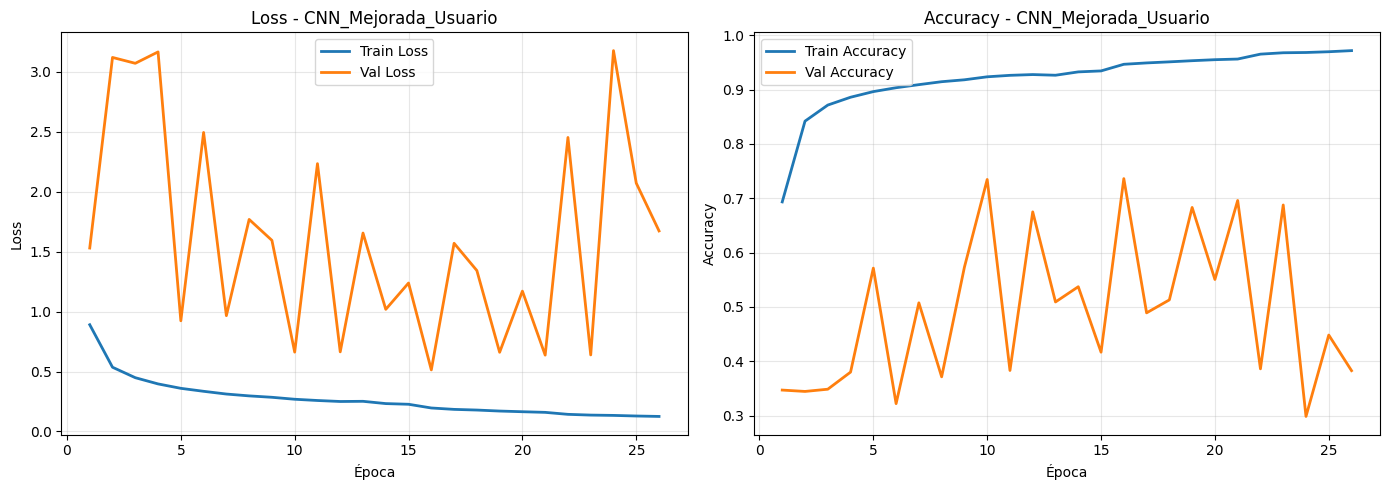


CNN_Mejorada_Usuario - EVALUACIÓN EN TRAIN
Accuracy: 0.7439
F1-Macro: 0.7561
F1-Weighted: 0.7561

Classification Report:
              precision    recall  f1-score   support

           F     0.9463    0.6988    0.8039      7951
           N     0.9719    0.7054    0.8175      8000
           Q     0.9862    0.8877    0.9344      7995
           S     0.4521    0.9942    0.6216      7988
           V     0.9923    0.4332    0.6031      7994

    accuracy                         0.7439     39928
   macro avg     0.8698    0.7439    0.7561     39928
weighted avg     0.8698    0.7439    0.7561     39928



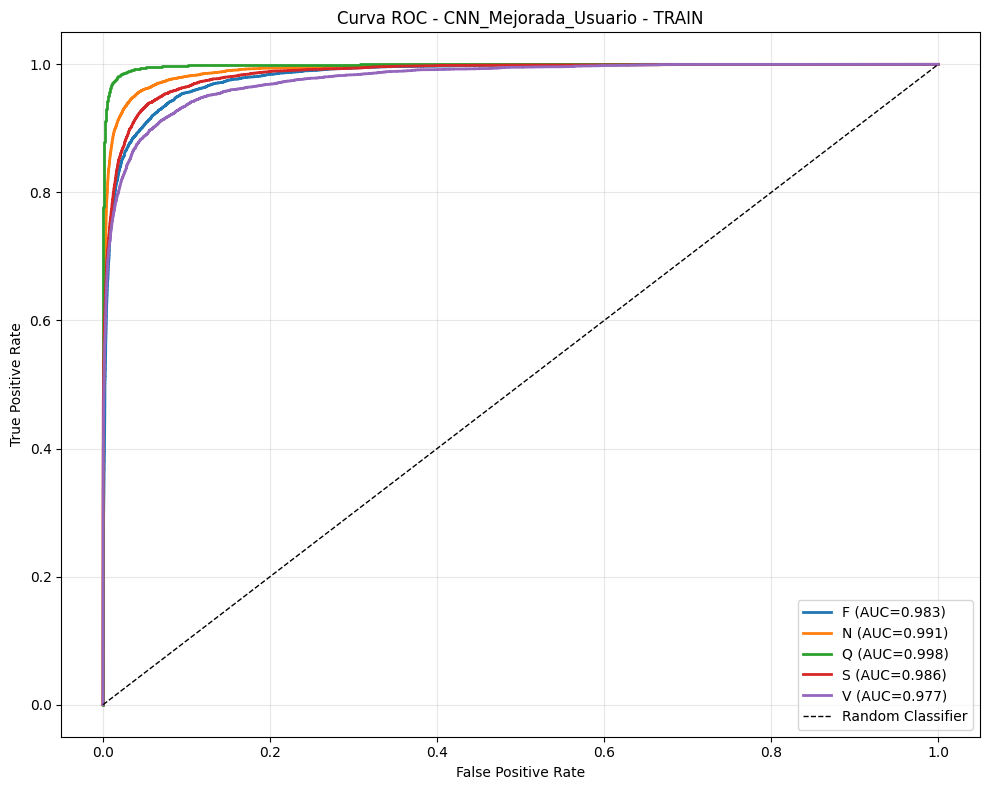

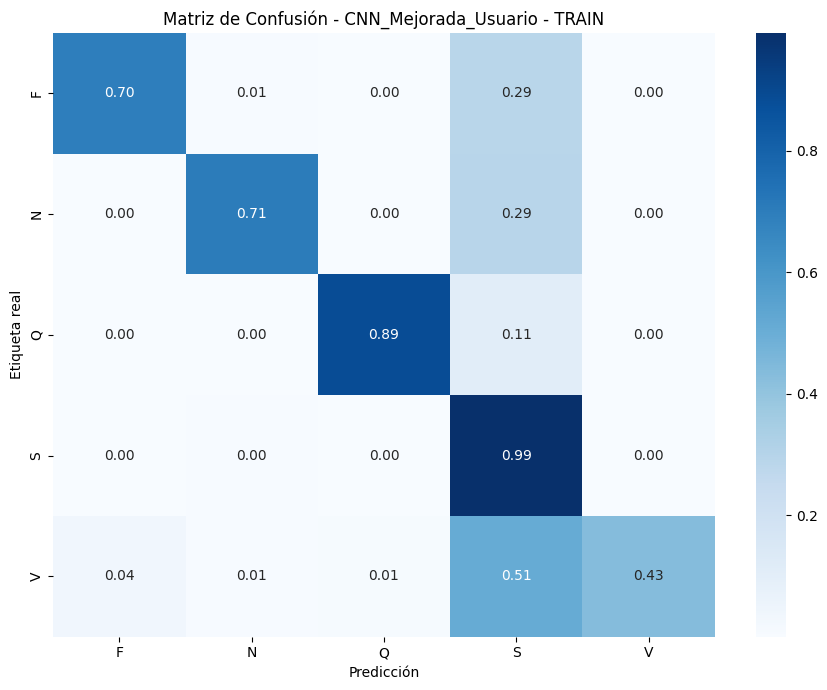


CNN_Mejorada_Usuario - EVALUACIÓN EN TEST
Accuracy: 0.7404
F1-Macro: 0.7516
F1-Weighted: 0.7516

Classification Report:
              precision    recall  f1-score   support

           F     0.9331    0.7017    0.8010      1988
           N     0.9724    0.7050    0.8174      2000
           Q     0.9811    0.8824    0.9292      1999
           S     0.4515    0.9935    0.6209      1997
           V     0.9917    0.4194    0.5895      1998

    accuracy                         0.7404      9982
   macro avg     0.8660    0.7404    0.7516      9982
weighted avg     0.8660    0.7404    0.7516      9982



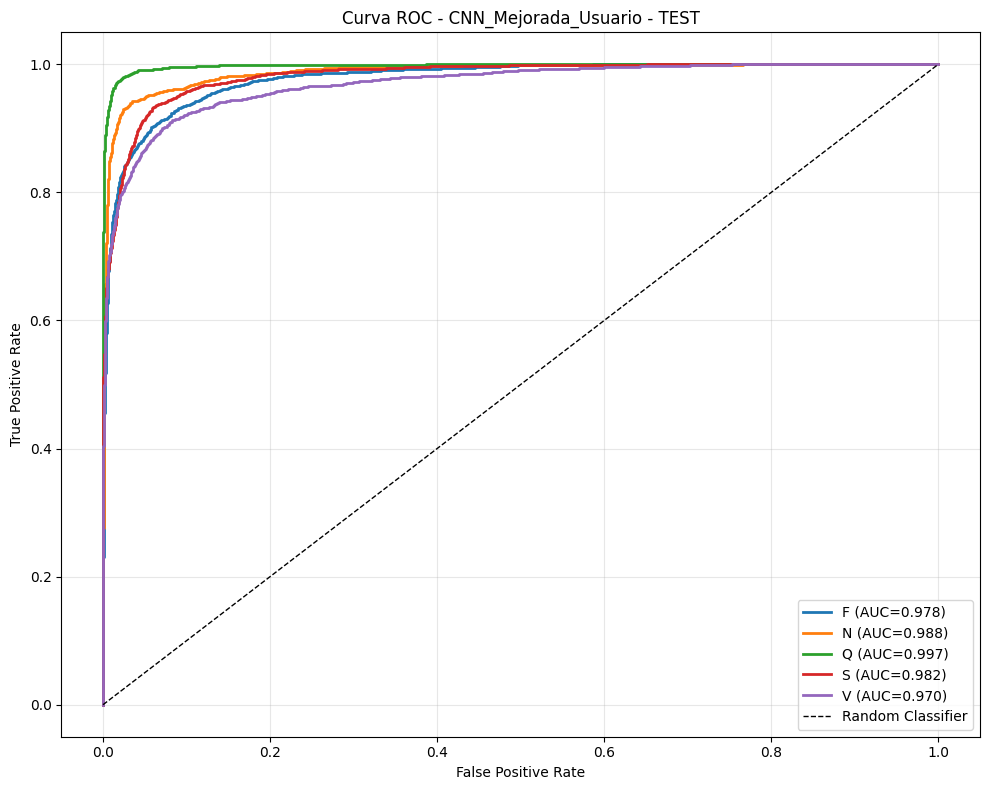

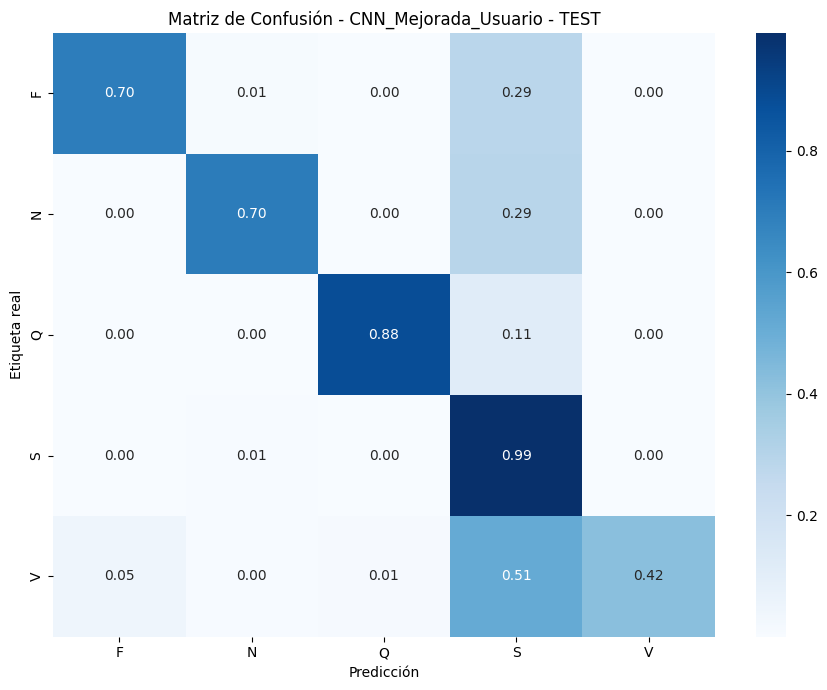

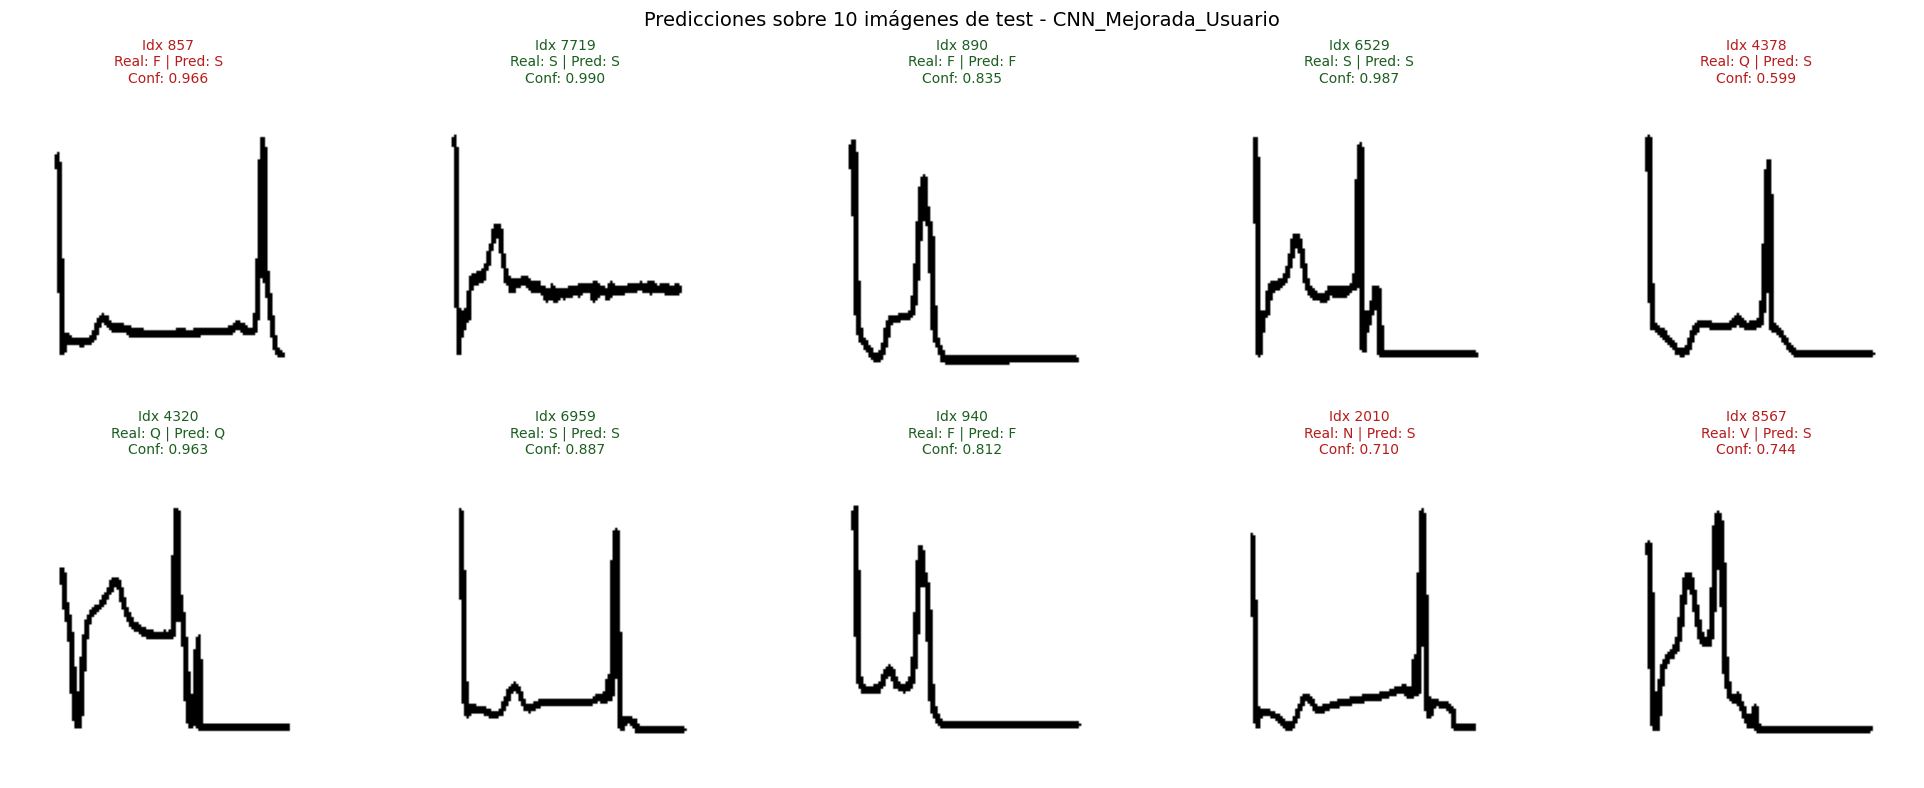

 sample_index real_class predicted_class  confidence  correct
          857          F               S    0.965937    False
         7719          S               S    0.989638     True
          890          F               F    0.835401     True
         6529          S               S    0.987320     True
         4378          Q               S    0.598798    False
         4320          Q               Q    0.962750     True
         6959          S               S    0.887007     True
          940          F               F    0.811849     True
         2010          N               S    0.710320    False
         8567          V               S    0.744189    False

####################################################################################################
PROCESANDO MODELO: LSTM_Attention
####################################################################################################

[1/3] K-Fold CV omitido (modo rápido 70/30).

[2/3] Entrenamiento final y diagnó


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 221s - 181ms/step - accuracy: 0.4986 - f1_score: 0.3445 - loss: 1.0912 - precision: 0.8884 - recall: 0.2137 - val_accuracy: 0.4951 - val_f1_score: 0.3603 - val_loss: 0.7035 - val_precision: 0.7146 - val_recall: 0.2408 - learning_rate: 3.0000e-04
Epoch 2/50

Epoch 2: val_f1_score improved from 0.36026 to 0.49347, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 214s - 175ms/step - accuracy: 0.6507 - f1_score: 0.5506 - loss: 0.6923 - precision: 0.8577 - recall: 0.4055 - val_accuracy: 0.5784 - val_f1_score: 0.4935 - val_loss: 0.5460 - val_precision: 0.7447 - val_recall: 0.3690 - learning_rate: 3.0000e-04
Epoch 3/50

Epoch 3: val_f1_score did not improve from 0.49347
1224/1224 - 213s - 174ms/step - accuracy: 0.6862 - f1_score: 0.6024 - loss: 0.5908 - precision: 0.8532 - recall: 0.4656 - val_accuracy: 0.6148 - val_f1_score: 0.4934 - val_loss: 0.5057 - val_precision: 0.7216 - val_recall: 0.3748 - learning_rate: 3.0000e-04
Epoch 4/50

Epoch 4: val_f1_score improved from 0.49347 to 0.61302, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 4: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 216s - 176ms/step - accuracy: 0.7075 - f1_score: 0.6358 - loss: 0.5390 - precision: 0.8505 - recall: 0.5076 - val_accuracy: 0.6766 - val_f1_score: 0.6130 - val_loss: 0.4359 - val_precision: 0.8040 - val_recall: 0.4954 - learning_rate: 3.0000e-04
Epoch 5/50

Epoch 5: val_f1_score improved from 0.61302 to 0.66424, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 5: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 219s - 179ms/step - accuracy: 0.7288 - f1_score: 0.6756 - loss: 0.4985 - precision: 0.8548 - recall: 0.5585 - val_accuracy: 0.7033 - val_f1_score: 0.6642 - val_loss: 0.4160 - val_precision: 0.8223 - val_recall: 0.5571 - learning_rate: 3.0000e-04
Epoch 6/50

Epoch 6: val_f1_score improved from 0.66424 to 0.72148, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5


...


Epoch 39: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 219s - 179ms/step - accuracy: 0.9183 - f1_score: 0.9139 - loss: 0.1504 - precision: 0.9457 - recall: 0.8841 - val_accuracy: 0.9115 - val_f1_score: 0.9097 - val_loss: 0.1299 - val_precision: 0.9332 - val_recall: 0.8873 - learning_rate: 3.0000e-04
Epoch 40/50

Epoch 40: val_f1_score did not improve from 0.90967
1224/1224 - 217s - 178ms/step - accuracy: 0.9214 - f1_score: 0.9176 - loss: 0.1461 - precision: 0.9485 - recall: 0.8887 - val_accuracy: 0.9072 - val_f1_score: 0.9074 - val_loss: 0.1285 - val_precision: 0.9309 - val_recall: 0.8850 - learning_rate: 3.0000e-04
Epoch 41/50

Epoch 41: val_f1_score improved from 0.90967 to 0.91313, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 41: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 218s - 178ms/step - accuracy: 0.9195 - f1_score: 0.9162 - loss: 0.1406 - precision: 0.9461 - recall: 0.8881 - val_accuracy: 0.9149 - val_f1_score: 0.9131 - val_loss: 0.1200 - val_precision: 0.9417 - val_recall: 0.8862 - learning_rate: 3.0000e-04
Epoch 42/50

Epoch 42: val_f1_score improved from 0.91313 to 0.91534, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 42: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 217s - 177ms/step - accuracy: 0.9217 - f1_score: 0.9178 - loss: 0.1416 - precision: 0.9475 - recall: 0.8899 - val_accuracy: 0.9175 - val_f1_score: 0.9153 - val_loss: 0.1193 - val_precision: 0.9398 - val_recall: 0.8921 - learning_rate: 3.0000e-04
Epoch 43/50

Epoch 43: val_f1_score did not improve from 0.91534
1224/1224 - 217s - 178ms/step - accuracy: 0.9226 - f1_score: 0.9198 - loss: 0.1404 - precision: 0.9489 - recall: 0.8925 - val_accuracy: 0.9167 - val_f1_score: 0.9142 - val_loss: 0.1149 - val_precision: 0.9392 - val_recall: 0.8905 - learning_rate: 3.0000e-04
Epoch 44/50

Epoch 44: val_f1_score improved from 0.91534 to 0.91777, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 44: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 217s - 177ms/step - accuracy: 0.9233 - f1_score: 0.9196 - loss: 0.1388 - precision: 0.9489 - recall: 0.8920 - val_accuracy: 0.9177 - val_f1_score: 0.9178 - val_loss: 0.1124 - val_precision: 0.9372 - val_recall: 0.8992 - learning_rate: 3.0000e-04
Epoch 45/50

Epoch 45: val_f1_score improved from 0.91777 to 0.91881, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5



Epoch 45: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5
1224/1224 - 218s - 178ms/step - accuracy: 0.9251 - f1_score: 0.9212 - loss: 0.1385 - precision: 0.9494 - recall: 0.8946 - val_accuracy: 0.9189 - val_f1_score: 0.9188 - val_loss: 0.1191 - val_precision: 0.9427 - val_recall: 0.8961 - learning_rate: 3.0000e-04
Epoch 46/50

Epoch 46: val_f1_score did not improve from 0.91881
1224/1224 - 217s - 178ms/step - accuracy: 0.9243 - f1_score: 0.9219 - loss: 0.1322 - precision: 0.9488 - recall: 0.8964 - val_accuracy: 0.9181 - val_f1_score: 0.9171 - val_loss: 0.1187 - val_precision: 0.9376 - val_recall: 0.8975 - learning_rate: 3.0000e-04
Epoch 47/50

Epoch 47: val_f1_score did not improve from 0.91881
1224/1224 - 219s - 179ms/step - accuracy: 0.9253 - f1_score: 0.9217 - loss: 0.1339 - precision: 0.9496 - recall: 0.8954 - val_accuracy: 0.9184 - val_f1_score: 0.9166 - val_loss: 0.1171 - val_precision: 0.9398 - val_recall: 

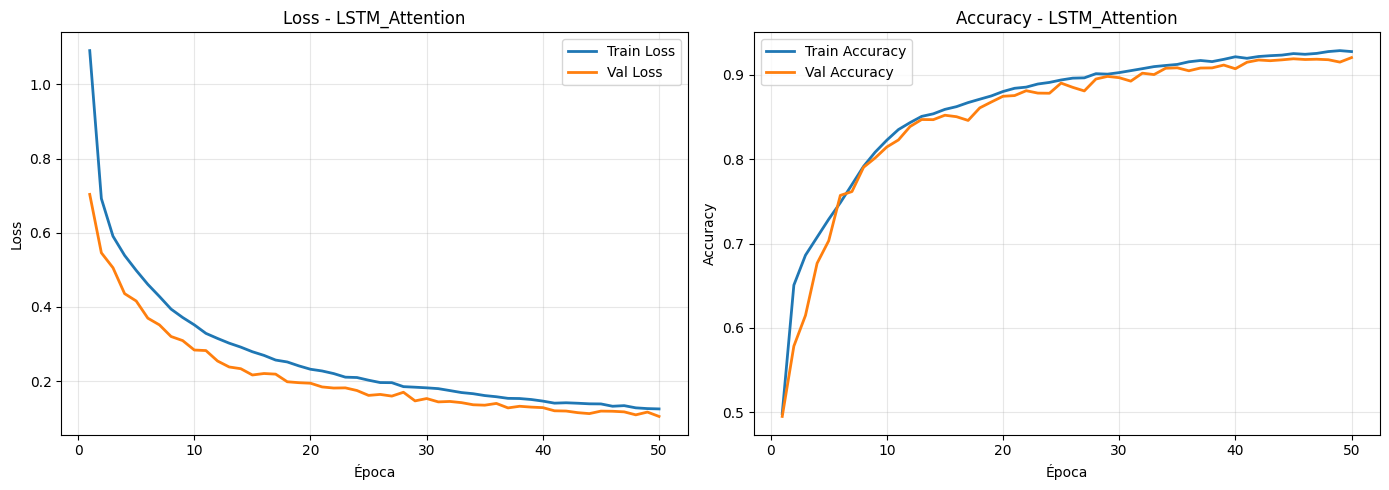


LSTM_Attention - EVALUACIÓN EN TRAIN
Accuracy: 0.9278
F1-Macro: 0.9276
F1-Weighted: 0.9276

Classification Report:
              precision    recall  f1-score   support

           F     0.9470    0.9312    0.9391      7951
           N     0.8839    0.9514    0.9164      8000
           Q     0.9604    0.9847    0.9724      7995
           S     0.9240    0.8769    0.8999      7988
           V     0.9263    0.8945    0.9101      7994

    accuracy                         0.9278     39928
   macro avg     0.9283    0.9278    0.9276     39928
weighted avg     0.9283    0.9278    0.9276     39928



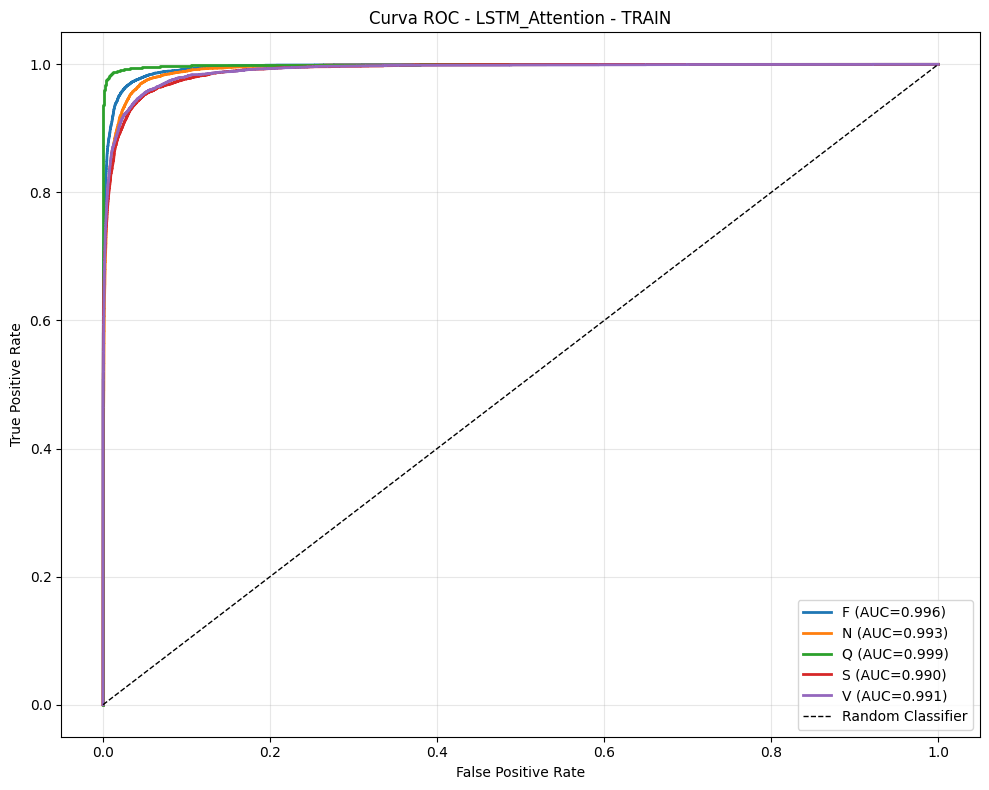

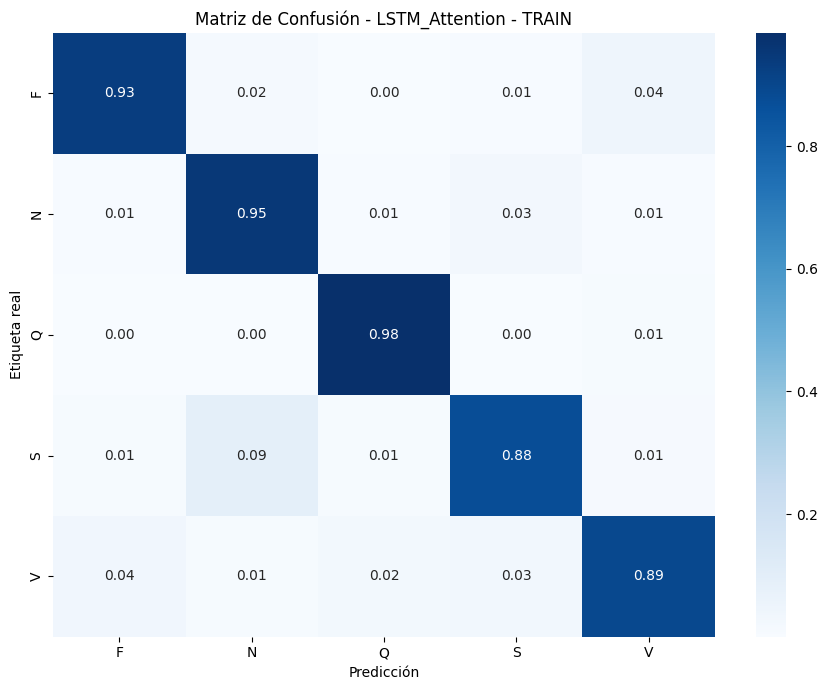


LSTM_Attention - EVALUACIÓN EN TEST
Accuracy: 0.9218
F1-Macro: 0.9214
F1-Weighted: 0.9214

Classification Report:
              precision    recall  f1-score   support

           F     0.9353    0.9240    0.9297      1988
           N     0.8790    0.9520    0.9141      2000
           Q     0.9534    0.9830    0.9680      1999
           S     0.9208    0.8728    0.8961      1997
           V     0.9231    0.8769    0.8994      1998

    accuracy                         0.9218      9982
   macro avg     0.9223    0.9217    0.9214      9982
weighted avg     0.9223    0.9218    0.9214      9982



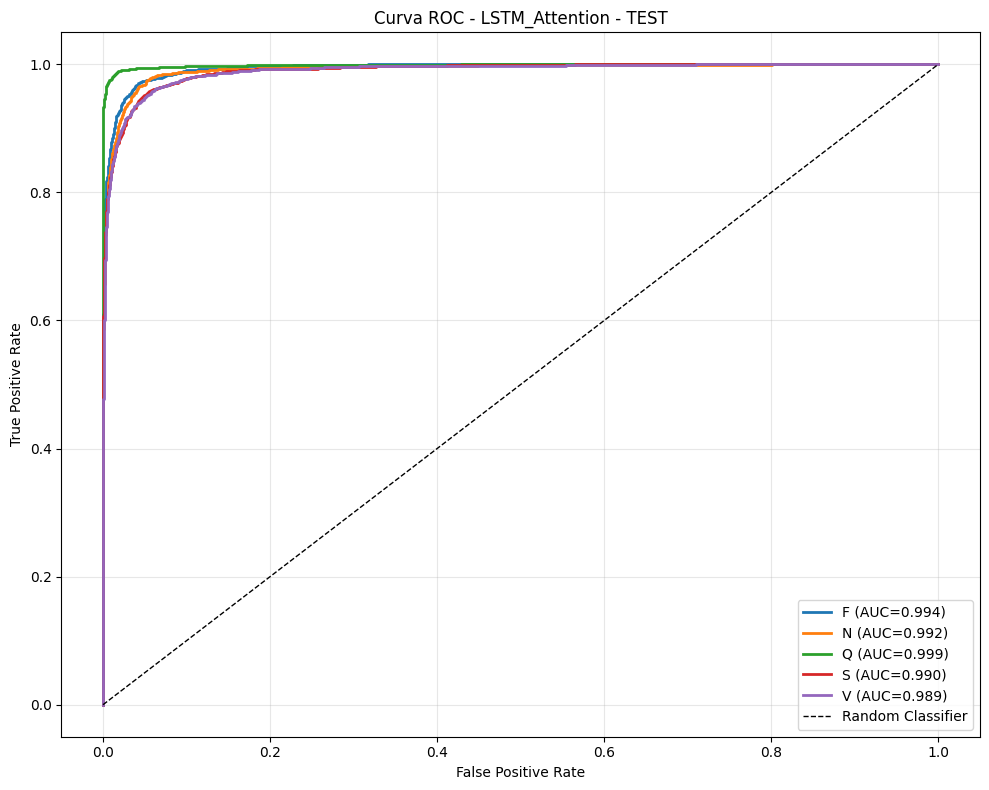

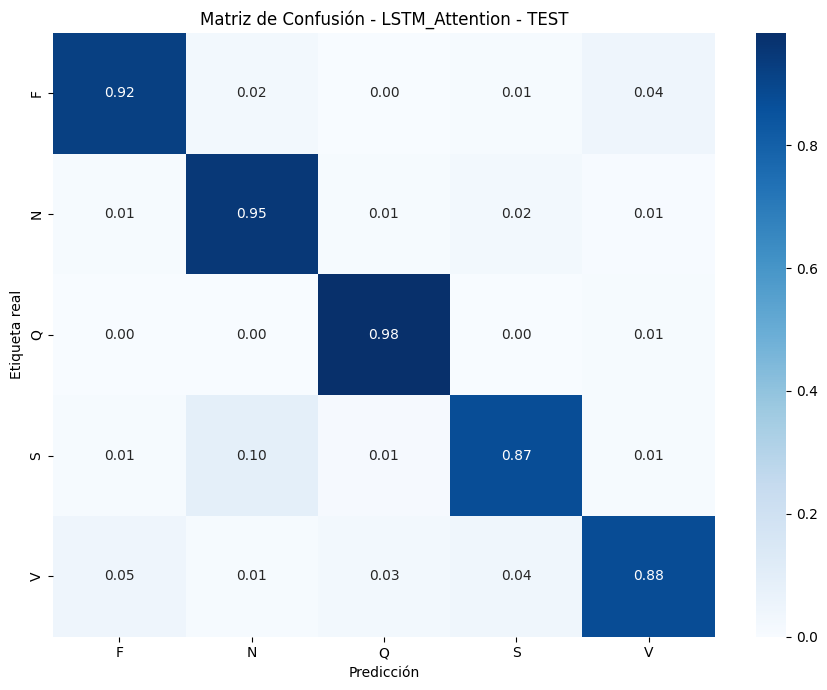

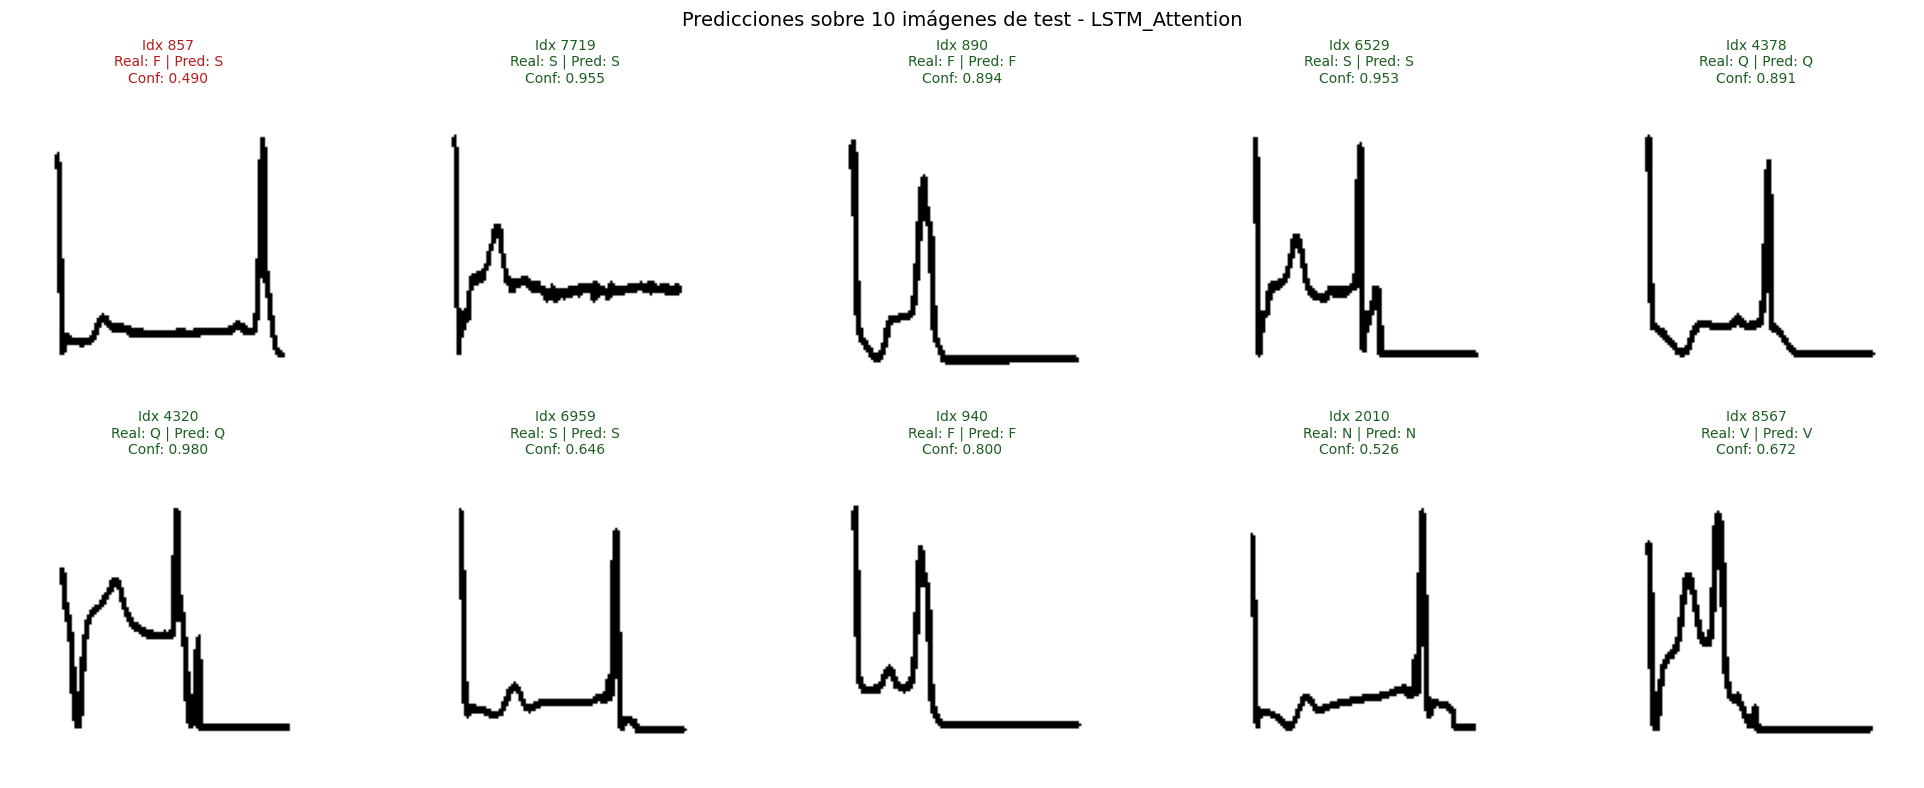

 sample_index real_class predicted_class  confidence  correct
          857          F               S    0.490045    False
         7719          S               S    0.954525     True
          890          F               F    0.894259     True
         6529          S               S    0.953111     True
         4378          Q               Q    0.891257     True
         4320          Q               Q    0.979883     True
         6959          S               S    0.646139     True
          940          F               F    0.800299     True
         2010          N               N    0.526076     True
         8567          V               V    0.672190     True

####################################################################################################
PROCESANDO MODELO: Hybrid_CNN_LSTM_Attention
####################################################################################################

[1/3] K-Fold CV omitido (modo rápido 70/30).

[2/3] Entrenamiento fin


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 640s - 523ms/step - accuracy: 0.8587 - f1_score: 0.8458 - loss: 0.3120 - precision: 0.9370 - recall: 0.7708 - val_accuracy: 0.9101 - val_f1_score: 0.9075 - val_loss: 0.1579 - val_precision: 0.9372 - val_recall: 0.8797 - learning_rate: 3.0000e-04
Epoch 2/50

Epoch 2: val_f1_score improved from 0.90755 to 0.92558, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 664s - 543ms/step - accuracy: 0.9307 - f1_score: 0.9246 - loss: 0.1460 - precision: 0.9579 - recall: 0.8935 - val_accuracy: 0.9267 - val_f1_score: 0.9256 - val_loss: 0.1249 - val_precision: 0.9456 - val_recall: 0.9063 - learning_rate: 3.0000e-04
Epoch 3/50

Epoch 3: val_f1_score did not improve from 0.92558
1224/1224 - 694s - 567ms/step - accuracy: 0.9423 - f1_score: 0.9400 - loss: 0.1110 - precision: 0.9631 - recall: 0.9180 - val_accuracy: 0.9260 - val_f1_score: 0.9240 - val_loss: 0.1225 - val_precision: 0.9423 - val_recall: 0.9063 - learning_rate: 3.0000e-04
Epoch 4/50

Epoch 4: val_f1_score improved from 0.92558 to 0.93903, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 4: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 686s - 560ms/step - accuracy: 0.9511 - f1_score: 0.9478 - loss: 0.0905 - precision: 0.9660 - recall: 0.9303 - val_accuracy: 0.9389 - val_f1_score: 0.9390 - val_loss: 0.1066 - val_precision: 0.9534 - val_recall: 0.9251 - learning_rate: 3.0000e-04
Epoch 5/50

Epoch 5: val_f1_score improved from 0.93903 to 0.94720, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 5: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 687s - 561ms/step - accuracy: 0.9555 - f1_score: 0.9533 - loss: 0.0781 - precision: 0.9681 - recall: 0.9390 - val_accuracy: 0.9477 - val_f1_score: 0.9472 - val_loss: 0.0704 - val_precision: 0.9619 - val_recall: 0.9330 - learning_rate: 3.0000e-04
Epoch 6/50

Epoch 6: val_f1_score did not improve from 0.94720
1224/1224 - 682s - 557ms/step - accuracy: 0.9602 - f1_score: 0.9581 - loss: 0.0673 - precision: 0.9701 - recall: 0.9464 - val_accuracy: 0.9415 - val_f1_score: 0.9415 - val_loss: 0.0897 - val_precision: 0.9540 - val_recall: 0.9293 - learning_rate: 3.0000e-04
Epoch 7/50

Epoch 7: val_f1_score improved from 0.94720 to 0.95265, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5


...


Epoch 18: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 717s - 586ms/step - accuracy: 0.9868 - f1_score: 0.9867 - loss: 0.0175 - precision: 0.9882 - recall: 0.9851 - val_accuracy: 0.9701 - val_f1_score: 0.9708 - val_loss: 0.0561 - val_precision: 0.9731 - val_recall: 0.9685 - learning_rate: 1.5000e-04
Epoch 19/50

Epoch 19: val_f1_score did not improve from 0.97080
1224/1224 - 699s - 571ms/step - accuracy: 0.9881 - f1_score: 0.9880 - loss: 0.0165 - precision: 0.9891 - recall: 0.9869 - val_accuracy: 0.9701 - val_f1_score: 0.9698 - val_loss: 0.0592 - val_precision: 0.9720 - val_recall: 0.9677 - learning_rate: 1.5000e-04
Epoch 20/50

Epoch 20: val_f1_score did not improve from 0.97080
1224/1224 - 690s - 564ms/step - accuracy: 0.9878 - f1_score: 0.9878 - loss: 0.0168 - precision: 0.9890 - recall: 0.9866 - val_accuracy: 0.9689 - val_f1_score: 0.9688 - val_loss: 0.0504 - val_precision: 0.9719 - v


Epoch 23: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 751s - 614ms/step - accuracy: 0.9908 - f1_score: 0.9908 - loss: 0.0117 - precision: 0.9914 - recall: 0.9901 - val_accuracy: 0.9732 - val_f1_score: 0.9735 - val_loss: 0.0624 - val_precision: 0.9746 - val_recall: 0.9725 - learning_rate: 1.5000e-04
Epoch 24/50

Epoch 24: val_f1_score improved from 0.97351 to 0.97467, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 24: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 736s - 602ms/step - accuracy: 0.9905 - f1_score: 0.9906 - loss: 0.0125 - precision: 0.9915 - recall: 0.9898 - val_accuracy: 0.9747 - val_f1_score: 0.9747 - val_loss: 0.0610 - val_precision: 0.9760 - val_recall: 0.9734 - learning_rate: 1.5000e-04
Epoch 25/50

Epoch 25: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 25: val_f1_score did not improve from 0.97467
1224/1224 - 634s - 518ms/step - accuracy: 0.9911 - f1_score: 0.9908 - loss: 0.0123 - precision: 0.9916 - recall: 0.9901 - val_accuracy: 0.9709 - val_f1_score: 0.9708 - val_loss: 0.0575 - val_precision: 0.9728 - val_recall: 0.9687 - learning_rate: 1.5000e-04
Epoch 26/50

Epoch 26: val_f1_score improved from 0.97467 to 0.97489, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 26: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 647s - 529ms/step - accuracy: 0.9924 - f1_score: 0.9924 - loss: 0.0095 - precision: 0.9931 - recall: 0.9916 - val_accuracy: 0.9745 - val_f1_score: 0.9749 - val_loss: 0.0573 - val_precision: 0.9760 - val_recall: 0.9738 - learning_rate: 7.5000e-05
Epoch 27/50

Epoch 27: val_f1_score did not improve from 0.97489
1224/1224 - 683s - 558ms/step - accuracy: 0.9936 - f1_score: 0.9935 - loss: 0.0081 - precision: 0.9940 - recall: 0.9931 - val_accuracy: 0.9743 - val_f1_score: 0.9747 - val_loss: 0.0566 - val_precision: 0.9754 - val_recall: 0.9740 - learning_rate: 7.5000e-05
Epoch 28/50

Epoch 28: val_f1_score improved from 0.97489 to 0.97560, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5



Epoch 28: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5
1224/1224 - 682s - 557ms/step - accuracy: 0.9935 - f1_score: 0.9934 - loss: 0.0081 - precision: 0.9937 - recall: 0.9931 - val_accuracy: 0.9750 - val_f1_score: 0.9756 - val_loss: 0.0606 - val_precision: 0.9767 - val_recall: 0.9745 - learning_rate: 7.5000e-05
Epoch 29/50

Epoch 29: val_f1_score did not improve from 0.97560
1224/1224 - 613s - 501ms/step - accuracy: 0.9942 - f1_score: 0.9942 - loss: 0.0074 - precision: 0.9944 - recall: 0.9941 - val_accuracy: 0.9750 - val_f1_score: 0.9756 - val_loss: 0.0621 - val_precision: 0.9766 - val_recall: 0.9745 - learning_rate: 7.5000e-05
Epoch 30/50

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 30: val_f1_score did not improve from 0.97560
1224/1224 - 617s - 504ms/step - accuracy: 0.9942 - f1_score: 0.9941 - loss: 0.0066 - precision: 0.9944 - recall: 0.9939 - val_accurac

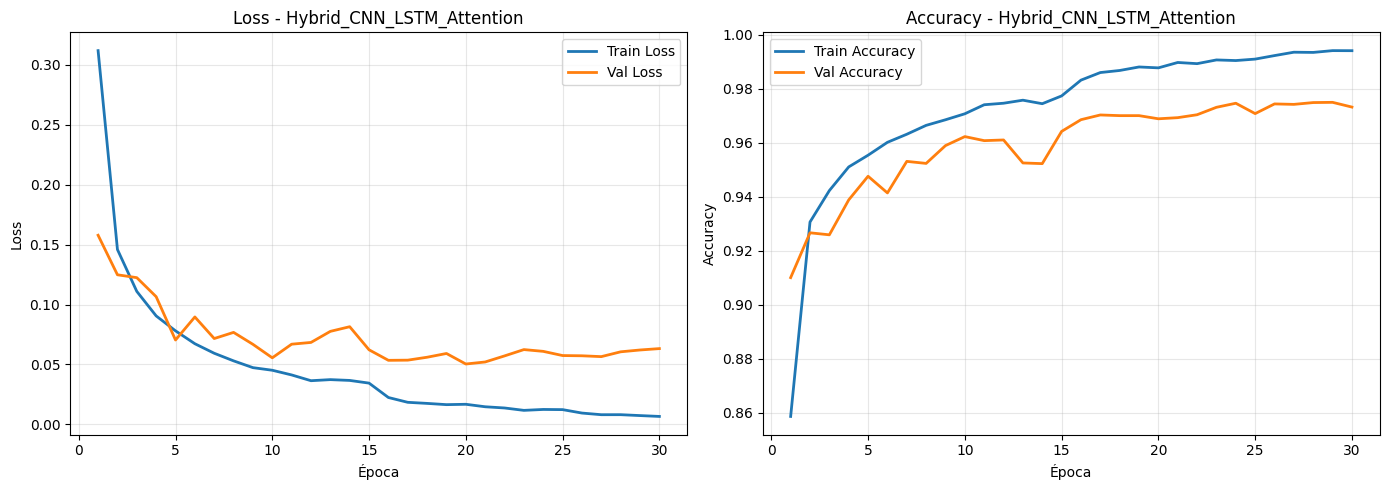


Hybrid_CNN_LSTM_Attention - EVALUACIÓN EN TRAIN
Accuracy: 0.9838
F1-Macro: 0.9838
F1-Weighted: 0.9838

Classification Report:
              precision    recall  f1-score   support

           F     0.9668    0.9961    0.9812      7951
           N     0.9877    0.9826    0.9851      8000
           Q     0.9910    0.9969    0.9940      7995
           S     0.9869    0.9731    0.9800      7988
           V     0.9869    0.9702    0.9785      7994

    accuracy                         0.9838     39928
   macro avg     0.9839    0.9838    0.9838     39928
weighted avg     0.9839    0.9838    0.9838     39928



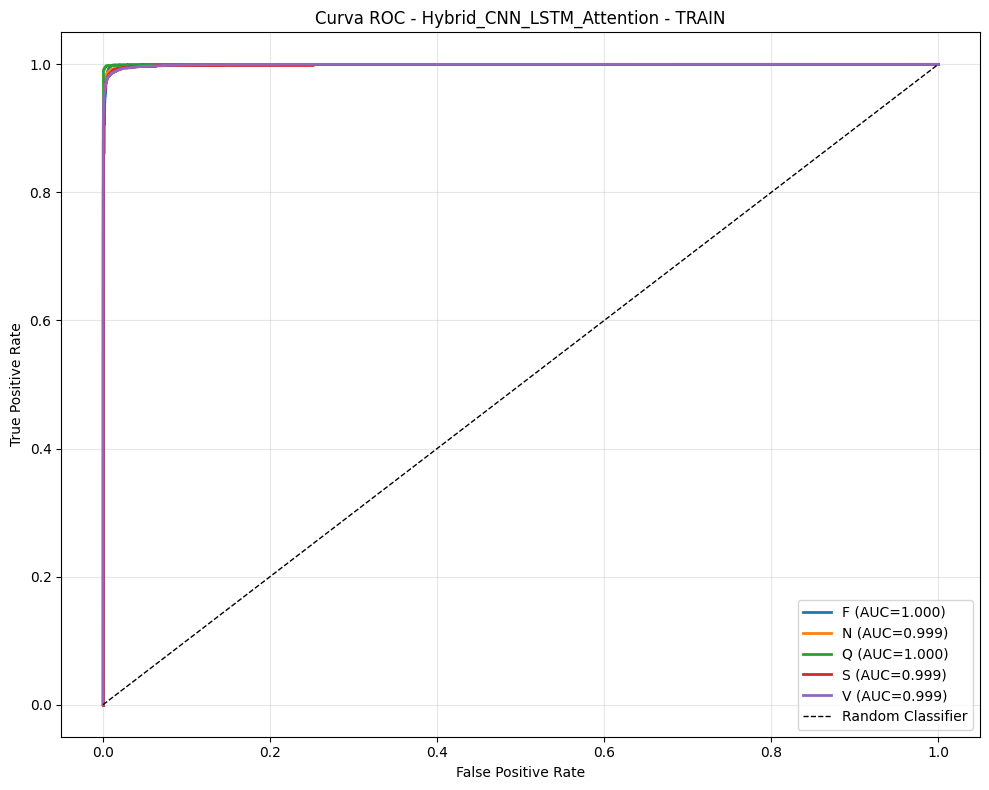

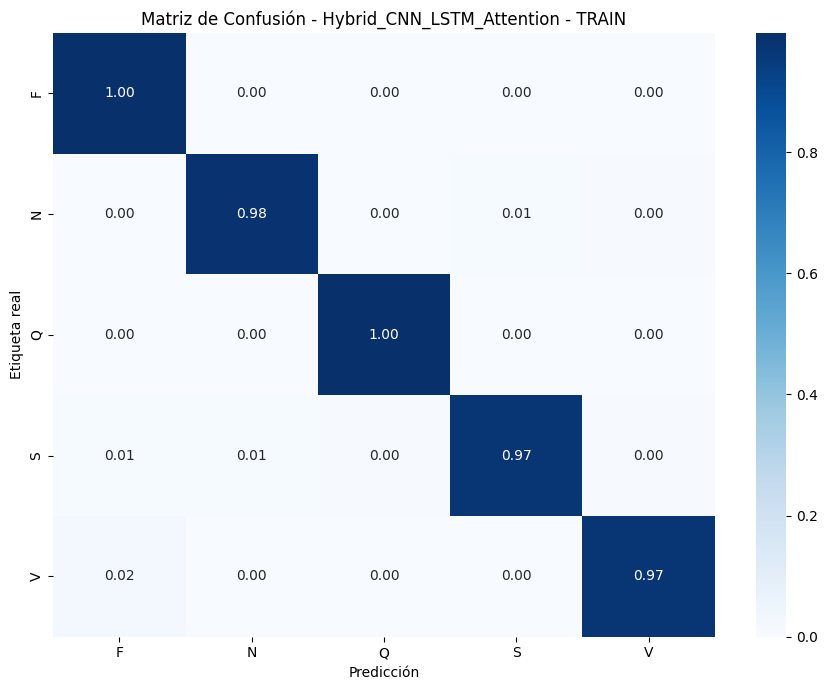


Hybrid_CNN_LSTM_Attention - EVALUACIÓN EN TEST
Accuracy: 0.9703
F1-Macro: 0.9703
F1-Weighted: 0.9703

Classification Report:
              precision    recall  f1-score   support

           F     0.9455    0.9945    0.9694      1988
           N     0.9791    0.9600    0.9695      2000
           Q     0.9817    0.9915    0.9866      1999
           S     0.9721    0.9589    0.9655      1997
           V     0.9748    0.9469    0.9606      1998

    accuracy                         0.9703      9982
   macro avg     0.9706    0.9704    0.9703      9982
weighted avg     0.9706    0.9703    0.9703      9982



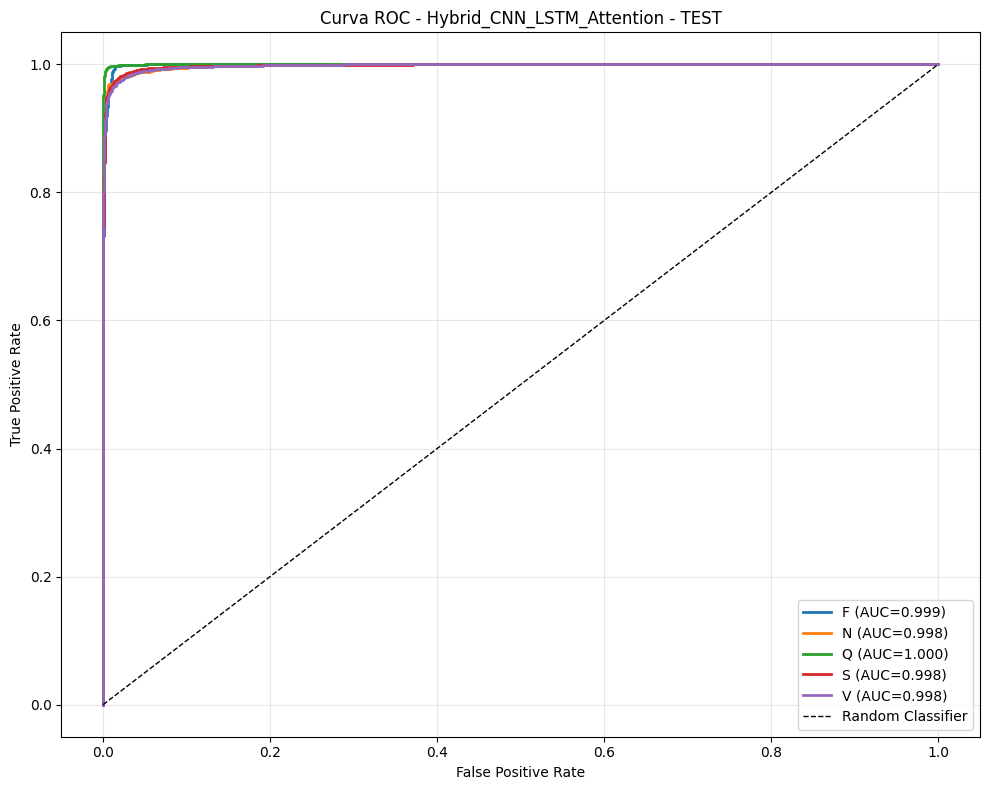

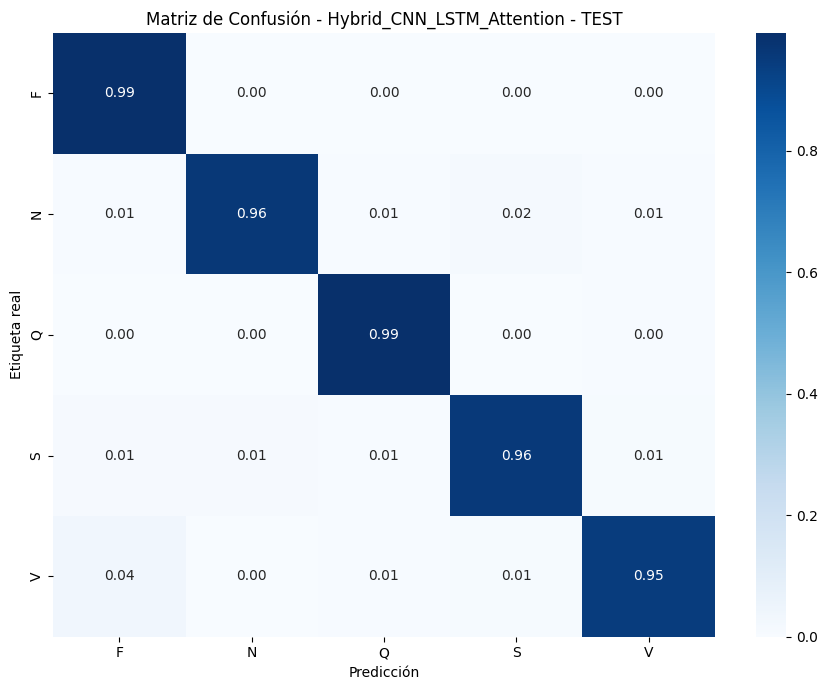

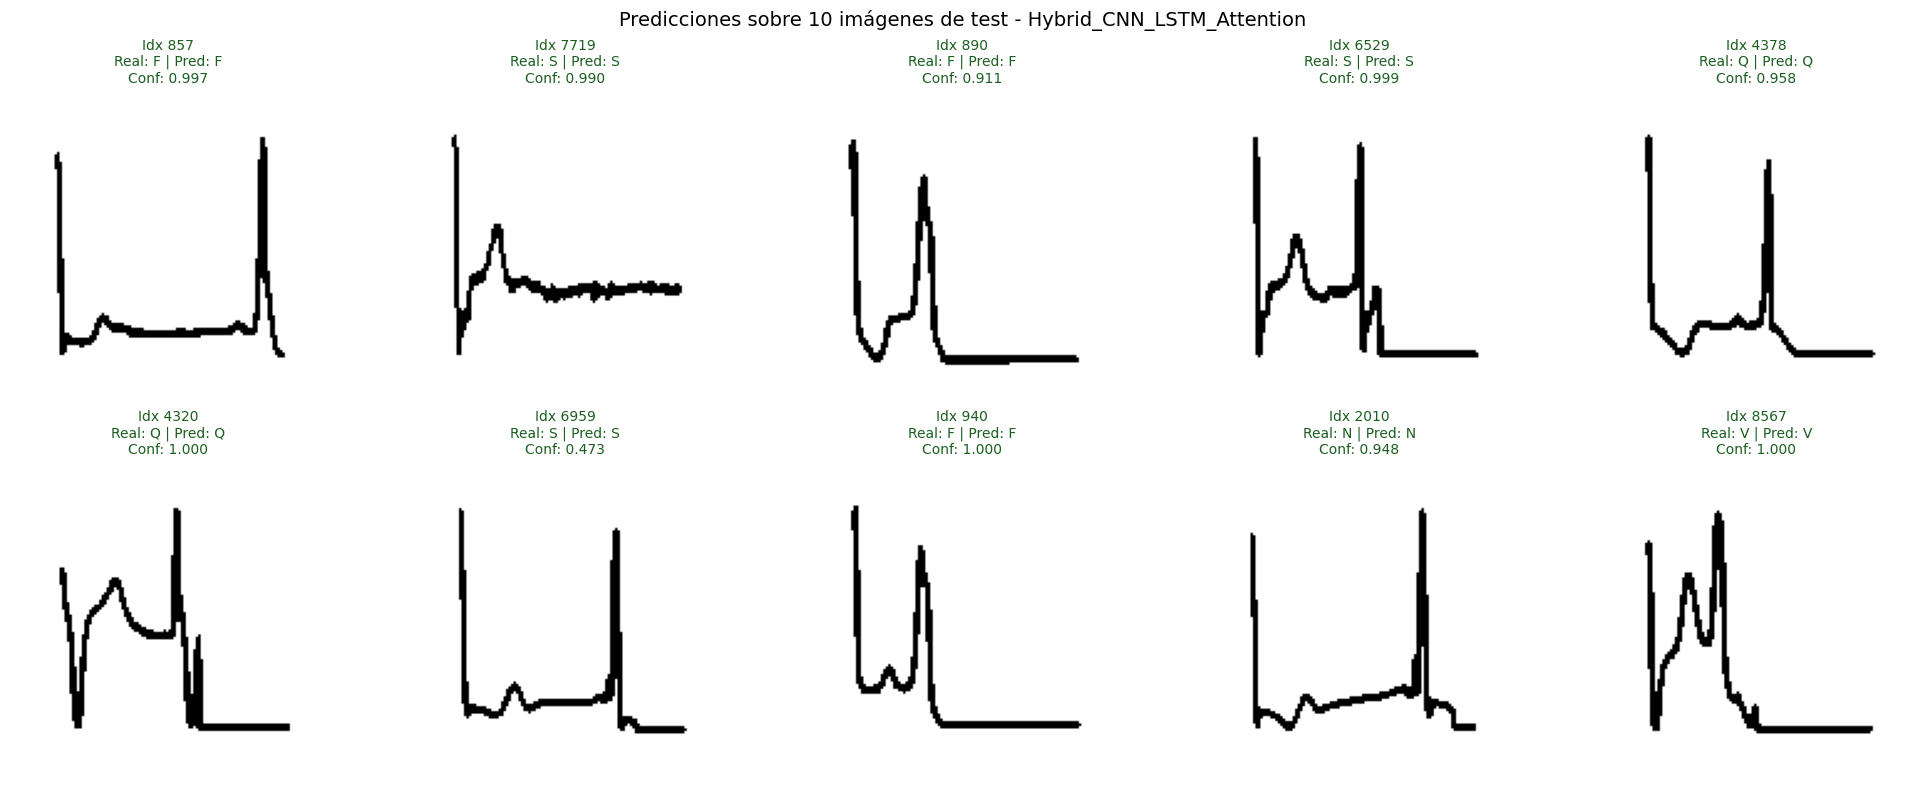

 sample_index real_class predicted_class  confidence  correct
          857          F               F    0.996642     True
         7719          S               S    0.989721     True
          890          F               F    0.911252     True
         6529          S               S    0.998707     True
         4378          Q               Q    0.957730     True
         4320          Q               Q    0.999993     True
         6959          S               S    0.473214     True
          940          F               F    0.999983     True
         2010          N               N    0.947930     True
         8567          V               V    0.999870     True

####################################################################################################
PROCESANDO MODELO: ResNet50_Spatial
####################################################################################################

[1/3] K-Fold CV omitido (modo rápido 70/30).

[2/3] Entrenamiento final y diag


❌ Error procesando ResNet50_Spatial: [Errno 28] Can't synchronously write data (file write failed: time = Thu Mar 19 10:42:52 2026
, filename = '/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_ResNet50_Spatial.h5', file descriptor = 101, errno = 28, error message = 'No space left on device', buf = 0x147110000, total write size = 4194304, bytes this sub-write = 4194304, offset = 44507192)

[FASE 3] ANÁLISIS COMPARATIVO GLOBAL
[INFO] Métricas CV se muestran como NaN porque K-Fold fue omitido intencionalmente.


Traceback (most recent call last):
  File "/var/folders/jv/wpc3lncj5lg9gdsl2cfm7pww0000gn/T/ipykernel_21290/2302287298.py", line 78, in run_crisp_ml_improved
    final_result = train_final_model_with_diagnostics(
        model_class,
    ...<9 lines>...
        model_kwargs=model_kwargs
    )
  File "/var/folders/jv/wpc3lncj5lg9gdsl2cfm7pww0000gn/T/ipykernel_21290/586774457.py", line 205, in train_final_model_with_diagnostics
    history = model.fit(
        X_train_fit,
    ...<6 lines>...
        verbose=2
    )
  File "/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/.venv/lib/python3.13/site-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "h5py/_objects.pyx", line 56, in h5py._objects.with_phil.wrapper
  File "h5py/_objects.pyx", line 57, in h5py._objects.with_phil.wrapper
  File "/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/.venv/lib/python3.13/site-packages/h5py/_hl/dataset.p

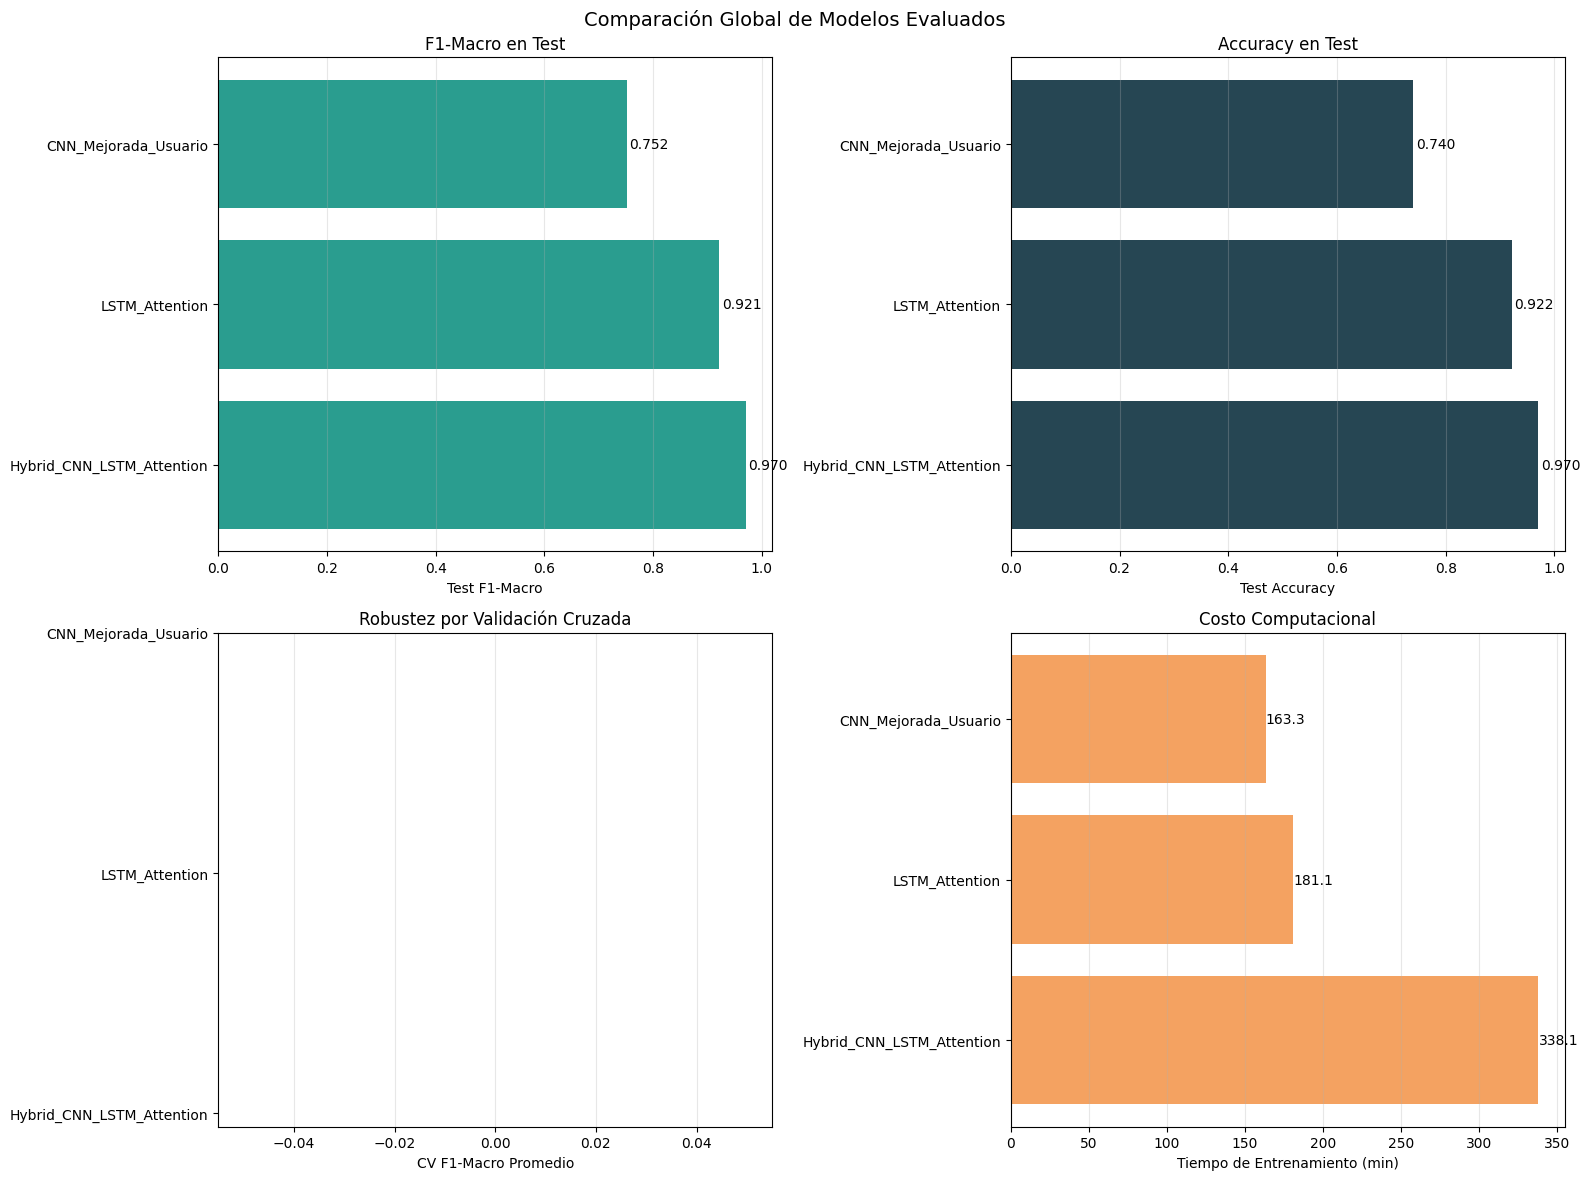


ANÁLISIS COMPARATIVO Y SELECCIÓN DEL MEJOR MODELO
                   Modelo  Train_Accuracy  Train_F1_Macro  Test_Accuracy  Test_F1_Macro  Test_F1_Weighted  CV_F1_Macro_Mean  CV_F1_Macro_Std  Tiempo_min  Epochs  Params
Hybrid_CNN_LSTM_Attention        0.983771        0.983755       0.970347       0.970297          0.970299               NaN              NaN  338.081463      30 2035015
           LSTM_Attention        0.927770        0.927569       0.921759       0.921446          0.921444               NaN              NaN  181.108928      50  190086
     CNN_Mejorada_Usuario        0.743864        0.756097       0.740433       0.751594          0.751589               NaN              NaN  163.289475      26  110725

Mejor modelo seleccionado: Hybrid_CNN_LSTM_Attention
- Test F1-Macro: 0.9703
- Test Accuracy: 0.9703
- CV F1-Macro promedio: nan
- Tiempo de entrenamiento: 338.08 min
- Parámetros: 2,035,015

Justificación breve para la tesis:
Se selecciona Hybrid_CNN_LSTM_Attention porqu


[✗ Error] No se pudo guardar best_model_Hybrid_CNN_LSTM_Attention.h5: [Errno 28] Can't synchronously write data (file write failed: time = Thu Mar 19 10:42:53 2026
, filename = '/Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_Hybrid_CNN_LSTM_Attention.h5', file descriptor = 101, errno = 28, error message = 'No space left on device', buf = 0x144838000, total write size = 3145728, bytes this sub-write = 3145728, offset = 657576)

[✓ Modelo #2] best_model_LSTM_Attention.h5 (sobrescrito)
    Arquitectura: LSTM_Attention
    Origen: test
    Fold: final
    Mejor época: 50
    Mejor val_accuracy: 0.9204
    Mejor val_loss: 0.1048
    F1-Macro: 0.9214
    Accuracy: 0.9218
    Guardado en: /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_LSTM_Attention.h5

[✓ Modelo #3] best_model_CNN_Mejorada_Usuario.h5 (sobrescrito)
    Arquitectura: CNN_Mejorada_Usuario
    Origen: test
    Fold: final
    Mejor época: 16
    Mejor val_accuracy: 0.7

In [9]:
def run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT):
    """
    Pipeline completo CRISP-ML(Q) Mejorado.

    - run_kfold=True: usa K-Fold para comparación de arquitectura + entrenamiento final 70/30.
    - run_kfold=False: modo rápido, ejecuta solo el bloque final 70/30.
    """

    print("\n" + "=" * 100)
    print("CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)")
    print(f"Modo K-Fold: {'ACTIVADO' if run_kfold else 'DESACTIVADO (rápido 70/30)'}")
    print("=" * 100)

    print("\n[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS")
    print("=" * 100)
    loader = BalancedECGDataLoader(DATASET_PATH, img_size=IMG_SIZE, use_percentage=USE_PERCENTAGE)

    print(f"\nCargando TRAIN ({USE_PERCENTAGE*100:.0f}%)...")
    X_train, y_train_labels, class_names, train_dist = loader.load_dataset('train')
    print(f"✓ Train cargado: {X_train.shape}")
    print(f"  Clases: {class_names}")

    print(f"\nCargando TEST ({USE_PERCENTAGE*100:.0f}%)...")
    X_test, y_test_labels, _, test_dist = loader.load_dataset('test')
    print(f"✓ Test cargado: {X_test.shape}")

    print("\nDistribución TRAIN:")
    for cls in class_names:
        print(f"  {cls}: {train_dist.get(cls, 0):,d}")
    print("\nDistribución TEST:")
    for cls in class_names:
        print(f"  {cls}: {test_dist.get(cls, 0):,d}")

    y_train = to_categorical(y_train_labels, num_classes=len(class_names))
    y_test = to_categorical(y_test_labels, num_classes=len(class_names))

    print("\n[FASE 2] MODELADO Y EVALUACIÓN")
    print("=" * 100)

    models_to_test = [
        (ImprovedCNNModel, 'CNN_Mejorada_Usuario', 3e-4, {}),
        (LSTMWithAttentionModel, 'LSTM_Attention', 3e-4, {}),
        (HybridCNNLSTMWithAttentionModel, 'Hybrid_CNN_LSTM_Attention', 3e-4, {}),
        (ResNet50WithSpatialAttention, 'ResNet50_Spatial', 1e-4, {'trainable_from': 140}),
    ]

    cv_results = {}
    final_results = {}
    final_models_for_saving = []

    for model_class, model_name, learning_rate, model_kwargs in models_to_test:
        print("\n" + "#" * 100)
        print(f"PROCESANDO MODELO: {model_name}")
        print("#" * 100)

        batch_size = 16 if 'ResNet50' in model_name else BATCH_SIZE

        try:
            if run_kfold:
                print(f"\n[1/3] K-Fold CV para {model_name}")
                fold_results, df_folds, _ = train_and_evaluate_kfold(
                    model_class,
                    model_name,
                    X_train,
                    y_train,
                    class_names,
                    n_splits=N_SPLITS,
                    learning_rate=learning_rate,
                    epochs=EPOCHS,
                    batch_size=batch_size,
                    model_kwargs=model_kwargs
                )
                cv_results[model_name] = (fold_results, df_folds)
            else:
                print("\n[1/3] K-Fold CV omitido (modo rápido 70/30).")

            print(f"\n[2/3] Entrenamiento final y diagnósticos para {model_name}")
            final_result = train_final_model_with_diagnostics(
                model_class,
                model_name,
                X_train,
                y_train,
                X_test,
                y_test,
                class_names,
                learning_rate=learning_rate,
                epochs=EPOCHS,
                batch_size=batch_size,
                model_kwargs=model_kwargs
            )
            final_results[model_name] = final_result

            final_models_for_saving.append({
                'model': final_result['model'],
                'model_name': model_name,
                'fold': 'final',
                'split': 'test',
                'f1_macro': final_result['test_metrics']['f1_macro'],
                'accuracy': final_result['test_metrics']['accuracy'],
                'best_epoch': final_result['best_epoch'],
                'best_val_accuracy': final_result['best_val_accuracy'],
                'best_val_loss': final_result['best_val_loss'],
                'best_model_path': final_result['best_model_path']
            })
        except Exception as e:
            print(f"\n❌ Error procesando {model_name}: {e}")
            import traceback
            traceback.print_exc()

    print("\n[FASE 3] ANÁLISIS COMPARATIVO GLOBAL")
    print("=" * 100)
    if not run_kfold:
        print("[INFO] Métricas CV se muestran como NaN porque K-Fold fue omitido intencionalmente.")

    results_df = build_comparison_table(final_results, cv_results)
    plot_comparison_horizontal(results_df)
    print_model_selection_justification(results_df)

    print("\n[FASE 4] GUARDADO DEL MEJOR MODELO POR ARQUITECTURA")
    print("=" * 100)
    saved_models = save_top_models(final_models_for_saving, top_n=len(final_models_for_saving))

    return {
        'cv_results': cv_results,
        'final_results': final_results,
        'comparison_table': results_df,
        'saved_models': saved_models,
        'class_names': class_names,
        'X_test': X_test,
        'y_test_labels': y_test_labels
    }


print("\n\n⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...")
print("Se evaluarán modelos y se generarán gráficos, tablas y justificación final.\n")

try:
    pipeline_outputs = run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT)
    print("\n\n✅ PIPELINE COMPLETADO EXITOSAMENTE")
    print(f"Modelos evaluados: {len(pipeline_outputs['final_results'])}")
    print(f"Modelos guardados: {len(pipeline_outputs['saved_models'])}")
except Exception as e:
    print(f"\n\n❌ ERROR EN EL PIPELINE: {e}")
    import traceback
    traceback.print_exc()



⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...
Se evaluarán modelos y se generarán gráficos, tablas y justificación final.


CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)
Modo K-Fold: DESACTIVADO (rápido 70/30)

[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS

Cargando TRAIN (10%)...
  [train] F: cargadas 7,951 de 79,516 (10.0%)
  [train] N: cargadas 8,000 de 80,000 (10.0%)
  [train] Q: cargadas 7,995 de 79,959 (10.0%)
  [train] S: cargadas 7,988 de 79,884 (10.0%)
  [train] V: cargadas 7,994 de 79,948 (10.0%)
✓ Train cargado: (39928, 128, 128, 1)
  Clases: ['F', 'N', 'Q', 'S', 'V']

Cargando TEST (10%)...
  [test] F: cargadas 1,988 de 19,880 (10.0%)
  [test] N: cargadas 2,000 de 20,000 (10.0%)
  [test] Q: cargadas 1,999 de 19,990 (10.0%)
  [test] S: cargadas 1,997 de 19,971 (10.0%)
  [test] V: cargadas 1,998 de 19,987 (10.0%)
✓ Test cargado: (9982, 128, 128, 1)

Distribución TRAIN:
  F: 7,951
  N: 8,000
  Q: 7,995
  S: 7,988
  V: 7,994

Distribución TE


Epoch 1: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 117s - 95ms/step - accuracy: 0.7639 - f1_score: 0.7307 - loss: 0.5027 - precision: 0.9040 - recall: 0.6131 - val_accuracy: 0.8423 - val_f1_score: 0.6464 - val_loss: 0.3558 - val_precision: 0.9856 - val_recall: 0.4809 - learning_rate: 3.0000e-04
Epoch 2/50

Epoch 2: val_f1_score improved from 0.64643 to 0.78554, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 2: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 117s - 96ms/step - accuracy: 0.8880 - f1_score: 0.8792 - loss: 0.2185 - precision: 0.9337 - recall: 0.8307 - val_accuracy: 0.8935 - val_f1_score: 0.7855 - val_loss: 0.2527 - val_precision: 0.9798 - val_recall: 0.6556 - learning_rate: 3.0000e-04
Epoch 3/50

Epoch 3: val_f1_score improved from 0.78554 to 0.85438, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 3: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 119s - 97ms/step - accuracy: 0.9154 - f1_score: 0.9105 - loss: 0.1581 - precision: 0.9474 - recall: 0.8764 - val_accuracy: 0.9112 - val_f1_score: 0.8544 - val_loss: 0.1809 - val_precision: 0.9801 - val_recall: 0.7572 - learning_rate: 3.0000e-04
Epoch 4/50

Epoch 4: val_f1_score improved from 0.85438 to 0.88400, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 4: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 122s - 100ms/step - accuracy: 0.9300 - f1_score: 0.9263 - loss: 0.1257 - precision: 0.9550 - recall: 0.8992 - val_accuracy: 0.9113 - val_f1_score: 0.8840 - val_loss: 0.1409 - val_precision: 0.9672 - val_recall: 0.8140 - learning_rate: 3.0000e-04
Epoch 5/50

Epoch 5: val_f1_score improved from 0.88400 to 0.89683, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5


...


Epoch 37: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 143s - 117ms/step - accuracy: 0.9916 - f1_score: 0.9915 - loss: 0.0103 - precision: 0.9921 - recall: 0.9909 - val_accuracy: 0.9798 - val_f1_score: 0.9806 - val_loss: 0.0306 - val_precision: 0.9831 - val_recall: 0.9782 - learning_rate: 1.5000e-04
Epoch 38/50

Epoch 38: val_f1_score did not improve from 0.98063
1224/1224 - 139s - 113ms/step - accuracy: 0.9917 - f1_score: 0.9918 - loss: 0.0093 - precision: 0.9923 - recall: 0.9912 - val_accuracy: 0.9797 - val_f1_score: 0.9798 - val_loss: 0.0302 - val_precision: 0.9822 - val_recall: 0.9775 - learning_rate: 1.5000e-04
Epoch 39/50

Epoch 39: val_f1_score did not improve from 0.98063
1224/1224 - 144s - 118ms/step - accuracy: 0.9921 - f1_score: 0.9922 - loss: 0.0096 - precision: 0.9927 - recall: 0.9917 - val_accuracy: 0.9809 - val_f1_score: 0.9806 - val_loss: 0.0280 - val_precision: 0.9833 - val_re


Epoch 40: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 142s - 116ms/step - accuracy: 0.9930 - f1_score: 0.9929 - loss: 0.0085 - precision: 0.9933 - recall: 0.9926 - val_accuracy: 0.9810 - val_f1_score: 0.9812 - val_loss: 0.0316 - val_precision: 0.9838 - val_recall: 0.9786 - learning_rate: 1.5000e-04
Epoch 41/50

Epoch 41: val_f1_score did not improve from 0.98121
1224/1224 - 137s - 112ms/step - accuracy: 0.9931 - f1_score: 0.9931 - loss: 0.0085 - precision: 0.9935 - recall: 0.9926 - val_accuracy: 0.9790 - val_f1_score: 0.9791 - val_loss: 0.0317 - val_precision: 0.9813 - val_recall: 0.9769 - learning_rate: 1.5000e-04
Epoch 42/50

Epoch 42: val_f1_score did not improve from 0.98121
1224/1224 - 143s - 117ms/step - accuracy: 0.9930 - f1_score: 0.9930 - loss: 0.0083 - precision: 0.9934 - recall: 0.9927 - val_accuracy: 0.9783 - val_f1_score: 0.9785 - val_loss: 0.0360 - val_precision: 0.9804 - val_re


Epoch 46: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 136s - 111ms/step - accuracy: 0.9946 - f1_score: 0.9946 - loss: 0.0065 - precision: 0.9948 - recall: 0.9943 - val_accuracy: 0.9816 - val_f1_score: 0.9817 - val_loss: 0.0294 - val_precision: 0.9837 - val_recall: 0.9797 - learning_rate: 7.5000e-05
Epoch 47/50

Epoch 47: val_f1_score improved from 0.98168 to 0.98172, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 47: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 136s - 111ms/step - accuracy: 0.9947 - f1_score: 0.9946 - loss: 0.0063 - precision: 0.9947 - recall: 0.9944 - val_accuracy: 0.9816 - val_f1_score: 0.9817 - val_loss: 0.0314 - val_precision: 0.9837 - val_recall: 0.9797 - learning_rate: 7.5000e-05
Epoch 48/50

Epoch 48: val_f1_score improved from 0.98172 to 0.98277, saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5



Epoch 48: finished saving model to /Users/lilianestefaniamaradiagocorrea/Desktop/TrainECG_app/models/best_model_CNN_Mejorada_Usuario.h5
1224/1224 - 137s - 112ms/step - accuracy: 0.9953 - f1_score: 0.9952 - loss: 0.0059 - precision: 0.9954 - recall: 0.9951 - val_accuracy: 0.9826 - val_f1_score: 0.9828 - val_loss: 0.0285 - val_precision: 0.9844 - val_recall: 0.9811 - learning_rate: 7.5000e-05
Epoch 49/50

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 49: val_f1_score did not improve from 0.98277
1224/1224 - 138s - 113ms/step - accuracy: 0.9955 - f1_score: 0.9955 - loss: 0.0050 - precision: 0.9956 - recall: 0.9953 - val_accuracy: 0.9819 - val_f1_score: 0.9818 - val_loss: 0.0311 - val_precision: 0.9838 - val_recall: 0.9799 - learning_rate: 7.5000e-05
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 39.
Mejor epoca seleccionada: 39 | val_accuracy=0.9809 | val_loss=0.0280


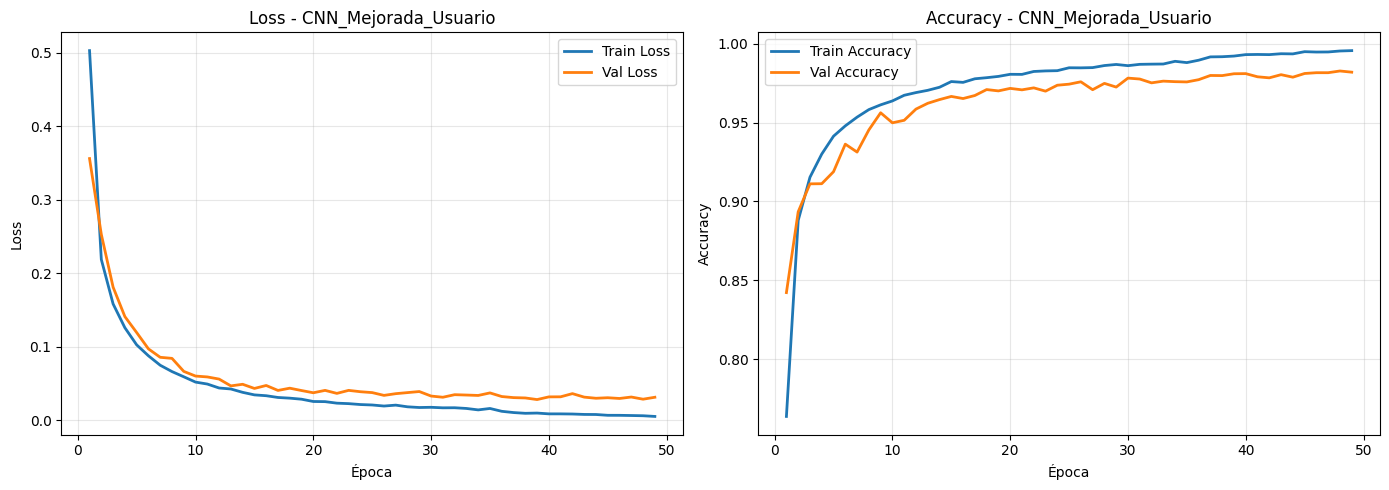


CNN_Mejorada_Usuario - EVALUACIÓN EN TRAIN
Accuracy: 0.9921
F1-Macro: 0.9921
F1-Weighted: 0.9921

Classification Report:
              precision    recall  f1-score   support

           F     0.9857    0.9965    0.9911      7951
           N     0.9887    0.9918    0.9902      8000
           Q     0.9986    0.9967    0.9977      7995
           S     0.9942    0.9901    0.9922      7988
           V     0.9936    0.9856    0.9896      7994

    accuracy                         0.9921     39928
   macro avg     0.9922    0.9921    0.9921     39928
weighted avg     0.9922    0.9921    0.9921     39928



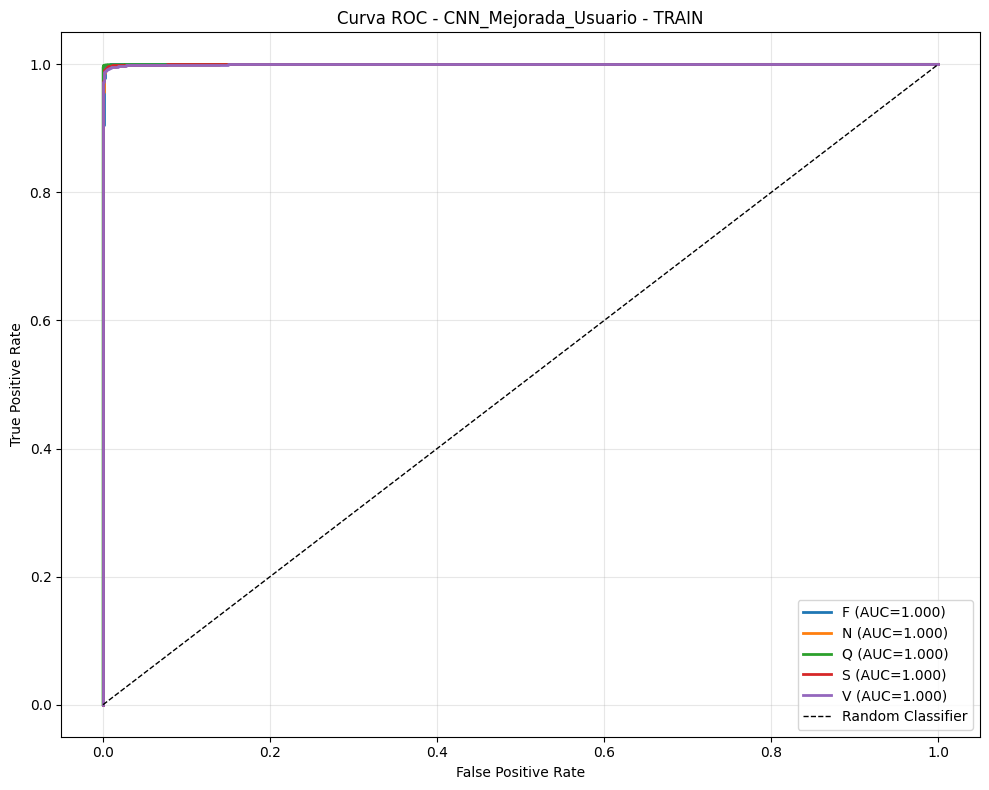

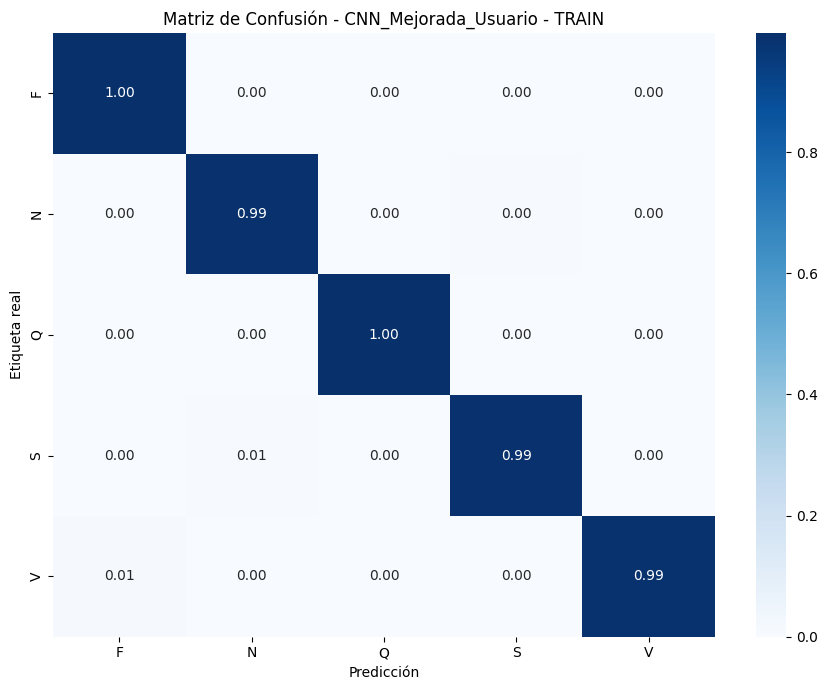


CNN_Mejorada_Usuario - EVALUACIÓN EN TEST
Accuracy: 0.9782
F1-Macro: 0.9782
F1-Weighted: 0.9782

Classification Report:
              precision    recall  f1-score   support

           F     0.9729    0.9925    0.9826      1988
           N     0.9637    0.9685    0.9661      2000
           Q     0.9955    0.9920    0.9937      1999
           S     0.9773    0.9710    0.9741      1997
           V     0.9817    0.9670    0.9743      1998

    accuracy                         0.9782      9982
   macro avg     0.9782    0.9782    0.9782      9982
weighted avg     0.9782    0.9782    0.9782      9982



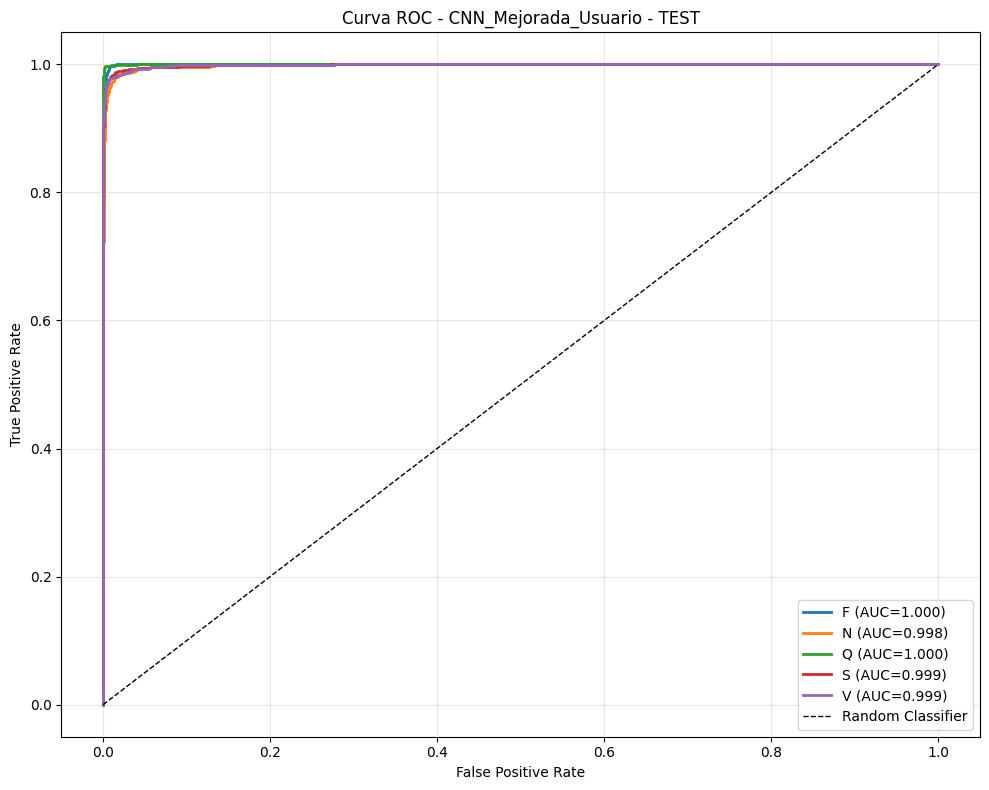

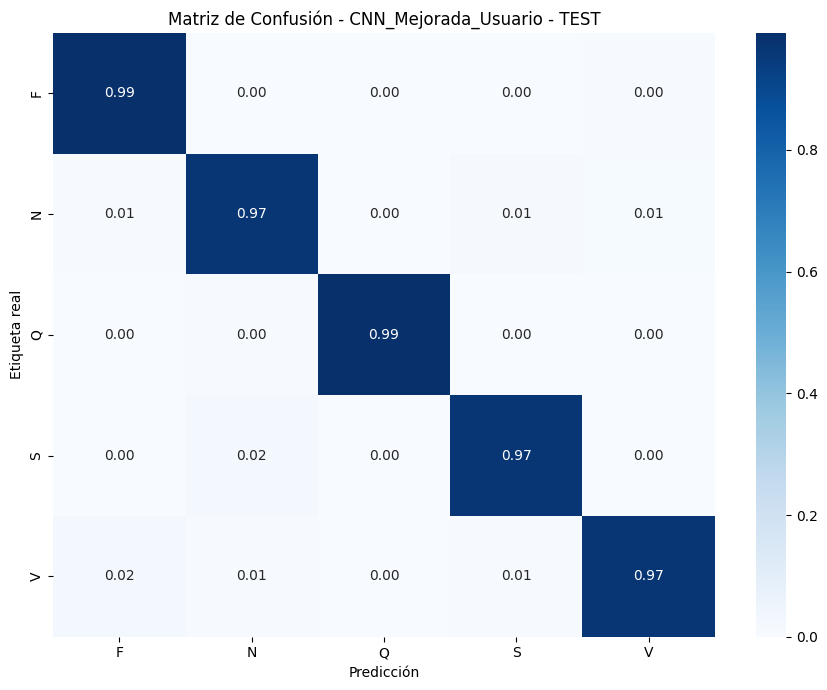

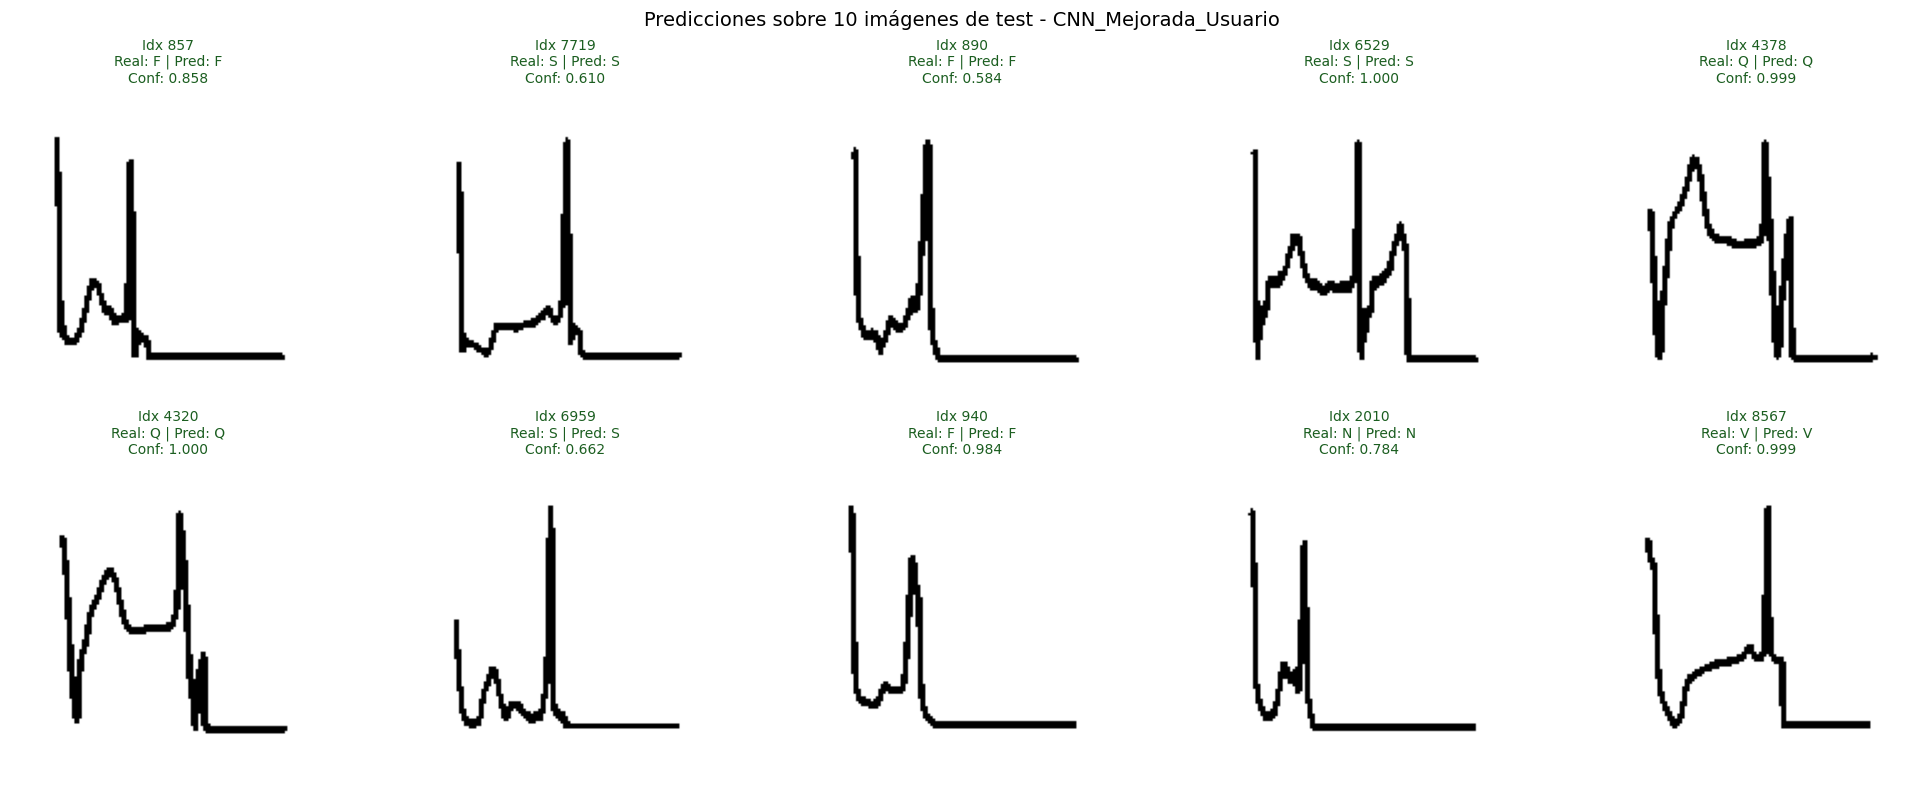

 sample_index real_class predicted_class  confidence  correct
          857          F               F    0.857993     True
         7719          S               S    0.609981     True
          890          F               F    0.584473     True
         6529          S               S    0.999732     True
         4378          Q               Q    0.999468     True
         4320          Q               Q    0.999992     True
         6959          S               S    0.661765     True
          940          F               F    0.984163     True
         2010          N               N    0.784455     True
         8567          V               V    0.998733     True

[FASE 3] ANÁLISIS COMPARATIVO GLOBAL
[INFO] Métricas CV se muestran como NaN porque K-Fold fue omitido intencionalmente.


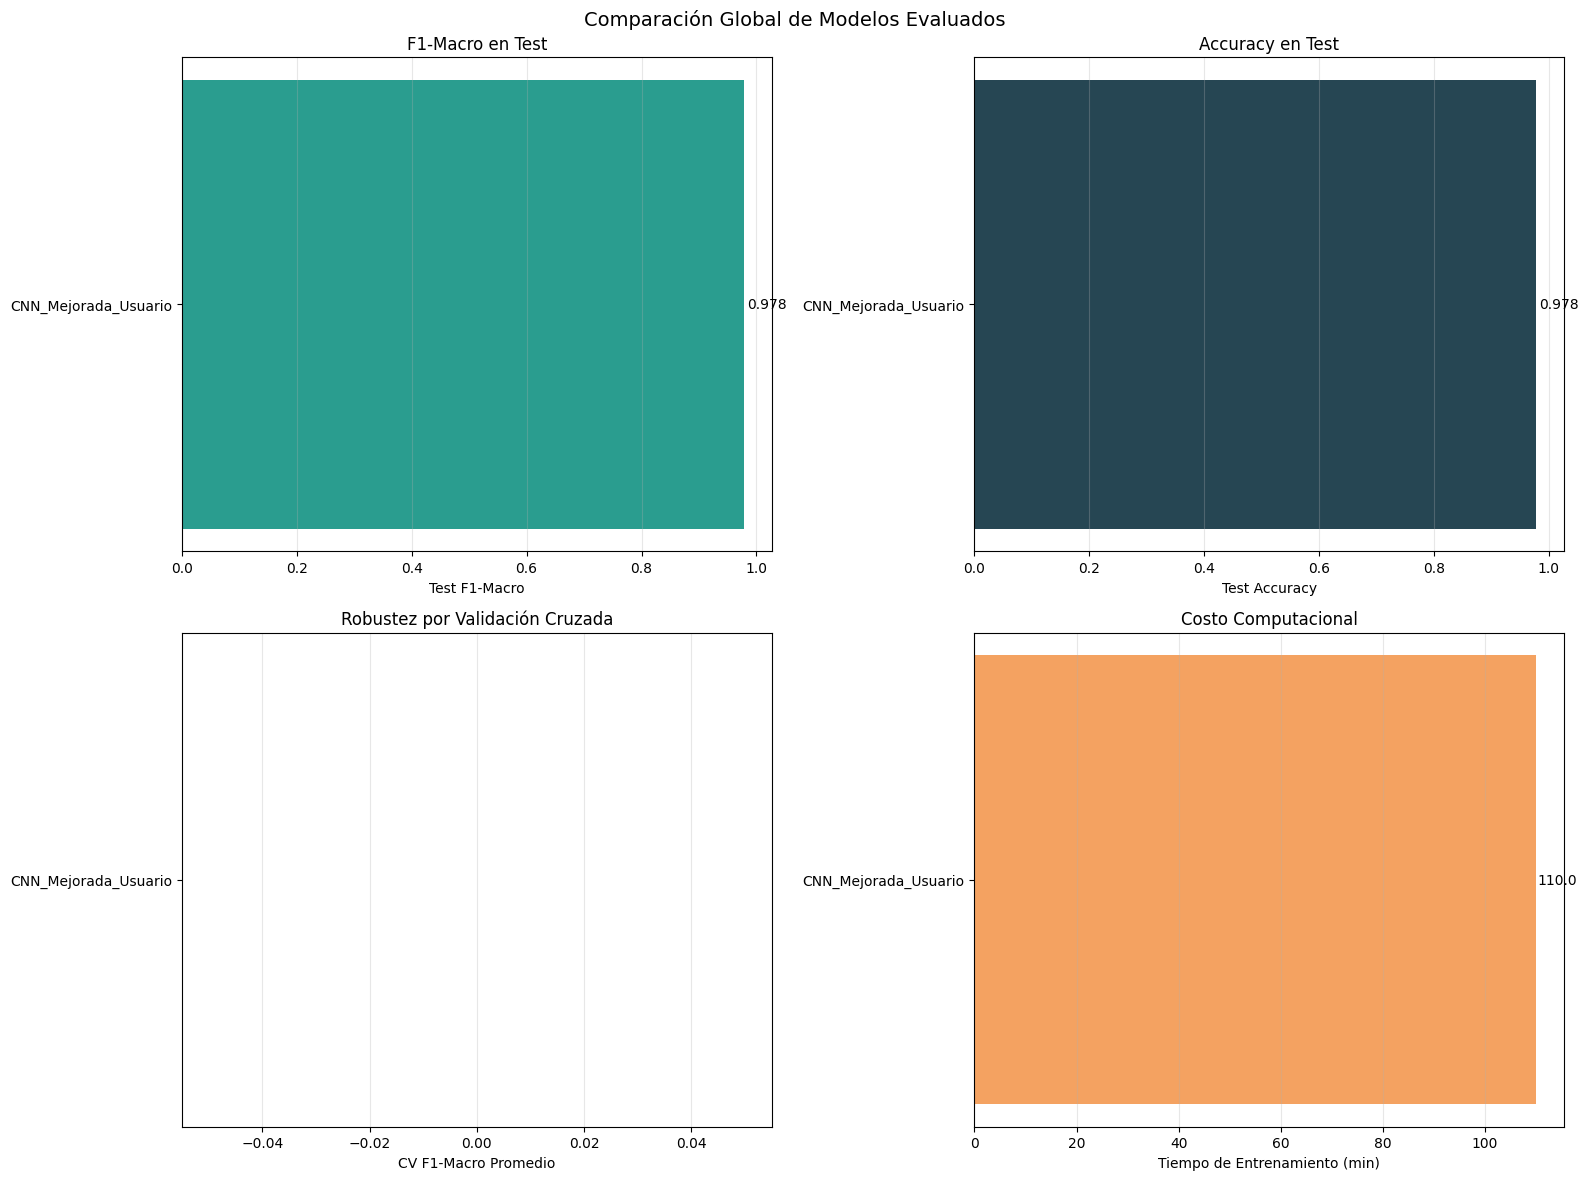


ANÁLISIS COMPARATIVO Y SELECCIÓN DEL MEJOR MODELO
              Modelo  Train_Accuracy  Train_F1_Macro  Test_Accuracy  Test_F1_Macro  Test_F1_Weighted  CV_F1_Macro_Mean  CV_F1_Macro_Std  Tiempo_min  Epochs  Params
CNN_Mejorada_Usuario        0.992136        0.992136       0.978161        0.97816          0.978155               NaN              NaN  110.034082      49  320741

Mejor modelo seleccionado: CNN_Mejorada_Usuario
- Test F1-Macro: 0.9782
- Test Accuracy: 0.9782
- CV F1-Macro promedio: nan
- Tiempo de entrenamiento: 110.03 min
- Parámetros: 320,741

Justificación breve para la tesis:
Se selecciona CNN_Mejorada_Usuario porque obtuvo el mejor balance entre desempeño en test, estabilidad en validación cruzada y costo computacional. En el contexto de TrainECG, esto es valioso porque el sistema debe clasificar trazos ECG de forma confiable y consistente, incluso cuando existen variaciones morfológicas entre clases. Además, mejora la extracción espacial respecto a la CNN base con ma

In [13]:
def run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT):
    """
    Pipeline completo CRISP-ML(Q) Mejorado.

    - run_kfold=True: usa K-Fold para comparación de arquitectura + entrenamiento final 70/30.
    - run_kfold=False: modo rápido, ejecuta solo el bloque final 70/30.
    """

    print("\n" + "=" * 100)
    print("CRISP-ML(Q) - PIPELINE MEJORADO PARA TrainECG (DATASET BALANCEADO 2D ECG)")
    print(f"Modo K-Fold: {'ACTIVADO' if run_kfold else 'DESACTIVADO (rápido 70/30)'}")
    print("=" * 100)

    print("\n[FASE 1] COMPRENSIÓN DE NEGOCIO Y CARGA DE DATOS")
    print("=" * 100)
    loader = BalancedECGDataLoader(DATASET_PATH, img_size=IMG_SIZE, use_percentage=USE_PERCENTAGE)

    print(f"\nCargando TRAIN ({USE_PERCENTAGE*100:.0f}%)...")
    X_train, y_train_labels, class_names, train_dist = loader.load_dataset('train')
    print(f"✓ Train cargado: {X_train.shape}")
    print(f"  Clases: {class_names}")

    print(f"\nCargando TEST ({USE_PERCENTAGE*100:.0f}%)...")
    X_test, y_test_labels, _, test_dist = loader.load_dataset('test')
    print(f"✓ Test cargado: {X_test.shape}")

    print("\nDistribución TRAIN:")
    for cls in class_names:
        print(f"  {cls}: {train_dist.get(cls, 0):,d}")
    print("\nDistribución TEST:")
    for cls in class_names:
        print(f"  {cls}: {test_dist.get(cls, 0):,d}")

    y_train = to_categorical(y_train_labels, num_classes=len(class_names))
    y_test = to_categorical(y_test_labels, num_classes=len(class_names))

    print("\n[FASE 2] MODELADO Y EVALUACIÓN")
    print("=" * 100)

    models_to_test = [
        (ImprovedCNNModel, 'CNN_Mejorada_Usuario', 3e-4, {}),
        
    ]

    cv_results = {}
    final_results = {}
    final_models_for_saving = []

    for model_class, model_name, learning_rate, model_kwargs in models_to_test:
        print("\n" + "#" * 100)
        print(f"PROCESANDO MODELO: {model_name}")
        print("#" * 100)

        batch_size = 16 if 'ResNet50' in model_name else BATCH_SIZE

        try:
            if run_kfold:
                print(f"\n[1/3] K-Fold CV para {model_name}")
                fold_results, df_folds, _ = train_and_evaluate_kfold(
                    model_class,
                    model_name,
                    X_train,
                    y_train,
                    class_names,
                    n_splits=N_SPLITS,
                    learning_rate=learning_rate,
                    epochs=EPOCHS,
                    batch_size=batch_size,
                    model_kwargs=model_kwargs
                )
                cv_results[model_name] = (fold_results, df_folds)
            else:
                print("\n[1/3] K-Fold CV omitido (modo rápido 70/30).")

            print(f"\n[2/3] Entrenamiento final y diagnósticos para {model_name}")
            final_result = train_final_model_with_diagnostics(
                model_class,
                model_name,
                X_train,
                y_train,
                X_test,
                y_test,
                class_names,
                learning_rate=learning_rate,
                epochs=EPOCHS,
                batch_size=batch_size,
                model_kwargs=model_kwargs
            )
            final_results[model_name] = final_result

            final_models_for_saving.append({
                'model': final_result['model'],
                'model_name': model_name,
                'fold': 'final',
                'split': 'test',
                'f1_macro': final_result['test_metrics']['f1_macro'],
                'accuracy': final_result['test_metrics']['accuracy'],
                'best_epoch': final_result['best_epoch'],
                'best_val_accuracy': final_result['best_val_accuracy'],
                'best_val_loss': final_result['best_val_loss'],
                'best_model_path': final_result['best_model_path']
            })
        except Exception as e:
            print(f"\n❌ Error procesando {model_name}: {e}")
            import traceback
            traceback.print_exc()

    print("\n[FASE 3] ANÁLISIS COMPARATIVO GLOBAL")
    print("=" * 100)
    if not run_kfold:
        print("[INFO] Métricas CV se muestran como NaN porque K-Fold fue omitido intencionalmente.")

    results_df = build_comparison_table(final_results, cv_results)
    plot_comparison_horizontal(results_df)
    print_model_selection_justification(results_df)

    print("\n[FASE 4] GUARDADO DEL MEJOR MODELO POR ARQUITECTURA")
    print("=" * 100)
    saved_models = save_top_models(final_models_for_saving, top_n=len(final_models_for_saving))

    return {
        'cv_results': cv_results,
        'final_results': final_results,
        'comparison_table': results_df,
        'saved_models': saved_models,
        'class_names': class_names,
        'X_test': X_test,
        'y_test_labels': y_test_labels
    }


print("\n\n⏳ Iniciando ejecución del pipeline CRISP-ML(Q)...")
print("Se evaluarán modelos y se generarán gráficos, tablas y justificación final.\n")

try:
    pipeline_outputs = run_crisp_ml_improved(run_kfold=RUN_KFOLD_DEFAULT)
    print("\n\n✅ PIPELINE COMPLETADO EXITOSAMENTE")
    print(f"Modelos evaluados: {len(pipeline_outputs['final_results'])}")
    print(f"Modelos guardados: {len(pipeline_outputs['saved_models'])}")
except Exception as e:
    print(f"\n\n❌ ERROR EN EL PIPELINE: {e}")
    import traceback
    traceback.print_exc()